# 17. Model interpretability and explainability

A gradient-boosted ensemble of 150 trees can predict which customers will leave with an
AUC of 0.83. It cannot tell you *why*. Neither can a random forest, a kernel machine, or a
neural network — and "why" is exactly what a customer-retention manager, a regulator, a
physician, or a scientist wants to know. **Interpretability** is the discipline of
extracting that "why" from a model: either by building models that are understandable by
construction, or by interrogating a black box after the fact with carefully designed
probes.

Because the subject is *making models legible*, this is the most heavily illustrated
notebook of the course: almost every method here exists in order to be looked at. We work
on two datasets. The running example is the churn model of notebooks 4 (preprocessing) and
7 (logistic regression), now driven by the gradient boosting of notebook 10 — *simulated*
data, which is a virtue while we are learning, because we know what generated it. The case
study in section 6 then repeats the whole workflow on **real** data (the Wisconsin
breast-cancer measurements), where nobody knows the truth and the explanation has to carry
the weight of a clinical conversation.

We start with models that explain themselves (regression coefficients, additive models,
trees with monotonic constraints), then implement the model-agnostic toolbox from scratch:
permutation importance, partial dependence and ICE, accumulated local effects, global
surrogates, LIME, exact and approximate Shapley values, and counterfactual explanations.
Every from-scratch implementation is checked against scikit-learn or against a case with a
known answer, and section 5 puts each method on trial: what it assumes, where it lies, and
what it costs. The optional `shap` section runs when the library is installed and is
skipped otherwise; nothing later depends on it.

**Prerequisites:** notebooks 5 (evaluation), 6–7 (linear and logistic regression),
9–10 (trees and boosting). Notebook 19 continues the fairness thread that starts here.

## Learning objectives

After working through this notebook you will be able to

- explain why interpretability matters (trust, debugging, compliance, discovery) and place any method in the taxonomy *intrinsic vs. post-hoc*, *global vs. local*, *model-specific vs. model-agnostic*;
- read logistic-regression coefficients as odds ratios with bootstrap confidence intervals, fit an additive model with splines, and impose monotonic constraints on gradient boosting;
- implement permutation importance, partial dependence (1-D and 2-D), ICE and accumulated local effects, and explain what each one measures and where it misleads;
- implement a minimal LIME and explain its design choices (perturbation, proximity kernel, sparse local model) and its instability;
- state the Shapley axioms, compute exact Shapley values by brute force, verify them on a linear model, approximate them by sampling and by the KernelSHAP regression, and draw waterfall, force and beeswarm plots from the values you computed;
- search for counterfactual explanations and communicate a local explanation to a non-technical stakeholder;
- *demonstrate* — not merely assert — how correlated features break permutation importance and partial dependence, and apply the fixes (grouped permutation, ALE);
- choose an explanation method for a given question and budget, knowing its cost in model evaluations, and check it with a sanity test.

## Setup

In [1]:
import itertools   # itertools.combinations(items, k) yields every k-element subset (the Shapley coalitions)
import math        # math.factorial and math.comb (binomial coefficient) for the Shapley weights
import time        # time.perf_counter() times the explanation methods in section 5.5

import numpy as np                 # arrays and fast numerical maths
import pandas as pd                # DataFrames: labelled tables built on top of NumPy
import matplotlib.pyplot as plt    # the plotting library behind every figure
import seaborn as sns              # statistical plots on top of matplotlib (imported but not used in this notebook)

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# load_churn() returns the cleaned churn table of notebook 4
from course_utils import set_style, PALETTE, load_churn

RANDOM_STATE = 42                          # one fixed seed so every run produces the same numbers
rng = np.random.default_rng(RANDOM_STATE)  # a seeded random-number generator shared by the cells below
set_style()                                # apply the course-wide matplotlib settings once

# shap is an optional library: try to import it and remember whether that worked
try:
    import shap
    HAS_SHAP = True
except ImportError:                        # raised when the package is not installed
    HAS_SHAP = False
    print("shap is not installed — the optional TreeSHAP section is skipped (conda install -c conda-forge shap).")

shap is not installed — the optional TreeSHAP section is skipped (conda install -c conda-forge shap).


## 1. Why interpretability, and a map of the methods

### 1.1 Four reasons to look inside

1. **Trust and adoption.** A model that a domain expert cannot reconcile with their
   knowledge will not be used — or worse, will be used blindly. Ribeiro, Singh & Guestrin
   (2016) tell the story of a husky-vs-wolf classifier that had learned to detect *snow*.
2. **Debugging and leakage.** Notebook 5 showed how easily a pipeline leaks. The fastest
   way to find a leak is to ask the model what it relies on: a feature that is "too
   important" is often a proxy for the label.
3. **Compliance and accountability.** The GDPR (Regulation (EU) 2016/679, Articles 13–15
   and 22) requires "meaningful information about the logic involved" in automated
   decisions with legal or similarly significant effects; the EU AI Act (Regulation (EU)
   2024/1689) requires transparency and human oversight for high-risk systems. Credit,
   hiring, insurance and medical models must be explainable to be lawful.
4. **Science.** Sometimes the model is the microscope: what a good predictor of protein
   folding, disease progression or customer churn *uses* is a hypothesis about the world.

> **Real-life example.** Point 2 in practice: an online shop trains a model to flag fraudulent
> orders and gets an almost perfect AUC. The importance plot shows that nearly everything rests
> on one column, `chargeback_filed` — but card holders file a chargeback only *after* they have
> spotted a fraudulent payment, so the column records the label instead of predicting it. At
> checkout, where no chargeback can exist yet, the model would be useless.

### 1.2 What "interpretable" means — and a debate

Lipton (2018) points out that "interpretability" is not one property but several:
*simulatability* (can a human step through the model?), *decomposability* (does each
part — a coefficient, a node — have a meaning?), *algorithmic transparency* (do we
understand how training finds the model?), and *post-hoc interpretability* (can we
generate explanations — text, visualisations, examples — of a model we do not otherwise
understand?). A 30-feature linear model is decomposable but not simulatable; a tiny
decision tree is both; a boosted ensemble is neither, but admits post-hoc explanations.

> **Real-life example.** Retail banks have long scored loan applicants with a *scorecard*: a
> table that awards points per attribute (so many for three years with the same employer, a
> deduction for every missed payment in the past year) and approves above a cut-off score. A
> loan officer can recompute any decision with pencil and paper — the model is simulatable —
> and a rejected applicant can be told exactly which lines of the table cost them the loan.

Rudin (2019) argues that for **high-stakes decisions** we should not explain black boxes
at all but use interpretable models — because post-hoc explanations are approximations
that can be wrong in exactly the cases that matter, and because on tabular data
interpretable models are often just as accurate. We will see both halves of that argument
twice: on the churn data and again on the breast-cancer data, the additive model matches
the boosted trees, *and* every post-hoc method turns out to have a documented failure
mode. The honest position is: prefer an interpretable model when it is accurate enough;
when it is not, explain the black box, and know the limits of the explanation.

> **Going deeper — the Rashomon effect.** Breiman (2001b) observed that many different
> models often fit the same data equally well while relying on different features (the name
> comes from Kurosawa's film, in which witnesses give incompatible accounts of the same
> event). An explanation therefore describes *one model*, not the truth; two models with
> identical test AUC can tell different stories. Section 5.3 measures this on our data.

### 1.3 A taxonomy

| | **Global** (the whole model) | **Local** (one prediction) |
|---|---|---|
| **Intrinsic** (interpretable by construction) | coefficients, odds ratios; GAM shape functions; tree structure and rules; monotonic constraints | the path through a tree; the terms of an additive model at $\mathbf{x}$ |
| **Post-hoc, model-agnostic** (only needs `predict`) | permutation importance; partial dependence, ALE; global surrogate models | LIME; Shapley values (sampling, KernelSHAP); counterfactuals; anchors |
| **Post-hoc, model-specific** (uses internals) | impurity importance (trees, notebook 9); attention weights | TreeSHAP; saliency and integrated gradients |

### 1.4 The data and the model

We use the cleaned churn data (`load_churn()`, notebook 4): 5 000 customers, a binary
target `churned`, eight numeric and four categorical features. The black box is a
regularised `HistGradientBoostingClassifier` behind a simple `ColumnTransformer` (median
imputation for the numeric columns, one-hot encoding for the categoricals). Throughout,
the function we explain is the pipeline's predicted probability of churn,
$f(\mathbf{x}) = P(\text{churn} \mid \mathbf{x})$, evaluated on *raw* rows — so that every
explanation is phrased in terms of the original features, not the one-hot columns.

In [2]:
from sklearn.compose import ColumnTransformer                  # applies different preprocessing to different columns
from sklearn.ensemble import HistGradientBoostingClassifier    # fast gradient-boosted trees (notebook 10)
from sklearn.impute import SimpleImputer                       # fills in missing values
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score                      # area under the ROC curve: 0.5 = chance, 1 = perfect
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline                          # chains preprocessing steps and a model into one estimator
from sklearn.preprocessing import OneHotEncoder, StandardScaler

churn = load_churn()                                           # the cleaned churn table, one row per customer
NUMERIC = ["tenure_months", "monthly_charges", "total_charges", "support_tickets",
           "senior_citizen", "has_partner", "tech_support", "streaming"]
CATEGORICAL = ["contract", "payment_method", "internet_service", "region"]
FEATURES = NUMERIC + CATEGORICAL                               # list concatenation: all 12 feature names
# .astype({column: dtype}) converts only the listed columns; the dict comprehension maps every numeric column to float
X = churn[FEATURES].astype({c: float for c in NUMERIC})     # floats: partial dependence dislikes integer columns
y = churn["churned"]                                          # target: 1 = the customer left, 0 = stayed
DTYPES = X.dtypes.to_dict()                                   # used to rebuild well-typed frames later
# hold out 20 % of the rows for testing; stratify=y keeps the churn rate the same in both parts
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)


def make_preprocessing(numeric=NUMERIC, categorical=CATEGORICAL):
    """Median imputation + one-hot encoding; pandas output so that feature names survive.

    numeric, categorical   the column names that get each treatment (default: the full feature set)
    Returns an unfitted ColumnTransformer whose transform() returns a DataFrame.
    """
    # ColumnTransformer takes (name, transformer, columns) triples and puts their outputs side by side
    return ColumnTransformer(
        [("num", SimpleImputer(strategy="median"), numeric),          # replace NaN by the column's training median
         # one 0/1 column per category; handle_unknown="ignore" encodes a category unseen in training as all zeros,
         # sparse_output=False returns an ordinary dense array
         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical)],
        # verbose_feature_names_out=False keeps plain names ("tenure_months", not "num__tenure_months");
        # set_output(transform="pandas") makes transform() return a DataFrame instead of a NumPy array
        verbose_feature_names_out=False).set_output(transform="pandas")


# A deliberately modest ensemble: every explanation below costs one `predict` per probe row,
# so the number of trees is the dominant cost of this whole notebook.
# max_iter: boosting rounds (= number of trees for a binary target); learning_rate scales each tree's contribution;
# max_depth and min_samples_leaf keep every tree small (regularisation)
HGB_PARAMS = dict(max_iter=150, learning_rate=0.06, max_depth=3, min_samples_leaf=50, random_state=RANDOM_STATE)
# Pipeline([(name, step), ...]) runs the steps in order; **HGB_PARAMS unpacks the dict into keyword arguments;
# .fit() returns the fitted pipeline itself, so it can be assigned directly
hgb = Pipeline([("prep", make_preprocessing()), ("model", HistGradientBoostingClassifier(**HGB_PARAMS))]).fit(X_train, y_train)
# the interpretable rival: logistic regression on standardised features (C = inverse regularisation strength)
logreg = Pipeline([("prep", make_preprocessing()), ("scale", StandardScaler()),
                   ("model", LogisticRegression(C=1.0, max_iter=2000))]).fit(X_train, y_train)


def f(frame):
    """The black box we explain: P(churn | x) of the boosted-tree pipeline, for a DataFrame of raw rows.

    Returns a 1-D array with one probability per row of `frame`.
    """
    # predict_proba returns shape (n_rows, 2): column 0 is P(stay), column 1 is P(churn)
    return hgb.predict_proba(frame)[:, 1]


# {y.mean():.1%} formats the fraction of 1s (the churn rate) as a percentage with one decimal
print(f"{len(X_train)} training / {len(X_test)} test customers, churn rate {y.mean():.1%}")
print(f"test AUC: gradient boosting {roc_auc_score(y_test, f(X_test)):.3f}   "
      f"logistic regression {roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1]):.3f}")

4000 training / 1000 test customers, churn rate 32.6%
test AUC: gradient boosting 0.826   logistic regression 0.825


Note in passing that the linear model is as accurate as the boosted trees on this data —
Rudin's point. We explain the trees anyway, because the techniques are what this
notebook is about and because on many real datasets the ensemble *does* win.

## 2. Intrinsically interpretable models

### 2.1 Logistic regression: coefficients, odds ratios and their uncertainty

Logistic regression (notebook 7) models the log-odds as a linear function,
$\log \frac{p}{1-p} = b + \mathbf{w}^\top \mathbf{x}$, so a unit increase of $x_j$ multiplies
the **odds** of churning by $e^{w_j}$ — the *odds ratio* — holding all other features
fixed. Two conventions make coefficients comparable and honest:

- **Standardised coefficients** (features scaled to unit variance) measure the effect of a
  one-standard-deviation change and can be ranked against each other; *raw* coefficients
  give odds ratios per natural unit ("per extra month of tenure") for communication.
- **Confidence intervals** say which effects are actually resolved by the data. The
  bootstrap (notebook 2) is the model-agnostic way to get them: refit on resampled training
  sets and read off the percentiles.

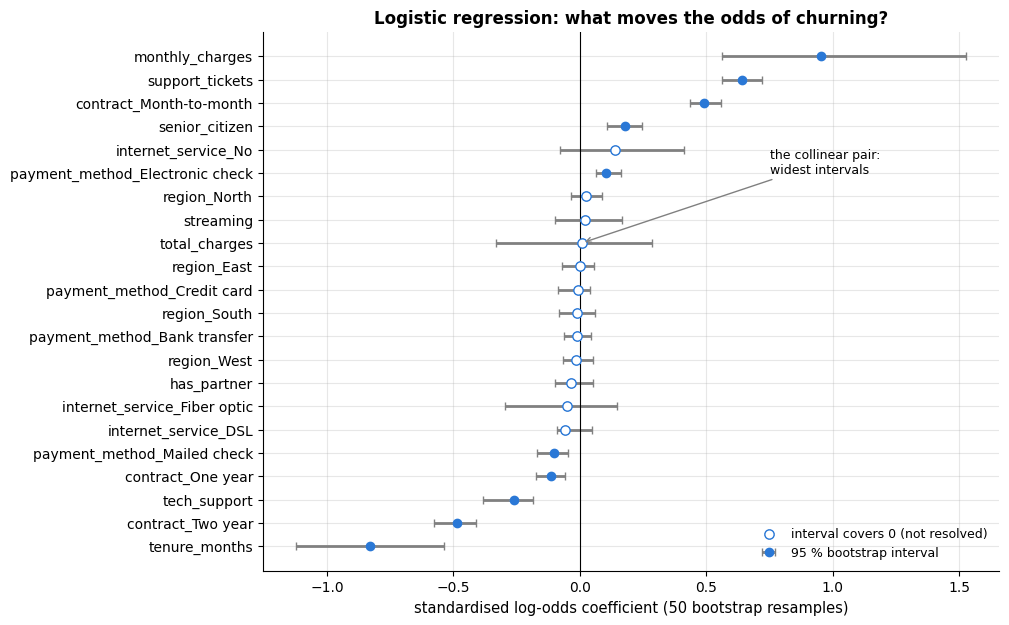

odds ratio per 12 extra months of tenure: 0.61
odds ratio per 10 $ higher monthly charges: 1.43
odds ratio for a support ticket: 1.73;  for month-to-month vs. two-year contract: 8.80
widest bootstrap intervals: monthly_charges (0.96), total_charges (0.62)


In [3]:
from sklearn.utils import resample     # resample(X, y) draws a bootstrap sample: same size, rows picked with replacement

# a pipeline can be sliced like a list: logreg[:-1] is every step except the model, and its
# get_feature_names_out() returns the names of the columns the model receives
feature_names = logreg[:-1].get_feature_names_out()
# refit the pipeline on 50 bootstrap resamples of the training set and keep each fit's coefficients
boot = np.array([
    Pipeline([("prep", make_preprocessing()), ("scale", StandardScaler()),
              ("model", LogisticRegression(C=1.0, max_iter=1000))])
    # *resample(...) unpacks the resampled [X, y] into fit(X, y), with a different resample for every b;
    # [-1] is the fitted LogisticRegression, whose coef_ has shape (1, n_features); [0] takes that single row
    .fit(*resample(X_train, y_train, random_state=b))[-1].coef_[0]
    for b in range(50)])                                       # boot has shape (50, n_features)
# one row per feature: the coefficient of the full fit, and the 2.5 % / 97.5 % percentiles of the bootstrap
# coefficients (np.percentile(..., axis=0) computes one percentile per column, i.e. per feature)
coef_table = pd.DataFrame({"coef (standardised)": logreg[-1].coef_[0],
                           "2.5 %": np.percentile(boot, 2.5, axis=0), "97.5 %": np.percentile(boot, 97.5, axis=0)},
                          index=feature_names).sort_values("coef (standardised)")
width_ci = coef_table["97.5 %"] - coef_table["2.5 %"]          # width of each 95 % interval

fig, ax = plt.subplots(figsize=(9.5, 7))
crosses_zero = (coef_table["2.5 %"] < 0) & (coef_table["97.5 %"] > 0)    # True where the interval contains 0
# errorbar draws a point with an error bar; xerr=[lengths to the left, lengths to the right] makes the bars asymmetric,
# fmt="o" draws the point as a dot and capsize sets the size of the bar ends
ax.errorbar(coef_table["coef (standardised)"], np.arange(len(coef_table)),
            xerr=[coef_table["coef (standardised)"] - coef_table["2.5 %"], coef_table["97.5 %"] - coef_table["coef (standardised)"]],
            fmt="o", color=PALETTE[0], ecolor="gray", capsize=3, label="95 % bootstrap interval")
# redraw the unresolved coefficients as hollow circles; zorder=3 puts them on top of the error bars
ax.scatter(coef_table.loc[crosses_zero, "coef (standardised)"], np.arange(len(coef_table))[crosses_zero],
           facecolor="white", edgecolor=PALETTE[0], zorder=3, s=45, label="interval covers 0 (not resolved)")
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(np.arange(len(coef_table)))
ax.set_yticklabels(coef_table.index)                           # one feature name per row
ax.set_xlabel("standardised log-odds coefficient (50 bootstrap resamples)")
ax.set_title("Logistic regression: what moves the odds of churning?")
ax.legend(loc="lower right", fontsize=9)
# annotate(text, xy=arrow tip, xytext=text position, arrowprops=...) draws a labelled arrow;
# list(index).index("total_charges") is the row position (the y value) of that feature
ax.annotate("the collinear pair:\nwidest intervals", xy=(coef_table.loc["total_charges", "coef (standardised)"],
                                                        list(coef_table.index).index("total_charges")),
            xytext=(0.75, 16), fontsize=9, arrowprops=dict(arrowstyle="->", color="gray"))
plt.show()

# the same model without StandardScaler: the coefficients are now per natural unit (per month, per $, per ticket)
raw = Pipeline([("prep", make_preprocessing()), ("model", LogisticRegression(C=1.0, max_iter=5000))]).fit(X_train, y_train)
w = pd.Series(raw[-1].coef_[0], index=raw[:-1].get_feature_names_out())     # coefficients labelled by column name
# exp(coefficient × change) is the factor by which that change multiplies the odds of churning
print(f"odds ratio per 12 extra months of tenure: {np.exp(12 * w['tenure_months']):.2f}")
print(f"odds ratio per 10 $ higher monthly charges: {np.exp(10 * w['monthly_charges']):.2f}")
# the difference of two one-hot coefficients is the log odds ratio between those two categories
print(f"odds ratio for a support ticket: {np.exp(w['support_tickets']):.2f};  for month-to-month vs. two-year contract: "
      f"{np.exp(w['contract_Month-to-month'] - w['contract_Two year']):.2f}")
# nlargest(2) keeps the two widest intervals; ", ".join(...) glues the formatted pieces together
print(f"widest bootstrap intervals: {', '.join(f'{c} ({width_ci[c]:.2f})' for c in width_ci.nlargest(2).index)}")

Four effects dominate: monthly charges and support tickets push the odds up, tenure and a
two-year contract push them down. The two widest intervals belong to `monthly_charges`
(0.96 wide) and `total_charges` (0.62) — and `total_charges`, whose interval straddles
zero, is the only large-magnitude feature the data cannot resolve at all. The reason is
**collinearity** — total charges are essentially monthly
charges × tenure — and it is the first lesson of the notebook: a coefficient is the effect
of a feature *with all others held fixed*, which is a strange question to ask when the
others cannot stay fixed. Interpretable models are only interpretable when their
assumptions hold; section 5.1 shows the same disease in the post-hoc methods.

### 2.2 Additive models: the shape of each effect

The linear model assumes each feature acts linearly on the log-odds. A **generalised
additive model** (GAM; Hastie & Tibshirani, 1986) relaxes that to
$\log \frac{p}{1-p} = b + \sum_j g_j(x_j)$ with a smooth *shape function* $g_j$ per feature:
still no interactions, so the model is fully described by $d$ curves that can be plotted
and inspected. In scikit-learn a GAM is a `SplineTransformer` (a B-spline basis per
feature, notebook 6) followed by a regularised logistic regression; the shape function of
feature $j$ is the basis of that feature multiplied by its coefficients. The *Explainable
Boosting Machine* of the InterpretML library (Nori et al., 2019) learns the same kind of
model with boosted trees per feature, plus selected pairwise interactions, and is often as
accurate as unconstrained boosting.

GAM (splines + logistic regression) test AUC: 0.824


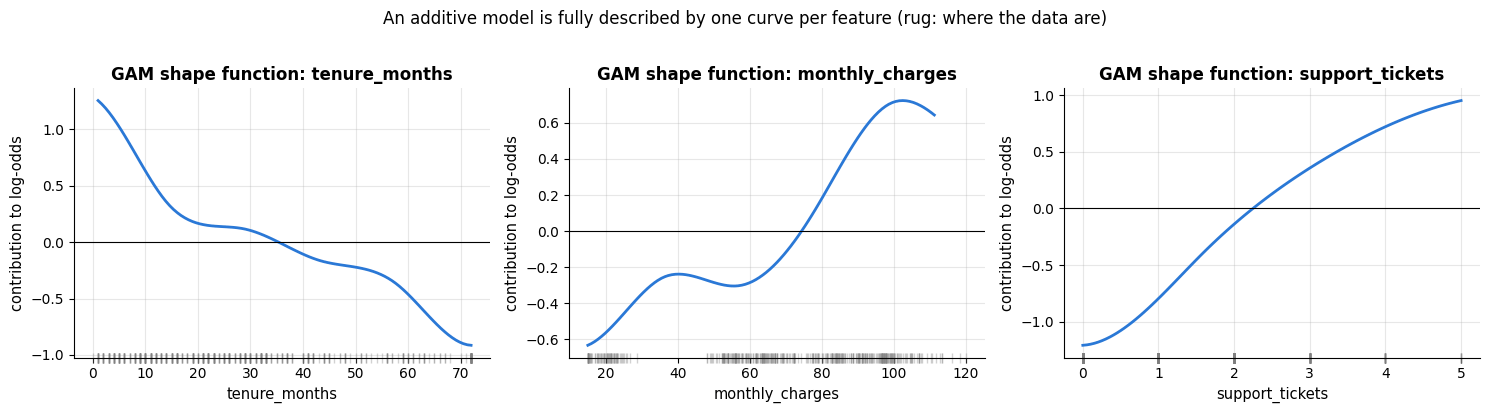

In [4]:
from sklearn.pipeline import make_pipeline           # like Pipeline, but names the steps automatically
from sklearn.preprocessing import SplineTransformer  # replaces each feature by a set of smooth B-spline basis functions

N_KNOTS, DEGREE = 6, 3                                 # 6 knots, cubic (degree-3) pieces
N_BASIS = N_KNOTS + DEGREE - 1                         # spline basis functions per feature (here 8)
gam = Pipeline([
    ("prep", ColumnTransformer([
        # numeric columns: impute, then expand each into N_BASIS spline columns, one feature after the other
        ("spl", make_pipeline(SimpleImputer(strategy="median"), SplineTransformer(n_knots=N_KNOTS, degree=DEGREE)), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL)])),
    # a linear model on the spline columns = one smooth curve per feature on the log-odds scale (C=0.5: stronger penalty)
    ("model", LogisticRegression(C=0.5, max_iter=5000))]).fit(X_train, y_train)
print(f"GAM (splines + logistic regression) test AUC: {roc_auc_score(y_test, gam.predict_proba(X_test)[:, 1]):.3f}")


def shape_function(col, grid):
    """g_j(x) for a numeric feature: its spline basis at the grid values times the fitted coefficients.

    col    name of a numeric feature
    grid   the values of that feature at which to evaluate the curve
    Returns len(grid) values in log-odds units, centred to mean zero.
    """
    j = NUMERIC.index(col)                              # position of the feature among the numeric columns
    # len(grid) copies of one training row ([[0]] keeps a one-row DataFrame), with `col` set to the grid values;
    # assign(**{col: grid}) is assign(<name stored in col>=grid). The other columns do not matter: only this
    # feature's own basis columns are used below
    rows = pd.concat([X_train.iloc[[0]]] * len(grid), ignore_index=True).assign(**{col: grid})
    # gam[0] is the fitted ColumnTransformer (it returns an array); feature j's basis fills columns
    # j*N_BASIS .. (j+1)*N_BASIS - 1
    basis = gam[0].transform(rows)[:, j * N_BASIS:(j + 1) * N_BASIS]        # (len(grid), N_BASIS)
    g = basis @ gam[-1].coef_[0][j * N_BASIS:(j + 1) * N_BASIS]            # weighted sum of the basis functions
    return g - g.mean()                                 # centre: only differences along the curve are meaningful


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure_months", "monthly_charges", "support_tickets"]):
    # 100 evenly spaced values between the 1st and 99th percentile (quantile(0.01) is the 1st percentile)
    grid = np.linspace(X_train[col].quantile(0.01), X_train[col].quantile(0.99), 100)
    ax.plot(grid, shape_function(col, grid), lw=2, color=PALETTE[0])
    rug = X_train[col].sample(400, random_state=RANDOM_STATE)          # a rug at the bottom of the axes
    # marker="|" with ls="none" draws one tick per value and no line; get_xaxis_transform() reads x in data units
    # and y as a fraction of the axes height (0 = bottom edge); clip_on=False lets the ticks overlap the frame
    ax.plot(rug, np.zeros(len(rug)), marker="|", ls="none", ms=7, color="gray", alpha=0.35,
            transform=ax.get_xaxis_transform(), clip_on=False)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel(col)
    ax.set_ylabel("contribution to log-odds")
    ax.set_title(f"GAM shape function: {col}")
fig.suptitle("An additive model is fully described by one curve per feature (rug: where the data are)", y=1.02)
plt.tight_layout()
plt.show()

The shape functions reveal what a coefficient cannot: churn risk drops *steeply* during
the first few months of tenure and then declines gently (the data-generating process of
this synthetic dataset indeed contains an "early-life" churn spike), and the effect of
support tickets saturates. The rug marks show where the data are — the ends of each curve,
where data are sparse, are the least reliable.

### 2.3 Trees, rules and monotonic constraints

A single shallow decision tree (notebook 9) is the most simulatable model there is; its
`export_text` rules can be read by anyone. Gradient boosting gives up that transparency but
keeps a related, very useful handle: **monotonic constraints**. If domain knowledge says
that churn risk cannot *increase* with tenure, we can force every tree to respect it
(`monotonic_cst`). Constraints act as regularisation, make the model's behaviour
predictable in unexplored regions, and are often free in terms of accuracy. Let us compare
the unconstrained and the constrained model along `tenure_months` using a **partial
dependence** curve — the average prediction as a function of one feature — which section
3.3 defines properly.

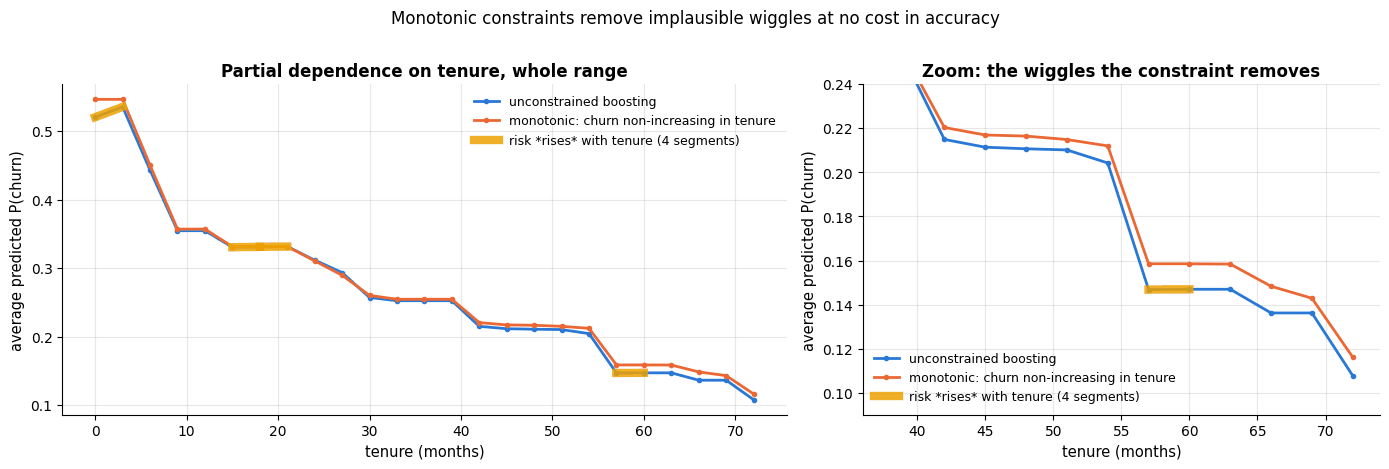

test AUC: unconstrained 0.826   constrained 0.825


In [5]:
# monotonic_cst forces the prediction to only fall (-1) or only rise (+1) as that feature grows; the dict is keyed
# by column name, which works because the preprocessing step outputs a DataFrame with named columns
hgb_mono = Pipeline([("prep", make_preprocessing()),
                     ("model", HistGradientBoostingClassifier(
                         **HGB_PARAMS, monotonic_cst={"tenure_months": -1, "monthly_charges": +1, "support_tickets": +1}))])
hgb_mono.fit(X_train, y_train)

grid = np.arange(0, 73, 3)                                     # tenure values 0, 3, 6, ..., 72 months
mono_sample = X_test.sample(400, random_state=RANDOM_STATE)    # 400 random test rows (drawn without replacement)
# partial dependence by hand: give every row tenure v, predict, and average; one value per grid point
pd_free = np.array([f(mono_sample.assign(tenure_months=v)).mean() for v in grid])
pd_mono = np.array([hgb_mono.predict_proba(mono_sample.assign(tenure_months=v))[:, 1].mean() for v in grid])
# np.diff gives the change between neighbouring grid points; np.where(cond)[0] lists the positions where cond holds
bumps = np.where(np.diff(pd_free) > 1e-6)[0]          # where the unconstrained curve goes *up*

# gridspec_kw={"width_ratios": ...} makes the left panel 1.4 times as wide as the right one
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.4, 1]})
for ax in axes:
    ax.plot(grid, pd_free, marker=".", color=PALETTE[0], label="unconstrained boosting")
    ax.plot(grid, pd_mono, marker=".", color=PALETTE[1], label="monotonic: churn non-increasing in tenure")
    for b in bumps:                                   # segments where the unconstrained curve goes up
        # a thick line between the segment's two end points, grid[b] and grid[b + 1]
        ax.plot(grid[b:b + 2], pd_free[b:b + 2], color=PALETTE[3], lw=6, alpha=0.85, zorder=4)
    # an empty line: it draws nothing but adds an entry to the legend
    ax.plot([], [], color=PALETTE[3], lw=6, alpha=0.85, label=f"risk *rises* with tenure ({len(bumps)} segments)")
    ax.set_xlabel("tenure (months)")
    ax.set_ylabel("average predicted P(churn)")
axes[0].legend(fontsize=9)
axes[0].set_title("Partial dependence on tenure, whole range")
axes[1].set_xlim(36, 74)
axes[1].set_ylim(0.09, 0.24)
axes[1].legend(fontsize=9, loc="lower left")
axes[1].set_title("Zoom: the wiggles the constraint removes")
fig.suptitle("Monotonic constraints remove implausible wiggles at no cost in accuracy", y=1.01)
plt.tight_layout()
plt.show()
print(f"test AUC: unconstrained {roc_auc_score(y_test, f(X_test)):.3f}   constrained {roc_auc_score(y_test, hgb_mono.predict_proba(X_test)[:, 1]):.3f}")

## 3. Global post-hoc explanations

### 3.1 Permutation importance

The most direct question about a black box is "which features does it *use*?". **Permutation
importance** (Breiman, 2001; formalised as *model reliance* by Fisher, Rudin & Dominici,
2019) answers it by breaking the link between one feature and the target and measuring
how much the model's score suffers:

$$
\text{PI}_j \;=\; s(f, \mathbf{X}, \mathbf{y}) \;-\; \frac{1}{R}\sum_{r=1}^{R} s\big(f, \mathbf{X}^{(\pi_r, j)}, \mathbf{y}\big),
$$

where $s$ is any score (AUC, accuracy, $R^2$, …) and $\mathbf{X}^{(\pi_r, j)}$ is the data
with column $j$ randomly shuffled by the permutation $\pi_r$. Shuffling keeps the marginal
distribution of the feature but destroys its relation to everything else; averaging over
$R$ permutations reduces the noise. The method needs only `predict`, is cheap (no
refitting), and works for any model — that is why scikit-learn's
`permutation_importance` is the default choice over impurity-based importances, which are
biased towards high-cardinality features (Strobl et al., 2007).

Our implementation takes a *list of columns* per entry rather than a single column, because
section 5.1 will need to permute a whole group of correlated features with one shared
permutation.

In [6]:
from sklearn.inspection import permutation_importance    # scikit-learn's version, used as a cross-check


def perm_importance(score_fn, frame, target, groups=None, n_repeats=5, rng=rng):
    """Permutation importance from scratch.

    `groups` maps a name to the list of columns shuffled together with one shared
    permutation (the default is one group per column).  Returns mean and sd of the
    score drop over `n_repeats` shuffles.

    score_fn(frame, target) must return a score where higher is better (AUC, R², ...);
    frame holds the raw features and target the matching labels; rng defaults to the
    notebook's shared generator. The result is a DataFrame with one row per group and the
    columns "importance" and "std", sorted from most to least important.
    """
    # dict comprehension: by default every column is its own group, {"tenure_months": ["tenure_months"], ...}
    groups = {c: [c] for c in frame.columns} if groups is None else groups
    baseline = score_fn(frame, target)                          # the score on the intact data
    rows = {}
    for name, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            shuffled = frame.copy()                             # a copy, so the caller's frame stays untouched
            order = rng.permutation(len(frame))                 # one permutation for the whole group
            # .to_numpy() drops the index, so the reordered values are written by position (pandas would otherwise
            # re-align them by index label and undo the shuffle)
            shuffled[cols] = frame[cols].to_numpy()[order]
            drops.append(baseline - score_fn(shuffled, target))   # how much the score fell
        rows[name] = {"importance": np.mean(drops), "std": np.std(drops)}
    # DataFrame(dict of dicts) has one column per group; .T flips it to one row per group
    return pd.DataFrame(rows).T.sort_values("importance", ascending=False)


def auc_of_f(frame, target):
    """Score function for perm_importance: the AUC of the black box f on `frame`."""
    return roc_auc_score(target, f(frame))


X_train_sub = X_train.sample(1500, random_state=RANDOM_STATE)      # a subsample keeps the cell fast
pi_test = perm_importance(auc_of_f, X_test, y_test, n_repeats=5)
# y_train.loc[X_train_sub.index] selects the labels of exactly the subsampled rows
pi_train = perm_importance(auc_of_f, X_train_sub, y_train.loc[X_train_sub.index], n_repeats=3)
# scikit-learn's version: scoring="roc_auc" is the score, n_repeats the number of shuffles per column;
# the result's .importances_mean holds the mean score drop of each column
sk = permutation_importance(hgb, X_test, y_test, scoring="roc_auc", n_repeats=3, random_state=RANDOM_STATE)
pi_test["sklearn"] = pd.Series(sk.importances_mean, index=X_test.columns)   # a new column, aligned by feature name
pi_test["on training data"] = pi_train["importance"]
display(pi_test.round(4))            # display() renders a DataFrame as a table, even when it is not the last line

,importance,std,sklearn,on training data
contract,0.0781,0.0082,0.0701,0.0964
monthly_charges,0.0748,0.0113,0.0706,0.0859
tenure_months,0.0546,0.0044,0.0640,0.0725
support_tickets,0.0435,0.0047,0.0442,0.0405
internet_service,0.0048,0.0007,0.0048,0.0019
payment_method,0.0028,0.0009,0.0029,0.0060
total_charges,0.0021,0.0008,0.0020,0.0055
senior_citizen,0.0019,0.0008,0.0024,0.0061
region,0.0012,0.0011,0.0017,0.0028
streaming,0.0009,0.0006,0.0015,0.0026


The table is the raw material; the picture is what you would put in a report. Importances
are estimates, so they get error bars — the standard deviation over the permutation repeats
— and the comparison with the training-data version goes in the same frame.

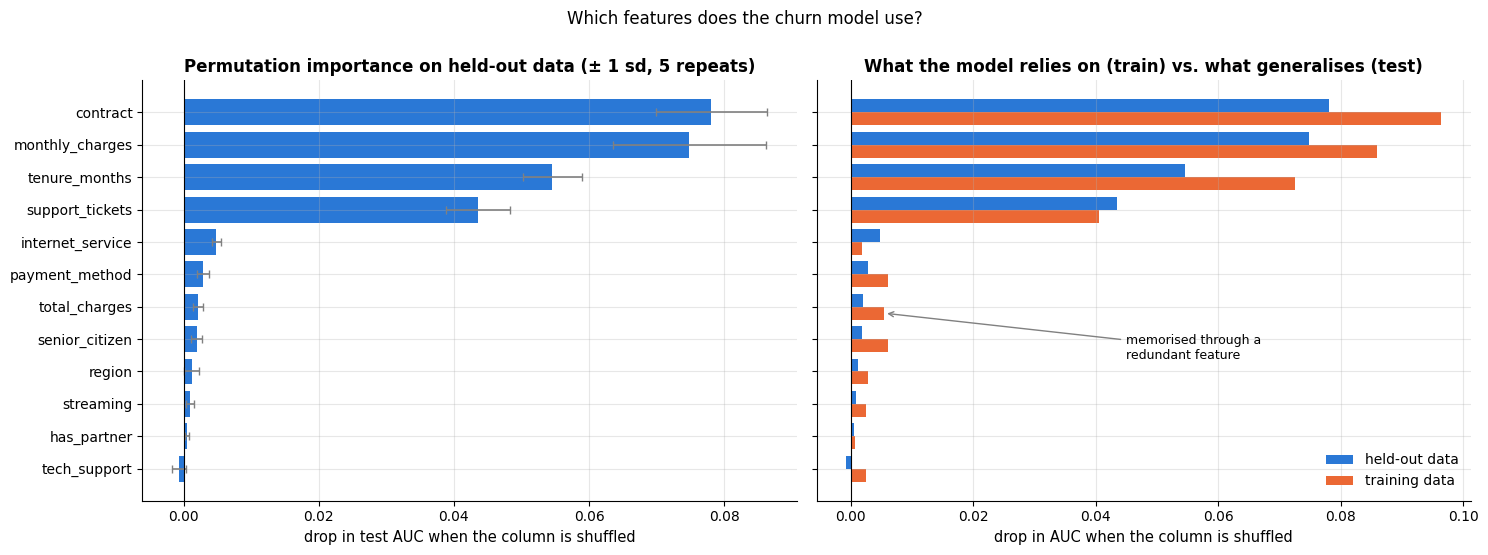

In [7]:
order_pi = pi_test.sort_values("importance").index      # ascending, so barh puts the most important feature on top
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)    # sharey: both panels use the same y-axis
# xerr adds a ± 1 sd error bar to every bar; error_kw styles those error bars
axes[0].barh(order_pi, pi_test.loc[order_pi, "importance"], xerr=pi_test.loc[order_pi, "std"],
             color=PALETTE[0], error_kw=dict(ecolor="gray", capsize=3, lw=1.2))
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("drop in test AUC when the column is shuffled")
axes[0].set_title("Permutation importance on held-out data (± 1 sd, 5 repeats)")
width = 0.4                                    # bar thickness, so that two bars fit in every row
pos = np.arange(len(order_pi))                 # one y position per feature
# two bars per feature, shifted up and down by half a bar
axes[1].barh(pos + width / 2, pi_test.loc[order_pi, "importance"], height=width,
             color=PALETTE[0], label="held-out data")
axes[1].barh(pos - width / 2, pi_test.loc[order_pi, "on training data"], height=width,
             color=PALETTE[1], label="training data")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_yticks(pos)
axes[1].set_yticklabels(order_pi)
axes[1].set_xlabel("drop in AUC when the column is shuffled")
axes[1].set_title("What the model relies on (train) vs. what generalises (test)")
axes[1].legend(loc="lower right")
# the arrow points at the training-data bar of total_charges
axes[1].annotate("memorised through a\nredundant feature",
                 xy=(pi_test.loc["total_charges", "on training data"], list(order_pi).index("total_charges") - width / 2),
                 xytext=(0.045, 3.4), fontsize=9, arrowprops=dict(arrowstyle="->", color="gray"))
fig.suptitle("Which features does the churn model use?", y=1.0)
plt.tight_layout()
plt.show()

Our implementation and scikit-learn's agree up to permutation noise. Two readings of the
table matter:

- **Test vs. training data.** On the training data the four main drivers all look more
  important, and `total_charges` — worth 0.002 AUC on held-out data — more than doubles:
  the model has memorised some noise through it. Importance computed on training data
  measures what the
  model *relies on*, importance on held-out data measures what *helps it generalise*; report
  the latter (and remember that permutation on the test set is a legitimate use of the test
  set only if you do not go back and change the model).
- **A near-zero importance does not mean "irrelevant".** It means the model does not need
  the feature *given the others* — see the next section.

### 3.2 Correlated features: permutation forces extrapolation

Shuffling a feature that is correlated with others creates rows that never occur —
a customer with 70 months of tenure and total charges of 100 $ — and the score drop then
measures the model's behaviour *off the data manifold*, not the value of the feature
(Hooker, Mentch & Zhou, 2021: "unrestricted permutation forces extrapolation"). A second
consequence: correlated features **share** importance. Let us add a noisy copy of tenure
and watch the importance of tenure split in two, then compare with the more expensive
**drop-column importance** (retrain without the feature).

permutation importance of tenure_months, original model:          0.0546
with a noisy copy of tenure added:   tenure_months 0.0111, tenure_copy 0.0223
drop-column importance of tenure_months (AUC lost by retraining without it): 0.0028


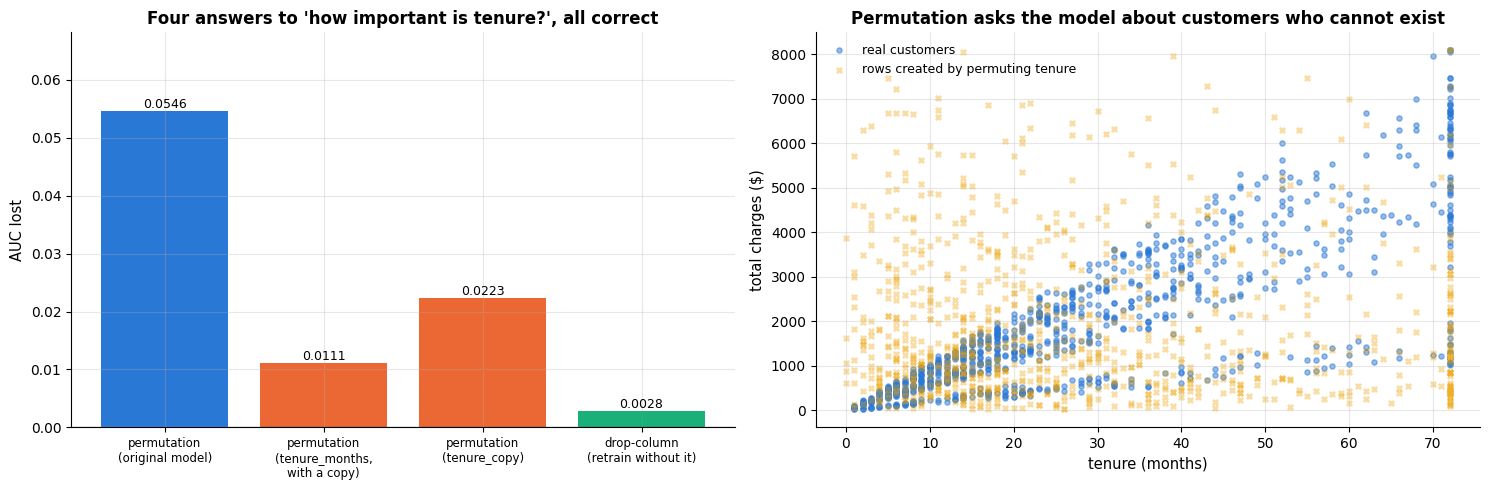

In [8]:
noise_train = rng.normal(0, 1.0, len(X_train))      # standard-normal noise, one value per row
noise_test = rng.normal(0, 1.0, len(X_test))
# tenure_copy = tenure + noise: a near-duplicate of tenure
# e.g. tenure as recorded in a second system (the billing database next to the CRM), off by about a month
X2_train = X_train.assign(tenure_copy=X_train["tenure_months"] + noise_train)
X2_test = X_test.assign(tenure_copy=X_test["tenure_months"] + noise_test)
hgb_copy = Pipeline([("prep", make_preprocessing(numeric=NUMERIC + ["tenure_copy"])),
                     ("model", HistGradientBoostingClassifier(**HGB_PARAMS))]).fit(X2_train, y_train)
# the lambda is a throw-away score function: the AUC of hgb_copy on a frame fr with labels t
pi_copy = perm_importance(lambda fr, t: roc_auc_score(t, hgb_copy.predict_proba(fr)[:, 1]), X2_test, y_test)

# drop-column importance: retrain on every numeric column except tenure_months
hgb_drop = Pipeline([("prep", make_preprocessing(numeric=[c for c in NUMERIC if c != "tenure_months"])),
                     ("model", HistGradientBoostingClassifier(**HGB_PARAMS))])
hgb_drop.fit(X_train.drop(columns="tenure_months"), y_train)
# test AUC of the full model minus test AUC of the model trained without tenure
drop_loss = roc_auc_score(y_test, f(X_test)) - roc_auc_score(y_test, hgb_drop.predict_proba(X_test.drop(columns="tenure_months"))[:, 1])

print(f"permutation importance of tenure_months, original model:          {pi_test.loc['tenure_months', 'importance']:.4f}")
print(f"with a noisy copy of tenure added:   tenure_months {pi_copy.loc['tenure_months', 'importance']:.4f}, "
      f"tenure_copy {pi_copy.loc['tenure_copy', 'importance']:.4f}")
print(f"drop-column importance of tenure_months (AUC lost by retraining without it): {drop_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
labels = ["permutation\n(original model)", "permutation\n(tenure_months,\nwith a copy)",
          "permutation\n(tenure_copy)", "drop-column\n(retrain without it)"]
values = [pi_test.loc["tenure_months", "importance"], pi_copy.loc["tenure_months", "importance"],
          pi_copy.loc["tenure_copy", "importance"], drop_loss]
bars = axes[0].bar(labels, values, color=[PALETTE[0], PALETTE[1], PALETTE[1], PALETTE[2]])
axes[0].bar_label(bars, fmt="%.4f", fontsize=9)       # write each bar's value above it ("%.4f": 4 decimals)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylabel("AUC lost")
axes[0].set_ylim(0, max(values) * 1.25)
axes[0].set_title("Four answers to 'how important is tenure?', all correct")
axes[0].tick_params(axis="x", labelsize=8.5)          # smaller x tick labels
# where do the permuted rows actually land?
shuffled_tenure = rng.permutation(X_test["tenure_months"].to_numpy())    # the same tenure values in random order
axes[1].scatter(X_test["tenure_months"], X_test["total_charges"], s=14, alpha=0.5,
                color=PALETTE[0], label="real customers")
axes[1].scatter(shuffled_tenure, X_test["total_charges"], s=14, alpha=0.35,
                color=PALETTE[3], marker="x", label="rows created by permuting tenure")
axes[1].set_xlabel("tenure (months)")
axes[1].set_ylabel("total charges ($)")
axes[1].set_title("Permutation asks the model about customers who cannot exist")
axes[1].legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

The right-hand panel is the mechanism behind the numbers. Real customers lie on a narrow
band — total charges are roughly monthly charges × tenure — and the permuted rows are
scattered all over the plane, including the empty corners "two months of tenure, 8 000 $
billed" and "six years of tenure, 100 $ billed". The AUC drop we measure is partly the
model's behaviour *there*, where no training data ever constrained it.

Three different numbers for "the importance of tenure", all correct answers to different
questions. Permutation importance says the model *uses* tenure heavily; with a duplicate,
each copy is individually dispensable; and retraining without tenure costs almost nothing
because `total_charges / monthly_charges` reconstructs it. When features are correlated,
permute *groups* of related features together, or use conditional/drop-column importance,
and never read importance as causal effect. Section 5.1 turns this into a controlled
experiment with a known ground truth.

### 3.3 Partial dependence and ICE plots

Importance says *how much*; **partial dependence** (Friedman, 2001) says *how*. The
partial dependence of $f$ on feature $j$ is the average prediction when $x_j$ is set to a
value $v$ for *every* row,

$$
\hat{f}_j(v) \;=\; \frac{1}{n}\sum_{i=1}^{n} f\big(v, \mathbf{x}_{i,-j}\big),
$$

where $\mathbf{x}_{i,-j}$ is row $i$ with feature $j$ removed. The curve $v \mapsto \hat f_j(v)$
is the model's average response to the feature; for two features, $\hat f_{jk}(v, u)$ is a
surface that reveals interactions. The **individual conditional expectation** (ICE) plot
(Goldstein et al., 2015) shows the $n$ individual curves $v \mapsto f(v, \mathbf{x}_{i,-j})$
whose average is the PDP; when they are not parallel, the feature interacts with others and
the average hides heterogeneity. The implementation is a loop over grid values.

our PDP equals scikit-learn's partial_dependence: True


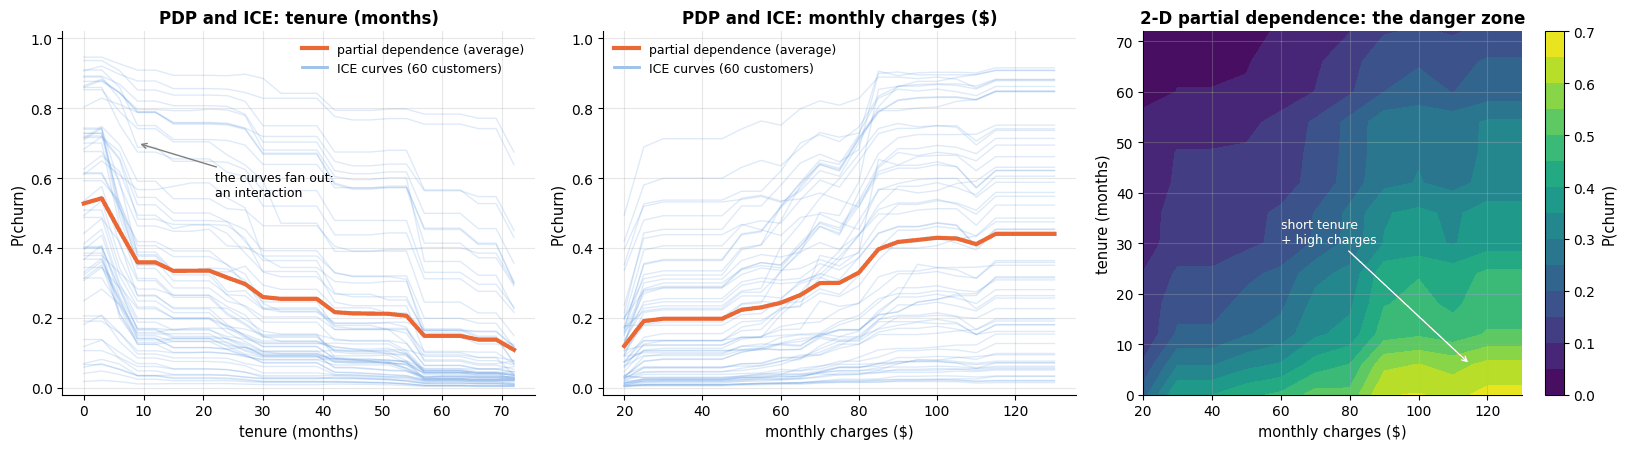

In [9]:
# partial_dependence computes PD values; PartialDependenceDisplay draws ready-made PD / ICE plots
from sklearn.inspection import PartialDependenceDisplay, partial_dependence


def partial_dependence_1d(f, frame, col, grid):
    """PDP and ICE curves: predictions with column `col` set to each grid value for every row.

    f      prediction function: DataFrame -> one number per row
    Returns (pdp, ice): ice has shape (n_rows, len(grid)), one curve per row; pdp is its average
    over the rows, shape (len(grid),).
    """
    # one f(...) call per grid value, each giving n_rows predictions; np.column_stack puts them side by side as columns
    ice = np.column_stack([f(frame.assign(**{col: v})) for v in grid])        # (n_rows, n_grid)
    return ice.mean(axis=0), ice                       # averaging down the rows gives the PDP


def partial_dependence_2d(f, frame, col_a, col_b, grid_a, grid_b):
    """2-D partial dependence: the average prediction with col_a set to a and col_b set to b, for every pair (a, b).

    Returns an array of shape (len(grid_a), len(grid_b)).
    """
    # nested comprehension: the outer loop over grid_a builds the rows, the inner loop over grid_b the columns
    return np.array([[f(frame.assign(**{col_a: a, col_b: b})).mean() for b in grid_b] for a in grid_a])


sample = X_test.sample(300, random_state=RANDOM_STATE)                          # ICE on a subsample: readable and cheap
grid_tenure = np.linspace(0, 72, 25)                  # 25 tenure values from 0 to 72 months
grid_charges = np.linspace(20, 130, 23)               # 23 monthly-charge values from 20 to 130 $
pdp_tenure, ice_tenure = partial_dependence_1d(f, sample, "tenure_months", grid_tenure)
pdp_charges, ice_charges = partial_dependence_1d(f, sample, "monthly_charges", grid_charges)

# cross-check against scikit-learn on the same subsample
# kind="average" returns only the PD curve and custom_values supplies our grid; for a classifier it averages
# predict_proba of class 1. The result's "average" entry has shape (1, len(grid)), hence the [0]
sk_pd = partial_dependence(hgb, sample, features=["tenure_months"], kind="average", custom_values={"tenure_months": grid_tenure})
print("our PDP equals scikit-learn's partial_dependence:", np.allclose(pdp_tenure, sk_pd["average"][0]))

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
# zip pairs each of the first two panels with a tuple (grid, PDP, ICE curves, axis label)
for ax, (grid, pdp, ice, name) in zip(axes[:2], [(grid_tenure, pdp_tenure, ice_tenure, "tenure (months)"),
                                                 (grid_charges, pdp_charges, ice_charges, "monthly charges ($)")]):
    ax.plot(grid, ice[:60].T, color=PALETTE[0], alpha=0.15, lw=1)    # (n_grid, 60): plot draws one line per column
    ax.plot(grid, pdp, color=PALETTE[1], lw=3, label="partial dependence (average)")
    ax.plot([], [], color=PALETTE[0], alpha=0.5, label="ICE curves (60 customers)")    # legend entry only
    ax.set_xlabel(name)
    ax.set_ylabel("P(churn)")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"PDP and ICE: {name}")
axes[0].legend(loc="upper right", fontsize=9)
axes[1].legend(loc="upper left", fontsize=9)
axes[0].annotate("the curves fan out:\nan interaction", xy=(9, 0.70), xytext=(22, 0.55), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="gray"))
# 2-D PDP on every second grid point ([::2]): 13 x 12 instead of 25 x 23 points, roughly a quarter of the cost
pd2 = partial_dependence_2d(f, sample, "tenure_months", "monthly_charges", grid_tenure[::2], grid_charges[::2])
# contourf(x, y, Z) fills bands of equal value; Z's rows follow y (tenure) and its columns follow x (charges)
im = axes[2].contourf(grid_charges[::2], grid_tenure[::2], pd2, levels=12, cmap="viridis")
plt.colorbar(im, ax=axes[2], label="P(churn)")         # the colour scale next to the panel
axes[2].set_xlabel("monthly charges ($)")
axes[2].set_ylabel("tenure (months)")
axes[2].set_title("2-D partial dependence: the danger zone")
axes[2].annotate("short tenure\n+ high charges", xy=(115, 6), xytext=(60, 30), color="white", fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="white"))
plt.tight_layout()
plt.show()

The ICE curves for tenure fan out: the drop after the first months is much larger for
some customers (those on month-to-month contracts, as the 2-D plot and section 4 will
confirm) than for others — an interaction that the average curve smooths away. The 2-D
partial dependence shows the danger zone: short tenure *and* high charges.

scikit-learn's `PartialDependenceDisplay.from_estimator` draws the same pictures in one call,
including categorical features and `kind="both"` for PDP + ICE. Two-way plots there must be
*numeric × numeric* — a continuous/categorical pair raises `ValueError` — so the
interaction with `contract` is drawn by hand below, with one partial-dependence curve per
contract type. That grouped curve is in fact the more useful picture: it shows not only
*that* the two features interact but how the shape of the tenure effect differs between
the groups.

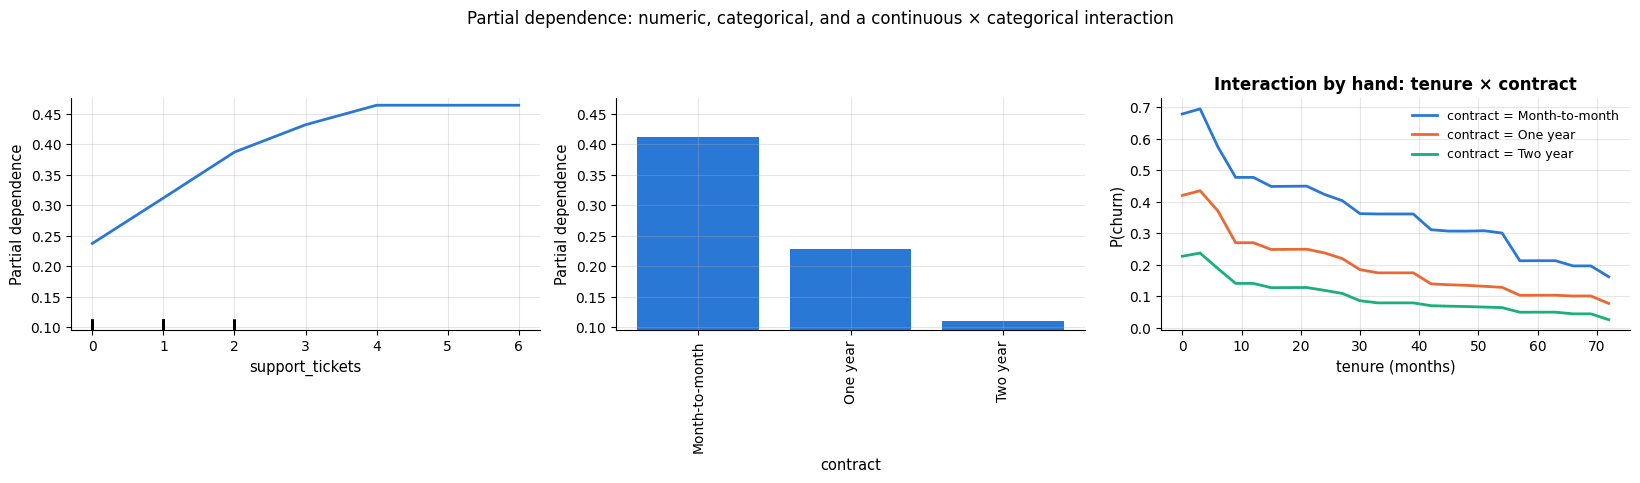

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
# scikit-learn draws one PD panel per feature into the axes passed as ax=; categorical_features lists the ones
# to draw as bars (one per category); random_state only matters when ICE curves are subsampled
PartialDependenceDisplay.from_estimator(hgb, sample, features=["support_tickets", "contract"],
                                        categorical_features=["contract"], kind="average",
                                        ax=axes[:2], random_state=RANDOM_STATE)
for contract, colour in zip(["Month-to-month", "One year", "Two year"], PALETTE):
    subset = sample.assign(contract=contract)          # every customer in the sample gets this contract type
    curve, _ = partial_dependence_1d(f, subset, "tenure_months", grid_tenure)   # _ discards the ICE curves
    axes[2].plot(grid_tenure, curve, lw=2, color=colour, label=f"contract = {contract}")
axes[2].set_xlabel("tenure (months)")
axes[2].set_ylabel("P(churn)")
axes[2].set_title("Interaction by hand: tenure × contract")
axes[2].legend(fontsize=9)
fig.suptitle("Partial dependence: numeric, categorical, and a continuous × categorical interaction", y=1.04)
plt.tight_layout()
plt.show()

> **Warning — extrapolation, again.** The PDP sets $x_j = v$ for *all* rows, including rows
> for which that value is absurd (72 months of tenure for a customer whose total charges say
> she joined last month). The curve then partly reflects predictions in regions without
> data, where the model is unconstrained. The 2-D plot above mitigates this by showing the
> joint effect; the general cure is the ALE plot — and section 5.2 shows a model for which
> the PDP is *provably* an artefact.

### 3.4 Accumulated local effects

**ALE plots** (Apley & Zhu, 2020) avoid extrapolation by never moving a row far from where
it is. Partition the range of $x_j$ into small intervals $[z_{k-1}, z_k]$; for the rows
whose $x_j$ falls in interval $k$, compute the *local* change in prediction when $x_j$ is
moved from the lower to the upper edge of *its own* interval; average those local
differences and accumulate them from left to right:

$$
\widehat{\text{ALE}}_j(v) \;=\; \sum_{k=1}^{k(v)} \frac{1}{n_k} \sum_{i:\, x_{ij} \in N_k}
\Big[ f\big(z_k, \mathbf{x}_{i,-j}\big) - f\big(z_{k-1}, \mathbf{x}_{i,-j}\big) \Big] \;-\; \text{const},
$$

centred so that the curve averages to zero. Because each row is only nudged within its
interval, correlated features stay consistent, and the curve is an estimate of the
*conditional* effect rather than the marginal one. It is also cheaper than a PDP: two model
evaluations per row instead of one per grid point per row.

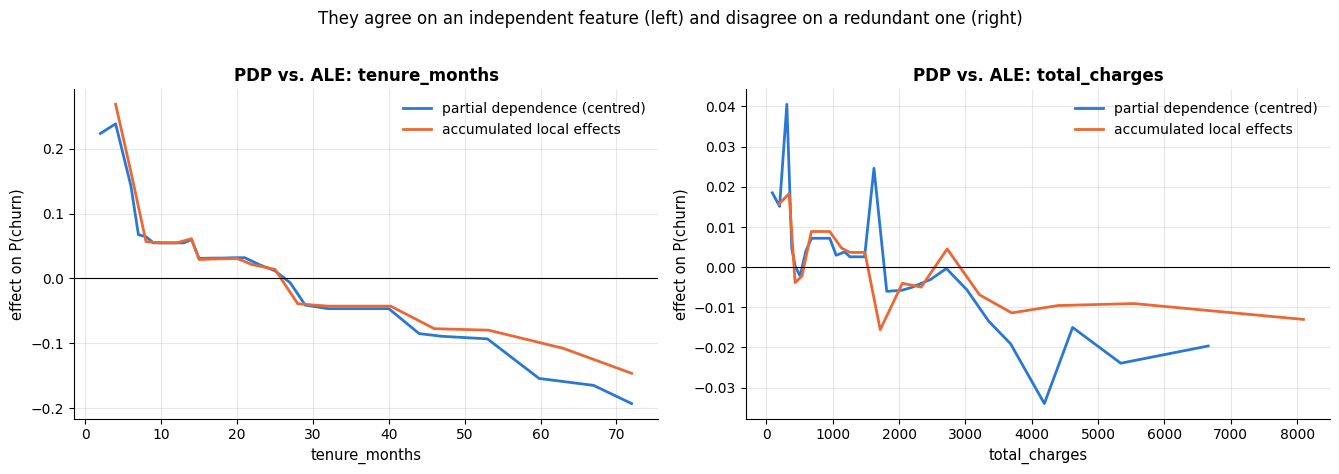

In [11]:
def ale_1d(f, frame, col, n_bins=20):
    """Accumulated local effects of one numeric feature (Apley & Zhu, 2020).

    f        prediction function; frame   the rows to use (`col` must not contain NaN)
    n_bins   number of quantile bins (fewer when the feature has repeated values)
    Returns (upper bin edges, ALE value at each edge); the curve is centred so that its
    row-weighted average is zero.
    """
    x = frame[col].to_numpy()
    # bin edges at quantiles, so every bin holds about the same number of rows; np.unique drops repeated edges
    edges = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    # np.searchsorted(edges, x, side="right") - 1 is the bin of each value; np.clip puts the maximum, which lies
    # exactly on the last edge, into the last bin
    which = np.clip(np.searchsorted(edges, x, side="right") - 1, 0, len(edges) - 2)
    effects, counts = np.zeros(len(edges) - 1), np.zeros(len(edges) - 1)    # one entry per bin
    for k in range(len(edges) - 1):
        rows = frame[which == k]                       # the rows whose value falls in bin k
        if len(rows):                                  # skip empty bins (a length of 0 counts as False)
            # local effect: move each row to the upper and to the lower edge of its bin, average the difference
            effects[k] = np.mean(f(rows.assign(**{col: edges[k + 1]})) - f(rows.assign(**{col: edges[k]})))
            counts[k] = len(rows)
    ale = np.cumsum(effects)                           # accumulate the local effects from left to right
    # centre: subtract the curve's mean, weighting each bin by its number of rows
    return edges[1:], ale - np.average(ale, weights=counts)


# fill missing values with the training medians so every row has a value to move; median(numeric_only=True)
# skips the text columns, and fillna(Series) fills each column with its own entry of that Series
filled = X_test.fillna(X_train.median(numeric_only=True))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for ax, col in zip(axes, ["tenure_months", "total_charges"]):
    grid = np.quantile(filled[col], np.linspace(0.02, 0.98, 30))      # 30 grid points from the 2nd to the 98th percentile
    pdp, _ = partial_dependence_1d(f, filled, col, grid)
    ax.plot(grid, pdp - pdp.mean(), lw=2, color=PALETTE[0], label="partial dependence (centred)")
    ale_grid, ale = ale_1d(f, filled, col)
    ax.plot(ale_grid, ale, lw=2, color=PALETTE[1], label="accumulated local effects")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel(col)
    ax.set_ylabel("effect on P(churn)")
    ax.set_title(f"PDP vs. ALE: {col}")
    ax.legend()
fig.suptitle("They agree on an independent feature (left) and disagree on a redundant one (right)", y=1.02)
plt.tight_layout()
plt.show()

For tenure, which is nearly uncorrelated with the other features, the two curves agree
closely. For `total_charges` — a deterministic function of tenure and monthly charges —
they do not: the PDP swings over about 0.075 in probability and reverses direction three
times, while the ALE curve covers less than half that range and declines smoothly. The PDP
is an artefact of extrapolation: setting total charges to 8 000 $ for a customer with two
months of tenure asks the model about a customer who cannot exist. ALE estimates the
effect at fixed tenure and charges, and finds it small — which is what a redundant feature
should look like, and what its near-zero permutation importance already suggested. Section
5.2 turns this comparison into a controlled proof.

### 3.5 Global surrogate models

A **global surrogate** replaces the black box by an interpretable model trained to mimic
its predictions (not the labels): fit a shallow tree to $f(\mathbf{x}_i)$ and read its
rules. The surrogate's $R^2$ on the black box's predictions — its *fidelity* — tells you how
much of the model the rules capture, and the scatter of surrogate against black box shows
*where* the approximation is poor.

surrogate fidelity (R² w.r.t. the black box's predictions): train 0.782, test 0.782


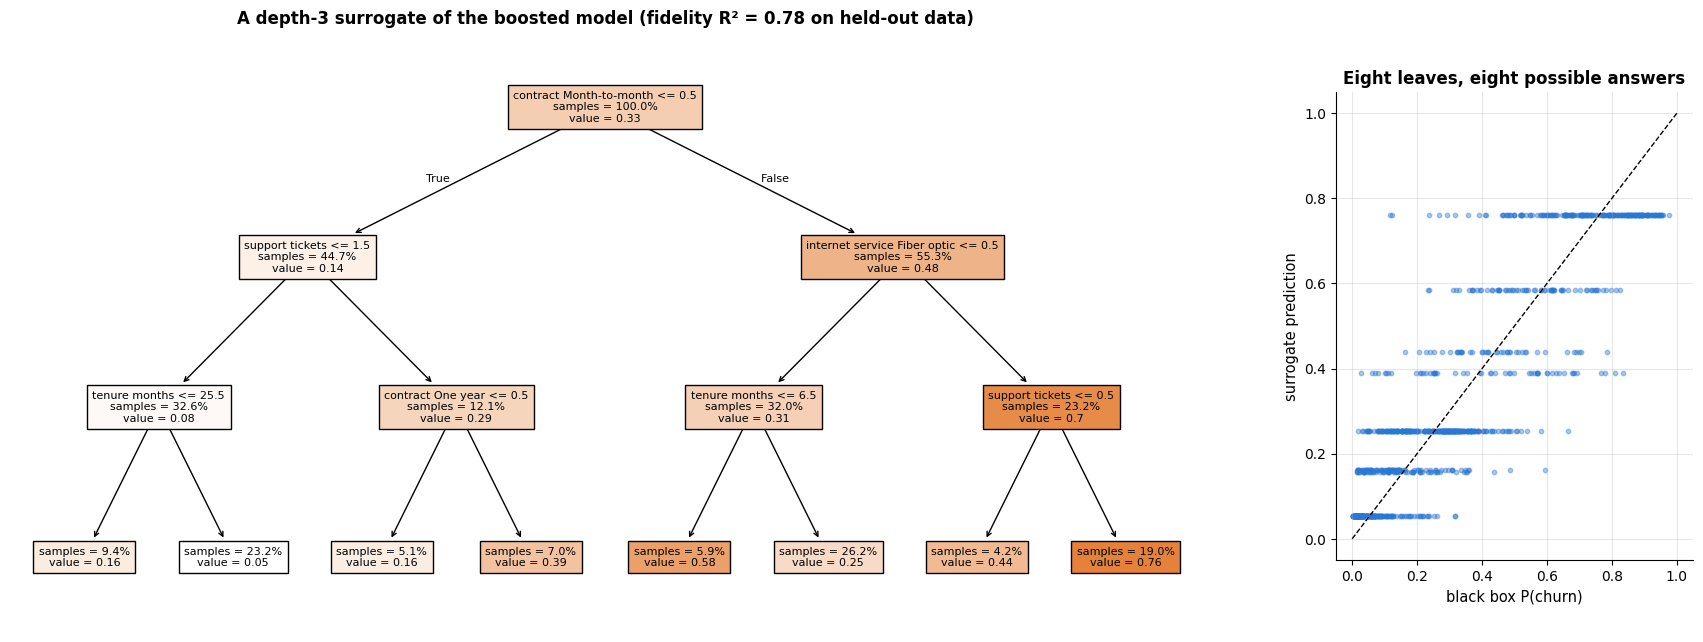

In [12]:
from sklearn.tree import DecisionTreeRegressor, plot_tree      # plot_tree draws a fitted tree with matplotlib

# hgb[:-1] is the fitted preprocessing step: the surrogate sees the same imputed, one-hot encoded columns as the model
X_train_t, X_test_t = hgb[:-1].transform(X_train), hgb[:-1].transform(X_test)
# the target is the black box's prediction f(X_train), not the true label: the tree learns to imitate the model
surrogate = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train_t, f(X_train))
# a regressor's .score(X, y) is R²; with y = the black box's output, R² measures how faithful the surrogate is
fid_train, fid_test = surrogate.score(X_train_t, f(X_train)), surrogate.score(X_test_t, f(X_test))
print(f"surrogate fidelity (R² w.r.t. the black box's predictions): train {fid_train:.3f}, test {fid_test:.3f}")

fig = plt.figure(figsize=(17, 6))
# add_axes([left, bottom, width, height]) places a panel by hand, in fractions of the figure
ax_tree = fig.add_axes([0.0, 0.0, 0.70, 1.0])
ax_fit = fig.add_axes([0.78, 0.12, 0.21, 0.78])
# filled=True colours the nodes by their value; impurity=False hides the squared error; proportion=True shows
# samples as a percentage of the training rows; precision=2 rounds the numbers to 2 decimals
plot_tree(surrogate, feature_names=[c.replace("_", " ") for c in X_train_t.columns], filled=True, impurity=False,
          precision=2, fontsize=8, ax=ax_tree, proportion=True)
ax_tree.set_title(f"A depth-3 surrogate of the boosted model (fidelity R² = {fid_test:.2f} on held-out data)")
ax_fit.scatter(f(X_test), surrogate.predict(X_test_t), s=10, alpha=0.4, color=PALETTE[0])   # one dot per test customer
ax_fit.plot([0, 1], [0, 1], color="black", lw=1, ls="--")       # the diagonal: perfect agreement
ax_fit.set_xlabel("black box P(churn)")
ax_fit.set_ylabel("surrogate prediction")
ax_fit.set_title("Eight leaves, eight possible answers")
plt.show()

Eight rules reproduce about 78 % of the variance of the model's predictions: the model is
mostly "month-to-month contract × fibre optic × support tickets × short tenure". The
scatter shows the price of the simplification — the surrogate can only output eight
distinct values, so every vertical stripe of black-box predictions is collapsed onto one of
them. That missing variance is where the black box earns its keep, and where a surrogate
would mislead if taken literally.

## 4. Local post-hoc explanations

Global methods describe the model on average. A customer, a loan applicant or a patient
wants to know about *their* prediction. Local methods explain one $f(\mathbf{x})$ at a time.

### 4.1 LIME: local linear surrogates

**LIME** (Local Interpretable Model-agnostic Explanations; Ribeiro, Singh & Guestrin, 2016)
fits a simple model $g$ that is faithful to $f$ *in the neighbourhood of* $\mathbf{x}$:

$$
\xi(\mathbf{x}) \;=\; \arg\min_{g \in G} \; \mathcal{L}\big(f, g, \pi_{\mathbf{x}}\big) + \Omega(g),
\qquad
\pi_{\mathbf{x}}(\mathbf{z}) = \exp\!\big(-D(\mathbf{x}, \mathbf{z})^2 / \sigma^2\big),
$$

where $G$ is a class of sparse linear models, $\mathcal{L}$ is the squared error between
$f$ and $g$ on perturbed points $\mathbf{z}$ weighted by their proximity $\pi_{\mathbf{x}}$
to $\mathbf{x}$, and $\Omega$ penalises complexity (the number of non-zero coefficients).
The algorithm:

1. Sample perturbations $\mathbf{z}$ around $\mathbf{x}$ (for tabular data: add Gaussian
   noise scaled by each feature's standard deviation; the library also discretises numeric
   features and resamples categoricals — our minimal version perturbs the numeric features
   and keeps the categoricals fixed).
2. Query the black box: $f(\mathbf{z})$.
3. Weight each $\mathbf{z}$ by the kernel $\pi_{\mathbf{x}}$ (the library's default width is
   $\sigma = 0.75\sqrt{d}$ in standardised units).
4. Select $K$ features (lasso) and fit a weighted linear model on them; its coefficients are
   the explanation, its weighted $R^2$ the *local fidelity*.

customer 4756: P(churn) = 0.661, contract = Month-to-month, tenure = 11 months, tickets = 1
local linear fidelity (weighted R²) = 0.75; only 7 % of the 2 000 perturbations carry a kernel weight above 0.5, and 30 % of them have a negative tenure


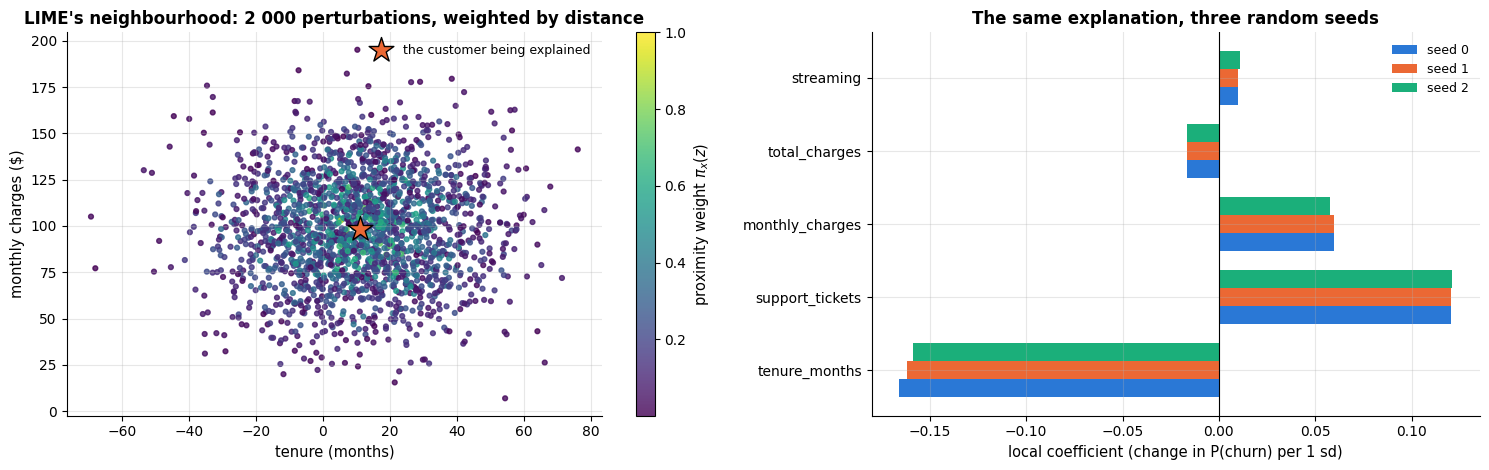

In [13]:
from sklearn.linear_model import Lasso, Ridge   # linear regression with an L1 penalty (sets weights to 0) / an L2 penalty


def lime_explain(f, x, X_ref, numeric, n_samples=2000, kernel_width=0.75, n_features=5, rng=rng):
    """Minimal tabular LIME: perturb numeric features around x, weight by proximity, fit a sparse weighted linear model.

    Returns the coefficients, the weighted local R², and the perturbation cloud (for plotting).

    x             the row to explain (a Series of raw features)
    X_ref         reference data: supplies each feature's standard deviation and the column dtypes
    numeric       the columns to perturb; all other columns keep x's value
    kernel_width  width of the proximity kernel in standardised units (scaled by sqrt(len(numeric)))
    n_features    how many features the local linear model keeps
    The coefficients are a Series indexed by feature name, in "change in f per 1 sd of the feature".
    """
    sd = X_ref[numeric].std().to_numpy()                             # one standard deviation per numeric feature
    x_num = x[numeric].astype(float).to_numpy()                      # x's numeric values as an array
    Zs = rng.normal(size=(n_samples, len(numeric)))                  # perturbations in standardised units
    Zs[0] = 0.0                                                      # keep x itself
    # [x.to_dict()] * n_samples is a list of identical dicts, i.e. n_samples identical rows; astype restores the dtypes
    Z = pd.DataFrame([x.to_dict()] * n_samples).astype(X_ref.dtypes.to_dict())   # copies of x (categoricals stay fixed)
    Z[numeric] = x_num + Zs * sd                                     # back to natural units: x + noise × sd
    preds = f(Z)                                                     # query the black box at every perturbation
    # Gaussian proximity kernel exp(-||z||² / σ²) with σ = kernel_width · sqrt(d): near points weigh ~1, far ones ~0
    weights = np.exp(-np.sum(Zs ** 2, axis=1) / (kernel_width ** 2 * len(numeric)))
    # a lasso fit picks the features; sample_weight makes the nearby perturbations count more
    selector = Lasso(alpha=0.002).fit(Zs, preds, sample_weight=weights)
    # argsort of -|coef| orders the features from the largest |coefficient| down; keep the first n_features
    keep = np.argsort(-np.abs(selector.coef_))[:n_features]
    local = Ridge(alpha=1.0).fit(Zs[:, keep], preds, sample_weight=weights)    # the explanation: a weighted linear fit
    resid = preds - local.predict(Zs[:, keep])
    # weighted R² = 1 - weighted mean squared residual / weighted variance of the predictions
    fidelity = 1 - np.average(resid ** 2, weights=weights) / np.average((preds - np.average(preds, weights=weights)) ** 2, weights=weights)
    cloud = Z.assign(weight=weights, prediction=preds)               # perturbations + weight + prediction
    return pd.Series(local.coef_, index=[numeric[i] for i in keep]), fidelity, cloud


customer = X_test.iloc[5]                      # the sixth test row, as a Series; customer.name is its index label
lime_coef, fidelity, cloud = lime_explain(f, customer, X_train, NUMERIC)
# X_test.iloc[[5]] (a list of positions) keeps a one-row DataFrame, which is what f expects
print(f"customer {customer.name}: P(churn) = {f(X_test.iloc[[5]])[0]:.3f}, contract = {customer['contract']}, "
      f"tenure = {customer['tenure_months']:.0f} months, tickets = {customer['support_tickets']:.0f}")
# the mean of a True/False Series is the fraction of True values
print(f"local linear fidelity (weighted R²) = {fidelity:.2f}; only {100 * (cloud['weight'] > 0.5).mean():.0f} % of the "
      f"2 000 perturbations carry a kernel weight above 0.5, and {100 * (cloud['tenure_months'] < 0).mean():.0f} % of them "
      f"have a negative tenure")

# rerun with three seeds; each run's coefficient Series becomes one column. Runs can keep different features,
# which leaves NaN in the other columns, and fillna(0) turns those into 0
runs = pd.DataFrame({f"seed {s}": lime_explain(f, customer, X_train, NUMERIC, rng=np.random.default_rng(s))[0]
                     for s in range(3)}).fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})
# c= colours each point by its kernel weight, using the colour map cmap
sc = axes[0].scatter(cloud["tenure_months"], cloud["monthly_charges"], c=cloud["weight"],
                     cmap="viridis", s=12, alpha=0.8)
axes[0].scatter([customer["tenure_months"]], [customer["monthly_charges"]], marker="*", s=350,
                color=PALETTE[1], edgecolor="black", zorder=4, label="the customer being explained")
plt.colorbar(sc, ax=axes[0], label="proximity weight $\\pi_x(z)$")
axes[0].set_xlabel("tenure (months)")
axes[0].set_ylabel("monthly charges ($)")
axes[0].set_title("LIME's neighbourhood: 2 000 perturbations, weighted by distance")
axes[0].legend(loc="upper right", fontsize=9)
# pandas plotting: one group of bars per row (feature), one bar per column (seed)
runs.plot.barh(ax=axes[1], color=PALETTE[:3], width=0.75)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("local coefficient (change in P(churn) per 1 sd)")
axes[1].set_title("The same explanation, three random seeds")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

The explanation reads: for this customer, more tenure would lower the churn probability,
more tickets would raise it, and the rest matters little. Four things to keep in mind:
the coefficients are *local slopes* (they can differ from the global picture), the
fidelity is well below 1 (the neighbourhood is not linear), repeated runs give
slightly different answers — with fewer samples the differences grow — and the left panel
shows that nearly a third of the "neighbours" have a *negative* tenure. Gaussian perturbation
knows nothing about the support of the data, so LIME, like the PDP, partly probes the model
where no customer lives. Its instability and its sensitivity to the kernel width and the
perturbation distribution are its main weaknesses; Shapley values fix the first two at a
higher computational price.

### 4.2 Shapley values: a fair division of the prediction

Think of the features as **players** in a cooperative game whose **payout** is the
prediction, and ask: how should the payout be divided among the players? Shapley (1953)
proved that exactly one division satisfies four fairness axioms. Let $F$ be the set of
features, $v(S)$ the value of the game when only the players in $S \subseteq F$ take part,
and $\phi_j$ the share of player $j$:

- **Efficiency**: $\sum_j \phi_j = v(F) - v(\emptyset)$ — the shares add up to the total
  gain (the prediction minus the baseline).
- **Symmetry**: two players that contribute identically to every coalition get equal shares.
- **Dummy**: a player that never changes any coalition's value gets zero.
- **Additivity**: the shares for a sum of two games are the sums of the shares.

> **Real-life example.** Two freelancers bid for a website job. Ana alone could charge 6 000 €
> for it, Ben alone 4 000 €, and the two together (she designs, he programs) 14 000 €. If Ana
> joins first she adds 6 000 €, if she joins second she adds 10 000 € (14 000 − 4 000);
> averaged over the two orders her fair share is 8 000 €, and Ben's, by the same reasoning,
> 6 000 €. The shares add up to the whole fee (efficiency). For a prediction, the features are
> the partners and the fee is the prediction minus the average prediction.

The unique solution weighs the marginal contribution of $j$ to every coalition $S$ that
does not contain it:

$$
\phi_j \;=\; \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F| - |S| - 1)!}{|F|!}\,
\Big[ v(S \cup \{j\}) - v(S) \Big] .
$$

Equivalently, $\phi_j$ is the average marginal contribution of $j$ over all $|F|!$
orderings of the players — the weight is the fraction of orderings in which exactly the
players of $S$ come before $j$. To use this for a prediction we need a *game*: what does
"only the features in $S$ take part" mean for $f(\mathbf{x})$? The standard answer
(Štrumbelj & Kononenko, 2014; Lundberg & Lee, 2017) is to replace the absent features by
values from a **background** dataset and average:

$$
v(S) \;=\; \mathbb{E}_{\mathbf{z} \sim \text{background}}\Big[ f\big(\mathbf{x}_S, \mathbf{z}_{F \setminus S}\big) \Big] ,
$$

so $v(\emptyset)$ is the average prediction over the background and $v(F) = f(\mathbf{x})$.
With $d$ features there are $2^d$ coalitions: exact computation is feasible for a handful
of features and hopeless beyond about 15. We first compute it exactly on a five-feature
model, then verify the answer on a model where we know it, then approximate.

In [14]:
SMALL = ["tenure_months", "monthly_charges", "support_tickets", "contract", "tech_support"]   # 2^5 = 32 coalitions
# the same model restricted to these five features; contract is its only categorical column
hgb_small = Pipeline([("prep", make_preprocessing(numeric=[c for c in SMALL if c != "contract"], categorical=["contract"])),
                      ("model", HistGradientBoostingClassifier(**HGB_PARAMS))]).fit(X_train[SMALL], y_train)


def f_small(frame):
    """P(churn) of the five-feature model, for a DataFrame with the SMALL columns."""
    return hgb_small.predict_proba(frame)[:, 1]


def coalition_value(f, x, background, present):
    """v(S): average prediction over background rows with the features in S set to x's values.

    x            the row being explained (a Series)
    background   DataFrame of reference rows that supply the values of the absent features
    present      the features in the coalition S (any iterable of column names)
    Returns a single float.
    """
    rows = background.copy()
    for col in present:
        rows[col] = x[col]                         # a single value is broadcast to every background row
    return float(np.mean(f(rows)))


def exact_shapley(f, x, background, features):
    """Exact Shapley values by enumerating all 2^d coalitions (Shapley, 1953).

    Returns (phi, v(empty set), v(all features)): phi holds one value per feature, in the order
    of `features`; v(empty set) is the average prediction over the background and v(all) = f(x).
    """
    d = len(features)
    # v(S) for every coalition: itertools.combinations(features, k) yields each k-feature subset as a tuple
    # (in the order of `features`), and that tuple is the dict key
    values = {S: coalition_value(f, x, background, S)
              for k in range(d + 1) for S in itertools.combinations(features, k)}
    phi = np.zeros(d)
    for j, feat in enumerate(features):
        others = [g for g in features if g != feat]          # every feature except j
        for k in range(d):                                    # coalition sizes 0 .. d-1
            for S in itertools.combinations(others, k):
                # the Shapley weight |S|! (d - |S| - 1)! / d!
                weight = math.factorial(k) * math.factorial(d - k - 1) / math.factorial(d)
                with_j = tuple(g for g in features if g in S or g == feat)      # keep the canonical ordering
                phi[j] += weight * (values[with_j] - values[S])     # weighted marginal contribution of j to S
    return phi, values[()], values[tuple(features)]          # () is the empty coalition


background = X_train[SMALL].sample(100, random_state=RANDOM_STATE)    # 100 reference rows for the absent features
x0 = X_test[SMALL].iloc[0]                                            # the customer to explain
phi, v_empty, v_full = exact_shapley(f_small, x0, background, SMALL)
# numbers are printed without decimals ({v:.0f}), text values as they are
print("customer:", ", ".join(f"{k} = {v:.0f}" if isinstance(v, float) else f"{k} = {v}" for k, v in x0.items()))
print(f"baseline E[f] = {v_empty:.3f},  f(x) = {v_full:.3f},  f(x) - E[f] = {v_full - v_empty:.3f}")
# {v:+.3f} always prints the sign, so pushes up (+) and down (-) are easy to tell apart
print("exact Shapley values:", ", ".join(f"{k} {v:+.3f}" for k, v in zip(SMALL, phi)))
print(f"efficiency check: sum of Shapley values = {phi.sum():.3f}")

customer: tenure_months = 72, monthly_charges = 15, support_tickets = 0, contract = Two year, tech_support = 0
baseline E[f] = 0.364,  f(x) = 0.001,  f(x) - E[f] = -0.362
exact Shapley values: tenure_months -0.111, monthly_charges -0.115, support_tickets -0.039, contract -0.106, tech_support +0.009
efficiency check: sum of Shapley values = -0.362


The five contributions add up exactly to the difference between this customer's prediction
and the average prediction — efficiency in action — and they are in the units of the
prediction (probability), which makes them easy to communicate: "your two-year contract
alone lowers the churn probability by about ten percentage points relative to a typical
customer".

Two standard pictures turn those five numbers into an explanation a human can read, and
both are a dozen lines of matplotlib. The **waterfall** plot starts at the baseline
$v(\emptyset) = \mathbb{E}[f]$ and adds one contribution at a time until it reaches
$f(\mathbf{x})$; the **force** plot squeezes the same information onto one line, with the
positive contributions pushing the prediction to the right and the negative ones to the
left, meeting at $f(\mathbf{x})$.

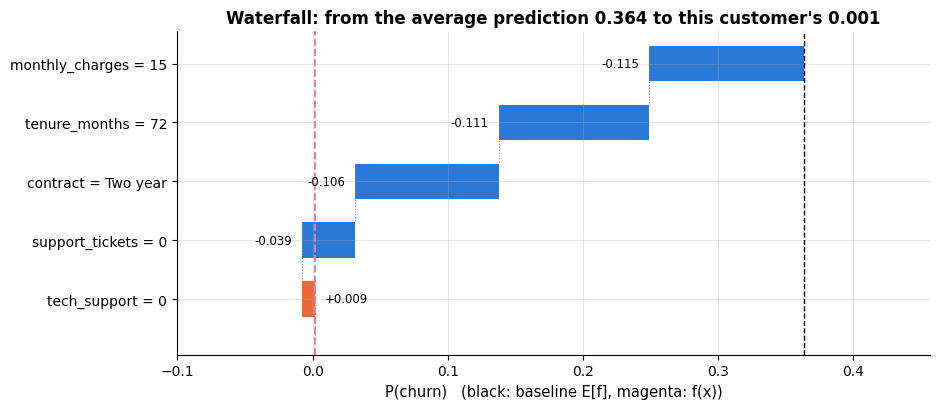

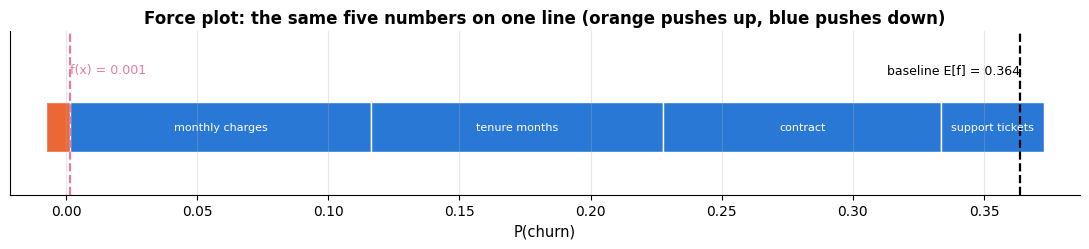

In [15]:
def waterfall(ax, base, phi, labels, title, unit="P(churn)"):
    """Waterfall plot: start at E[f], add each Shapley value in order of magnitude, end at f(x).

    ax            matplotlib axes to draw on
    base          the baseline E[f]
    phi, labels   the contributions and one text label for each
    title, unit   the panel title and the unit shown on the x-axis
    """
    phi = np.asarray(phi, dtype=float)
    order = np.argsort(-np.abs(phi))                          # largest |contribution| first
    phi, labels = phi[order], [labels[i] for i in order]
    path = base + np.concatenate([[0.0], np.cumsum(phi)])     # running total: path[0] = E[f], path[-1] = f(x)
    span = max(np.ptp(path), 1e-6)                            # np.ptp = max - min ("peak to peak"), kept above 0
    for i, p in enumerate(phi):
        # bar i starts at the running total before it (left=) and has length p; orange pushes up, blue pushes down
        ax.barh(i, p, left=path[i], height=0.6, color=PALETTE[1] if p > 0 else PALETTE[0])
        ax.plot([path[i + 1]] * 2, [i - 0.3, i + 0.7], color="gray", lw=0.8, ls=":")    # dotted connector to the next bar
        # the value, written just beyond the end of the bar
        ax.annotate(f"{p:+.3f}", (path[i + 1] + np.sign(p) * 0.02 * span, i),
                    ha="left" if p > 0 else "right", va="center", fontsize=8.5)
    ax.axvline(base, color="black", lw=1, ls="--")
    ax.axvline(path[-1], color=PALETTE[4], lw=1.4, ls="--")
    ax.set_yticks(range(len(phi)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()                                         # first (largest) contribution at the top
    ax.set_xlim(path.min() - 0.25 * span, path.max() + 0.25 * span)    # margins for the value labels
    ax.set_xlabel(f"{unit}   (black: baseline E[f], magenta: f(x))")
    ax.set_title(title)


def force_plot(ax, base, phi, labels, title, unit="P(churn)"):
    """Force plot: positive contributions push the prediction up, negative ones pull it down.

    Same arguments as waterfall(). All bars lie on one line and meet at f(x) = base + sum(phi).
    """
    phi = np.asarray(phi, dtype=float)
    out = base + phi.sum()                                   # f(x), by the efficiency property
    # sorting (value, label) tuples sorts by the value
    pos = sorted([(p, l) for p, l in zip(phi, labels) if p > 0])                 # smallest first
    neg = sorted([(p, l) for p, l in zip(phi, labels) if p <= 0])                # most negative first
    span = max(np.abs(phi).sum(), 1e-6)                      # total length of all bars
    left = out - sum(p for p, _ in pos)                      # the positive bars are stacked so that they end at f(x)
    for p, lab in pos:                                                           # largest ends up next to f(x)
        ax.barh(0, p, left=left, height=0.45, color=PALETTE[1], edgecolor="white")
        if p > 0.10 * span:                                  # label only bars wide enough to hold the text
            ax.annotate(lab, (left + p / 2, 0), ha="center", va="center", fontsize=8, color="white")
        left += p
    right = out                                              # the negative bars start at f(x) and stack to the right
    for p, lab in neg:
        ax.barh(0, -p, left=right, height=0.45, color=PALETTE[0], edgecolor="white")    # width -p > 0
        if -p > 0.10 * span:
            ax.annotate(lab, (right - p / 2, 0), ha="center", va="center", fontsize=8, color="white")
        right += -p
    lo, hi = min(out, base) - 0.06 * span, max(out, base) + 0.06 * span     # x range: both reference lines plus a margin
    for value, name, colour in [(base, f"baseline E[f] = {base:.3f}", "black"), (out, f"f(x) = {out:.3f}", PALETTE[4])]:
        ax.axvline(value, color=colour, lw=1.6, ls="--")
        side = "left" if value < (lo + hi) / 2 else "right"          # keep the label inside the axes
        ax.annotate(name, (value, 0.45), ha=side, va="bottom", fontsize=9, color=colour)
    ax.set_xlim(lo, hi)
    ax.set_yticks([])
    ax.set_ylim(-0.6, 0.85)
    ax.set_xlabel(unit)
    ax.set_title(title)


# a conditional expression inside the comprehension: numeric values rounded to whole numbers, text values as they are
shap_labels = [f"{c} = {x0[c]:.0f}" if c in NUMERIC else f"{c} = {x0[c]}" for c in SMALL]
fig, ax = plt.subplots(figsize=(9.5, 4.2))
waterfall(ax, v_empty, phi, shap_labels,
          f"Waterfall: from the average prediction {v_empty:.3f} to this customer's {v_full:.3f}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 2.6))
force_plot(ax, v_empty, phi, [c.replace("_", " ") for c in SMALL],
           "Force plot: the same five numbers on one line (orange pushes up, blue pushes down)")
plt.tight_layout()
plt.show()

Both plots say the same thing about this customer: a two-year contract, a low bill and
six years of tenure each remove about ten percentage points of churn risk, and together
they take her from the average 36 % down to almost zero. The waterfall is the better
picture for a single decision (it is explicit about the order of magnitude of each step);
the force plot fits on one line of a report and is easy to repeat for many customers.

**A case with a known answer.** For a *linear* model $f(\mathbf{x}) = b + \mathbf{w}^\top\mathbf{x}$
and a background with mean $\bar{\mathbf{z}}$, the coalition value is
$v(S) = b + \sum_{j \in S} w_j x_j + \sum_{j \notin S} w_j \bar{z}_j$, so the marginal
contribution of $j$ is $w_j(x_j - \bar{z}_j)$ *for every coalition*, and therefore

$$
\phi_j = w_j\,(x_j - \bar{z}_j) .
$$

This is the test every Shapley implementation should pass.

> **Real-life example.** A property portal prices flats with a linear model in which every
> square metre adds 3 000 €. For a 90 m² flat, explained against a background of flats that
> average 70 m², the Shapley value of floor area is 3 000 × (90 − 70) = 60 000 €: the flat's
> size accounts for 60 000 € of the gap between its predicted price and the average
> prediction — whatever its location, floor or age.

In [16]:
from sklearn.linear_model import LinearRegression

LIN = ["tenure_months", "monthly_charges", "support_tickets", "tech_support", "senior_citizen"]   # five numeric features
X_lin_train = X_train[LIN].fillna(X_train[LIN].median())     # fill any gaps with the training medians
X_lin_test = X_test[LIN].fillna(X_train[LIN].median())       # (the test rows use the training medians too)
linear = LinearRegression().fit(X_lin_train, y_train)                # a linear probability model, for the check only
bg_lin = X_lin_train.sample(100, random_state=RANDOM_STATE)          # 100 background rows
x_lin = X_lin_test.iloc[0]
phi_lin, _, _ = exact_shapley(linear.predict, x_lin, bg_lin, LIN)    # the two _ discard v(empty) and v(all)
# the closed form w_j (x_j - mean_j), element-wise for all five features at once
closed_form = linear.coef_ * (x_lin.to_numpy() - bg_lin.mean().to_numpy())
print("exact Shapley values:     ", phi_lin.round(5))
print("coefficient × (x − mean): ", closed_form.round(5))
print("identical:", np.allclose(phi_lin, closed_form))     # np.allclose: equal up to floating-point round-off

exact Shapley values:      [-0.34296 -0.25714 -0.1037   0.03273 -0.01535]
coefficient × (x − mean):  [-0.34296 -0.25714 -0.1037   0.03273 -0.01535]
identical: True


### 4.3 Approximating Shapley values: sampling and KernelSHAP

Two ideas make Shapley values practical for many features.

**Permutation sampling** (Štrumbelj & Kononenko, 2014). Use the ordering form of the
definition: draw $M$ random orderings of the features and, for each, a random background
row $\mathbf{z}$; walk through the ordering, switching features one at a time from
$\mathbf{z}$'s values to $\mathbf{x}$'s, and record the change in $f$ at each switch as the
marginal contribution of that feature. The average over the $M$ draws is an unbiased
estimate of $\phi_j$ with a standard error that shrinks as $1/\sqrt{M}$, at a cost of
$M(d+1)$ model evaluations — linear in $d$ instead of exponential.

In [17]:
def sampling_shapley(f, x, background, features, n_samples=100, rng=rng):
    """Monte-Carlo Shapley values (Štrumbelj & Kononenko, 2014): random feature orderings × random background rows.

    Each of the n_samples draws is one random ordering of the features plus one random background row z.
    Returns (estimate, standard error), two arrays with one value per feature. The cost is
    (d + 1) * n_samples model evaluations, all in a single call to f.
    """
    d = len(features)
    dtypes = background[features].dtypes.to_dict()      # remembered so the probe rows can be re-typed below
    # n_samples background rows drawn with replacement; dtype=object lets text and numbers share one array
    z = background[features].iloc[rng.integers(0, len(background), n_samples)].to_numpy(dtype=object)   # (n_samples, d)
    # x's values repeated n_samples times: a read-only view with the same shape as z, made without copying
    xv = np.broadcast_to(x[features].to_numpy(dtype=object), z.shape)
    orders = np.array([rng.permutation(d) for _ in range(n_samples)])            # orders[s, pos] = feature index
    rank = np.argsort(orders, axis=1)                                             # rank[s, j] = position of feature j
    # block `pos` holds the rows in which the first `pos` features of each ordering come from x, the rest from z
    # (np.where picks x's value where rank < pos, z's value elsewhere); d + 1 blocks give (d + 1) * n_samples rows
    rows = np.concatenate([np.where(rank < pos, xv, z) for pos in range(d + 1)])
    # one predict call for all rows; the reshape puts block pos in row pos, so preds[pos, s]
    preds = f(pd.DataFrame(rows, columns=features).astype(dtypes)).reshape(d + 1, n_samples)
    marginal = np.diff(preds, axis=0)                                             # (d, n_samples): switch at each position
    contrib = np.zeros((n_samples, d))
    # fancy indexing: the (n_samples, 1) row index broadcasts against orders (n_samples, d), so that
    # contrib[s, orders[s, pos]] receives marginal[pos, s]
    contrib[np.arange(n_samples)[:, None], orders] = marginal.T                    # scatter back to the feature that switched
    # the mean over the draws, and its standard error std / sqrt(n_samples)
    return contrib.mean(axis=0), contrib.std(axis=0) / np.sqrt(n_samples)


phi_mc, se_mc = sampling_shapley(f_small, x0, background, SMALL, n_samples=300)
comparison = pd.DataFrame({"exact": phi, "sampling M=300": phi_mc, "std. error": se_mc}, index=SMALL)
display(comparison.round(4))

,exact,sampling M=300,std. error
tenure_months,-0.1113,-0.1152,0.0100
monthly_charges,-0.1149,-0.1144,0.0099
support_tickets,-0.0392,-0.0507,0.0071
contract,-0.1059,-0.1105,0.0090
tech_support,0.0090,0.0101,0.0016


**KernelSHAP** (Lundberg & Lee, 2017) takes a different route: the Shapley values are the
solution of a *weighted linear regression* of the coalition values $v(S)$ on the binary
coalition indicators $\mathbf{z}_S \in \{0, 1\}^d$,

$$
\min_{\phi_0, \boldsymbol{\phi}} \sum_{S} \pi(S) \Big( v(S) - \phi_0 - \sum_{j \in S} \phi_j \Big)^2,
\qquad
\pi(S) = \frac{d - 1}{\binom{d}{|S|}\,|S|\,(d - |S|)},
$$

with the *Shapley kernel* $\pi$ (it gives huge weight to very small and very large
coalitions) and the constraints $\phi_0 = v(\emptyset)$, $\sum_j \phi_j = v(F) - v(\emptyset)$.
With all $2^d - 2$ coalitions the regression is exact; with a random subset it is an
approximation whose quality improves with the number of sampled coalitions. This is the
"model-agnostic" explainer of the `shap` library, and it is what connects Shapley values
to LIME: KernelSHAP is LIME with a particular kernel, loss and regularisation for which
the local model's coefficients are Shapley values.

In [18]:
def kernel_shap(f, x, background, features, n_coalitions=None, rng=rng):
    """Shapley values as a weighted least-squares fit on coalition indicators (Lundberg & Lee, 2017).

    n_coalitions   None uses all 2^d - 2 non-trivial coalitions (exact); a number draws that many at random
    Returns one value per feature; they always sum exactly to f(x) - E[f], because the
    efficiency constraint is built into the fit.
    """
    d = len(features)
    # every coalition except the empty and the full one, as tuples of feature positions (sizes 1 .. d-1)
    coalitions = [S for k in range(1, d) for S in itertools.combinations(range(d), k)]
    if n_coalitions is not None:
        # a random subset of n_coalitions of them (replace=False: no coalition twice)
        coalitions = [coalitions[i] for i in rng.choice(len(coalitions), n_coalitions, replace=False)]
    v0 = coalition_value(f, x, background, [])                 # v(empty set) = average prediction E[f]
    vF = coalition_value(f, x, background, features)           # v(all features) = f(x)
    Z = np.zeros((len(coalitions), d))                         # one 0/1 indicator row per coalition
    target, weight = np.zeros(len(coalitions)), np.zeros(len(coalitions))
    for r, S in enumerate(coalitions):
        Z[r, list(S)] = 1                                       # mark the features that are in S
        # the Shapley kernel pi(S); math.comb(d, k) is "d choose k"
        weight[r] = (d - 1) / (math.comb(d, len(S)) * len(S) * (d - len(S)))
        target[r] = coalition_value(f, x, background, [features[i] for i in S]) - v0
    # impose sum(phi) = vF - v0 by eliminating the last coefficient, then solve the weighted least squares
    # (substituting phi_d = (vF - v0) - sum of the others turns Z @ phi into
    # Z_reduced @ phi_reduced + Z[:, -1] * (vF - v0); Z[:, [-1]] keeps the shape (n, 1) so that it broadcasts)
    Z_reduced = Z[:, :-1] - Z[:, [-1]]
    target_reduced = target - Z[:, -1] * (vF - v0)
    sw = np.sqrt(weight)
    # weighted least squares = ordinary least squares after multiplying every row by sqrt(weight); [0] is the solution
    phi_reduced = np.linalg.lstsq(Z_reduced * sw[:, None], target_reduced * sw, rcond=None)[0]
    # np.r_[a, b] concatenates: the d - 1 fitted values, then the last one recovered from the constraint
    return np.r_[phi_reduced, (vF - v0) - phi_reduced.sum()]


comparison["kernel all 30"] = kernel_shap(f_small, x0, background, SMALL)                     # 2^5 - 2 = 30 coalitions
comparison["kernel 10 rnd"] = kernel_shap(f_small, x0, background, SMALL, n_coalitions=10)    # 10 random coalitions
display(comparison.drop(columns="std. error").round(4))

,exact,sampling M=300,kernel all 30,kernel 10 rnd
tenure_months,-0.1113,-0.1152,-0.1113,-0.0027
monthly_charges,-0.1149,-0.1144,-0.1149,-0.1509
support_tickets,-0.0392,-0.0507,-0.0392,-0.1022
contract,-0.1059,-0.1105,-0.1059,-0.1206
tech_support,0.0090,0.0101,0.0090,0.0141


With all 30 coalitions the KernelSHAP regression reproduces the exact values to five
decimals — as the theory promises — while ten random coalitions get one feature badly
wrong (it puts −0.003 on tenure instead of −0.111). The sampling estimator lands within
about one standard error of each exact value. So both approximations work, and the question
is what accuracy a given budget buys. The honest currency is not seconds (that depends on
your CPU) but **model evaluations** — the number of rows pushed through `predict`. A tiny
wrapper counts them, and the exact values of section 4.2 give us the error.

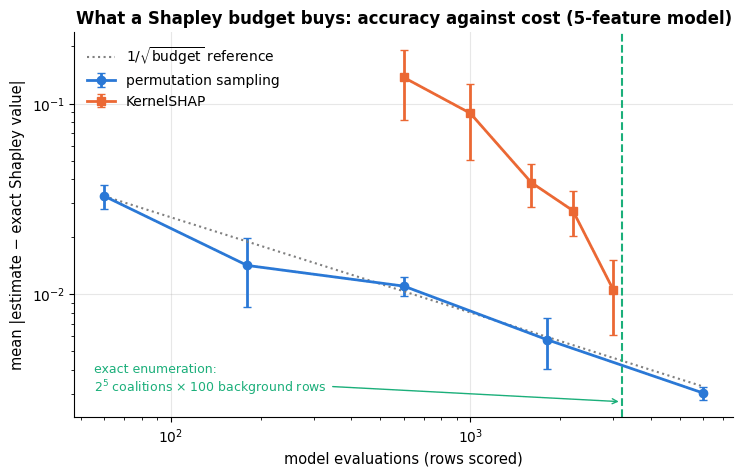

In [19]:
class CountingModel:
    """Wraps a prediction function and counts the rows an explainer pushes through the model.

    An instance is used exactly like the function it wraps; .rows holds the running total of rows scored.
    """

    def __init__(self, f):
        """Store the prediction function f and start the row counter at zero."""
        self.f, self.rows = f, 0

    def __call__(self, frame):
        """Add len(frame) to the counter, then return f(frame); __call__ makes the instance callable like a function."""
        self.rows += len(frame)
        return self.f(frame)


def error_and_cost(method, budgets, repeats=3):
    """Mean absolute error against the exact Shapley values, and the rows scored, per budget.

    method(model, budget, rng) must return Shapley estimates for x0; they are compared with the
    exact values `phi` of section 4.2. Returns an array of shape (len(budgets), 3): mean rows
    scored, mean error and the sd of the error over the repeats.
    """
    out = []
    for budget in budgets:
        errs, costs = [], []
        for r in range(repeats):
            counted = CountingModel(f_small)                           # a fresh counter for every run
            est = method(counted, budget, np.random.default_rng(100 + r))    # a different, reproducible seed per repeat
            errs.append(np.abs(est - phi).mean())
            costs.append(counted.rows)
        out.append((np.mean(costs), np.mean(errs), np.std(errs)))
    return np.array(out)


# each lambda adapts an estimator to the signature method(model, budget, rng); [0] keeps the estimate, not its error
mc = error_and_cost(lambda g, M, r: sampling_shapley(g, x0, background, SMALL, n_samples=M, rng=r)[0],
                    [10, 30, 100, 300, 1000])
ks = error_and_cost(lambda g, c, r: kernel_shap(g, x0, background, SMALL, n_coalitions=c, rng=r),
                    [4, 8, 14, 20, 28])

fig, ax = plt.subplots(figsize=(8.5, 5))
# columns of mc and ks: 0 = rows scored (x), 1 = mean error (y), 2 = sd of the error (error bar)
ax.errorbar(mc[:, 0], mc[:, 1], yerr=mc[:, 2], marker="o", color=PALETTE[0], capsize=3, label="permutation sampling")
ax.errorbar(ks[:, 0], ks[:, 1], yerr=ks[:, 2], marker="s", color=PALETTE[1], capsize=3, label="KernelSHAP")
ref = mc[0, 1] * np.sqrt(mc[0, 0] / mc[:, 0])            # a line through the first point that falls like 1 / sqrt(budget)
ax.plot(mc[:, 0], ref, color="gray", ls=":", lw=1.5, label="$1/\\sqrt{\\text{budget}}$ reference")
exact_cost = 2 ** len(SMALL) * len(background)           # 32 coalitions × 100 background rows
ax.axvline(exact_cost, color=PALETTE[2], lw=1.5, ls="--")
# xycoords=("data", "axes fraction"): the arrow tip's x is in data units, its y a fraction of the axes height;
# textcoords="axes fraction" places the text in axes fractions as well
ax.annotate("exact enumeration:\n$2^5$ coalitions × 100 background rows",
            xy=(exact_cost, 0.04), xycoords=("data", "axes fraction"),
            xytext=(0.03, 0.05), textcoords="axes fraction", fontsize=9, color=PALETTE[2],
            ha="left", va="bottom", arrowprops=dict(arrowstyle="->", color=PALETTE[2]))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("model evaluations (rows scored)")
ax.set_ylabel("mean |estimate − exact Shapley value|")
ax.set_title("What a Shapley budget buys: accuracy against cost (5-feature model)")
ax.legend()
plt.show()

Both estimators converge, and the reference line confirms the $1/\sqrt{M}$ rate of the
sampling estimator: buying one more decimal digit of accuracy costs a hundred times more
model calls. At an equal budget the permutation sampler is the more accurate of the two
here, because KernelSHAP spends a whole background pass on every coalition it draws. Note
also where the vertical line sits: exact enumeration costs 3 200 rows, about what the
sampler needs to reach an error of 0.005 — for five features the exact answer is
essentially free, so always check whether $2^d$ is small before reaching for an
approximation.

**TreeSHAP** (Lundberg et al., 2020) is the third route: for tree ensembles the expectation
over the background can be pushed *into* the trees, and exact Shapley values come out in
polynomial time — which is why `shap.TreeExplainer` can explain thousands of predictions of
a boosted model in seconds. It uses the trees' internals, so it is model-specific.

### 4.4 From local to global: beeswarm summaries

Explaining *many* predictions gives a global picture: the mean absolute Shapley value of a
feature is an importance measure with a clear meaning (the average size of its
contribution), and plotting every customer's value against the feature value — the
"beeswarm" or summary plot popularised by `shap` — shows direction, magnitude and
heterogeneity at once.

To draw one from *exact* values we need the enumeration to be fast. The trick is to notice
that $\phi = W v$ is linear in the vector of coalition values: precompute the weight matrix
$W \in \mathbb{R}^{d \times 2^d}$ once, build all $2^d \times |\text{background}|$ probe
rows for a customer in one array, and score them with a single call to `predict`.

vectorised exact values match the loop implementation: True


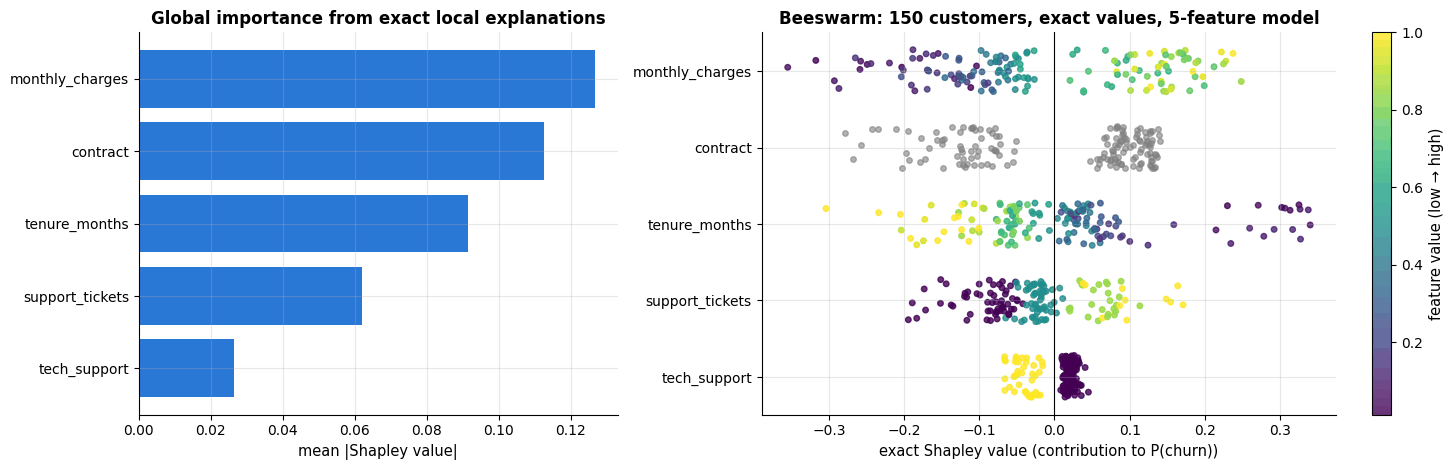

In [20]:
def shapley_weight_matrix(d):
    """W[j, S] with phi = W @ v, where v[S] is the coalition value of the bit-mask S.

    A coalition is encoded as an integer 0 .. 2^d - 1 whose bit j is 1 when feature j is in it.
    Returns W of shape (d, 2^d).
    """
    W = np.zeros((d, 1 << d))                       # 1 << d (1 shifted left by d bits) is 2**d
    for j in range(d):
        for mask in range(1 << d):
            # mask >> j & 1 is bit j of mask (>> binds more tightly than &): 1 when j is already in the coalition
            if mask >> j & 1:                       # only coalitions without j contribute
                continue
            k = bin(mask).count("1")                # |S|: bin() gives the binary string (e.g. "0b101"); count its 1s
            weight = math.factorial(k) * math.factorial(d - k - 1) / math.factorial(d)
            W[j, mask | (1 << j)] += weight         # v(S ∪ {j}); mask | (1 << j) sets bit j
            W[j, mask] -= weight                    # − v(S)
    return W


def exact_shapley_many(f, rows, background, features):
    """Exact Shapley values for several rows, one `predict` call per row.

    rows   DataFrame of the rows to explain
    Returns a DataFrame with one row per explained row and one column per feature.
    """
    d = len(features)
    masks = np.arange(1 << d)                                           # every coalition, 0 .. 2^d - 1
    take = ((masks[:, None] >> np.arange(d)) & 1).astype(bool)          # (2^d, d): is feature j in the coalition?
    W = shapley_weight_matrix(d)
    bg = background[features].to_numpy(dtype=object)                   # (n_bg, d)
    dtypes = background[features].dtypes.to_dict()
    phis = []
    for _, x in rows.iterrows():                                         # iterrows yields (index label, row as a Series)
        # broadcasting (2^d, 1, d) against (1, 1, d) and (1, n_bg, d): for every coalition and background row, take x's
        # value where the feature is in the coalition and the background value otherwise -> shape (2^d, n_bg, d)
        block = np.where(take[:, None, :], x[features].to_numpy(dtype=object)[None, None, :], bg[None, :, :])
        # flatten to (2^d * n_bg) rows, predict once, reshape to (2^d, n_bg) and average over the background: v(S)
        v = f(pd.DataFrame(block.reshape(-1, d), columns=features).astype(dtypes)).reshape(1 << d, len(bg)).mean(axis=1)
        phis.append(W @ v)                                               # (d, 2^d) @ (2^d,) -> (d,)
    return pd.DataFrame(phis, index=rows.index, columns=features)


bg_small = X_train[SMALL].sample(40, random_state=RANDOM_STATE)      # a smaller background for the 150-customer plot
# the same customer and background as in section 4.2, so the result must equal phi
check = exact_shapley_many(f_small, X_test[SMALL].iloc[[0]], background, SMALL)
print("vectorised exact values match the loop implementation:", np.allclose(check.to_numpy()[0], phi))

explained_small = X_test[SMALL].sample(150, random_state=RANDOM_STATE)
Phi_exact = exact_shapley_many(f_small, explained_small, bg_small, SMALL)     # (150, 5)
order_small = Phi_exact.abs().mean().sort_values().index                    # features by mean |phi|, smallest first

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1, 1.5]})
axes[0].barh(order_small, Phi_exact.abs().mean()[order_small], color=PALETTE[0])
axes[0].set_xlabel("mean |Shapley value|")
axes[0].set_title("Global importance from exact local explanations")
for i, col in enumerate(order_small):
    vals = Phi_exact[col].to_numpy()
    jitter = i + rng.uniform(-0.28, 0.28, len(vals))        # spread the dots vertically around row i
    if col in NUMERIC:
        # colour by percentile rank (rank(pct=True) maps the values to 0..1), so every feature spans the full colour scale
        sc = axes[1].scatter(vals, jitter, c=explained_small[col].rank(pct=True), cmap="viridis", s=16, alpha=0.8)
    else:
        axes[1].scatter(vals, jitter, color="gray", s=16, alpha=0.6, label="categorical" if i == 0 else None)
plt.colorbar(sc, ax=axes[1], label="feature value (low → high)")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_yticks(range(len(order_small)))
axes[1].set_yticklabels(order_small)
axes[1].set_xlabel("exact Shapley value (contribution to P(churn))")
axes[1].set_title("Beeswarm: 150 customers, exact values, 5-feature model")
plt.tight_layout()
plt.show()

Read the beeswarm row by row: high monthly charges (yellow) push predictions up, long
tenure (yellow) pushes them down, and `contract` splits the customers into two clouds —
one for each side of the month-to-month boundary. For the full twelve-feature model the
same picture has to be estimated by sampling; the right-hand panel below asks whether the
resulting ranking agrees with the permutation importance of section 3.1.

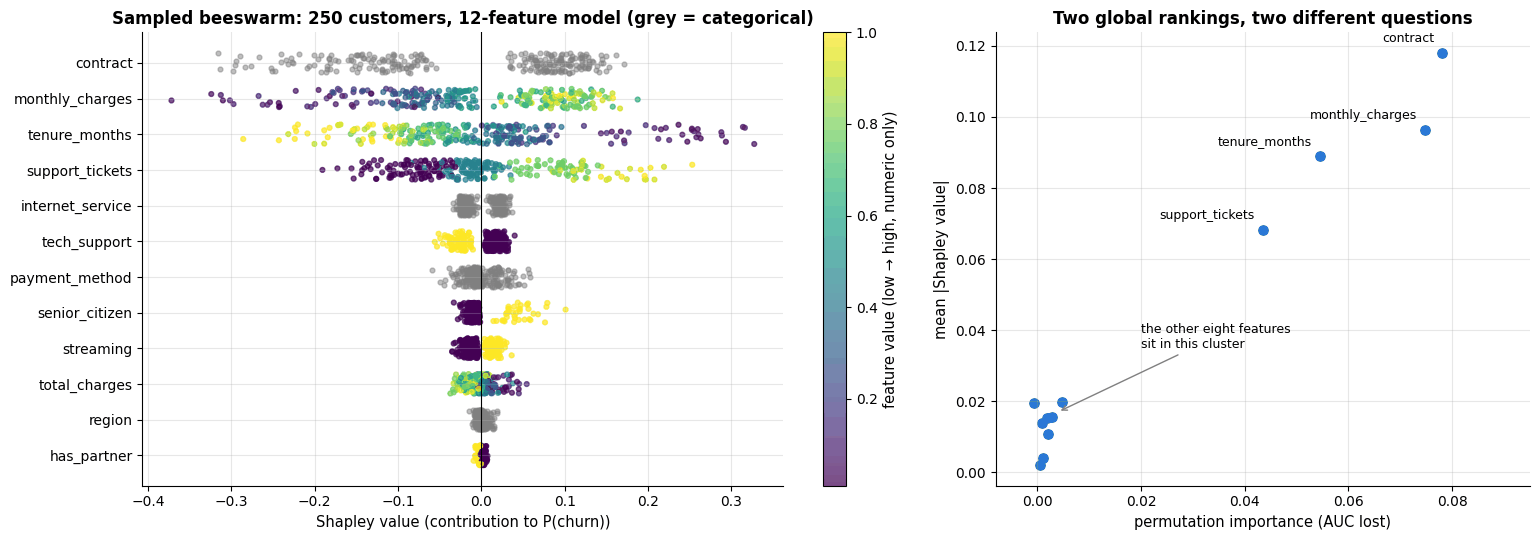

In [21]:
bg_full = X_train.sample(100, random_state=RANDOM_STATE)          # background for the 12-feature model
explained = X_test.sample(250, random_state=RANDOM_STATE)         # the customers to explain
# one sampled estimate per customer ([0] drops the standard errors); each becomes one row of Phi, shape (250, 12)
Phi = pd.DataFrame([sampling_shapley(f, row, bg_full, FEATURES, n_samples=60)[0] for _, row in explained.iterrows()],
                   index=explained.index, columns=FEATURES)
order = Phi.abs().mean().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})
for i, col in enumerate(order):
    vals = Phi[col].to_numpy()
    jitter = i + rng.uniform(-0.28, 0.28, len(vals))
    if col in NUMERIC:
        sc = axes[0].scatter(vals, jitter, c=explained[col].rank(pct=True), cmap="viridis", s=12, alpha=0.7)
    else:
        axes[0].scatter(vals, jitter, color="gray", s=12, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label="feature value (low → high, numeric only)")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(order)
axes[0].set_xlabel("Shapley value (contribution to P(churn))")
axes[0].set_title("Sampled beeswarm: 250 customers, 12-feature model (grey = categorical)")
mean_abs = Phi.abs().mean()                                          # mean |Shapley value| per feature
# mean_abs[pi_test.index] reorders it like pi_test, so each dot pairs the two numbers of the same feature
axes[1].scatter(pi_test["importance"], mean_abs[pi_test.index], s=45, color=PALETTE[0])
for col in pi_test.index[:4]:                                       # label the four drivers only
    # textcoords="offset points": xytext is an offset from the dot in points, not a data position
    axes[1].annotate(col, (pi_test.loc[col, "importance"], mean_abs[col]), fontsize=9,
                     xytext=(-6, 8), textcoords="offset points", ha="right")
axes[1].annotate("the other eight features\nsit in this cluster", xy=(0.004, 0.017), xytext=(0.02, 0.035),
                 fontsize=9, arrowprops=dict(arrowstyle="->", color="gray"))
axes[1].set_xlabel("permutation importance (AUC lost)")
axes[1].set_ylabel("mean |Shapley value|")
axes[1].set_xlim(-0.008, 0.095)
axes[1].set_title("Two global rankings, two different questions")
plt.tight_layout()
plt.show()

Here the two global measures agree — the same four drivers, in the same order, and the
other eight bunched near the origin. That is reassuring but not guaranteed, because they
ask different questions: permutation importance asks *how much does the score depend on
this feature*, mean $|\phi|$ asks *how much does this feature move individual predictions*.
A feature can move many predictions a little without helping the ranking at all, and the
exact 5-feature beeswarm above already swaps the top two. Quoting one ranking as "the"
feature importance is always an interpretation; when the two disagree, say which question
you asked.

### 4.5 The `shap` library (optional)

When `shap` is installed, `TreeExplainer` gives exact values for the boosted model in
log-odds units, with the standard plots — the same quantities we computed by hand, at a
fraction of the cost. The cell below runs only in that case; everything else in the
notebook is independent of it.

In [22]:
if HAS_SHAP:
    try:
        X_test_transformed = hgb[:-1].transform(X_test)                  # the columns the boosted model actually sees
        explainer = shap.TreeExplainer(hgb[-1])                          # TreeSHAP for the fitted boosted model itself
        sv = explainer(X_test_transformed)                               # an Explanation; values are in log-odds
        if sv.values.ndim == 3:                                          # some versions return one slice per class
            sv = sv[:, :, 1]                                             # keep the slice of class 1 (churn)
        # show=False keeps the figure open so that a title can be added before plt.show()
        shap.plots.beeswarm(sv, max_display=12, show=False)
        plt.title("TreeSHAP summary plot (log-odds units)")
        plt.show()
        shap.plots.waterfall(sv[0], show=False)                          # sv[0]: the first test customer
        plt.title("TreeSHAP explanation of the first test customer")
        plt.show()
        # Shapley value of tenure against tenure; color=sv lets shap pick the feature that interacts most with it
        shap.plots.scatter(sv[:, "tenure_months"], color=sv, show=False)
        plt.title("Dependence plot: tenure, coloured by the strongest interacting feature")
        plt.show()
    except Exception as exc:  # version incompatibilities between shap and scikit-learn happen; do not break the notebook
        print(f"shap is installed but the TreeSHAP demo failed ({type(exc).__name__}: {exc}); the from-scratch values above stand.")
else:
    print("shap not available — skipping the TreeSHAP plots (the from-scratch Shapley values above are the same quantities).")

shap not available — skipping the TreeSHAP plots (the from-scratch Shapley values above are the same quantities).


### 4.6 Counterfactual explanations: what would have to change?

Attributions say which features *contributed*; a **counterfactual explanation** (Wachter,
Mittelstadt & Russell, 2017) says what would have to be *different* for the outcome to
change — "had your contract been a two-year one, the predicted churn probability would have
been 0.25 instead of 0.76". Formally we look for the closest point with the desired
prediction,

$$
\mathbf{x}' \;=\; \arg\min_{\mathbf{x}'} \; \lambda\,\big(f(\mathbf{x}') - y'\big)^2 + d(\mathbf{x}, \mathbf{x}') ,
$$

where $d$ measures the *cost* of the change. Good counterfactuals change few features,
change only **actionable** ones (a company can offer a contract; it cannot change a
customer's tenure), and stay plausible. For a tabular model with a handful of actionable
levers, a plain search over single and paired changes is enough — no gradients required.

In [23]:
ACTIONS = {                         # actionable levers and the options a retention team could offer
    "contract": ["One year", "Two year"],
    "tech_support": [1.0],
    "payment_method": ["Bank transfer", "Credit card"],
    "monthly_charges": [-5.0, -10.0, -20.0],          # discounts, in $
}
COST = {"contract": 1.0, "tech_support": 0.5, "payment_method": 0.5, "monthly_charges": 0.05}   # per feature / per $


def counterfactual_search(f, x, max_changes=2):
    """Every combination of at most `max_changes` actionable changes, with its cost and resulting prediction.

    x   the customer (a Series of raw features)
    Returns a DataFrame with one row per candidate offer and the columns cost, new P(churn),
    n_changes and changes (a readable list of the changes).
    """
    moves = []                                                    # every single change: (feature, new value, cost)
    for feat, options in ACTIONS.items():
        for opt in options:
            # a discount is added to the current bill; the other levers replace the current value
            new_value = x[feat] + opt if feat == "monthly_charges" else opt
            if new_value != x[feat]:                              # skip "changes" to the value the customer already has
                # a discount costs per $, every other lever a flat amount
                moves.append((feat, new_value, COST[feat] * (abs(opt) if feat == "monthly_charges" else 1.0)))
    # all combinations of 1 .. max_changes moves; the condition keeps those that touch k different features
    # ({m[0] for m in c} is the set of features changed by combination c)
    combos = [c for k in range(1, max_changes + 1) for c in itertools.combinations(moves, k)
              if len({m[0] for m in c}) == k]                                   # no feature changed twice
    # one row per combination: {**a, **b} merges two dicts and b's entries win, so this is x with the changes applied
    rows = pd.DataFrame([{**x.to_dict(), **{feat: val for feat, val, _ in c}} for c in combos]).astype(DTYPES)
    return pd.DataFrame({
        "cost": [sum(m[2] for m in c) for c in combos],
        "new P(churn)": f(rows),                                  # every candidate scored in one call
        "n_changes": [len(c) for c in combos],
        "changes": [", ".join(f"{feat} → {val}" for feat, val, _ in c) for c in combos]})


def cheapest_counterfactuals(candidates, target=0.5, k=3):
    """The k cheapest candidates that bring the prediction below `target` (ties broken by the best prediction).

    candidates   the DataFrame returned by counterfactual_search
    Returns at most k rows, renumbered from 0.
    """
    hits = candidates[candidates["new P(churn)"] < target]       # only the offers that succeed
    # sort by cost, then by prediction; reset_index(drop=True) renumbers the rows 0, 1, 2, ...
    return hits.sort_values(["cost", "new P(churn)"]).head(k).reset_index(drop=True)


p_churn = pd.Series(f(X_test), index=X_test.index)       # predicted P(churn) per test customer, labelled by customer
risky = p_churn[p_churn > 0.7].index[:2]                  # the first two customers above 0.7
for idx in risky:
    x = X_test.loc[idx]
    print(f"customer {idx}: P(churn) = {p_churn[idx]:.2f} — {x['contract']}, {x['tenure_months']:.0f} months, "
          f"{x['monthly_charges']:.0f} $/month, {x['support_tickets']:.0f} tickets, tech support = {x['tech_support']:.0f}")
    display(cheapest_counterfactuals(counterfactual_search(f, x)).round(2))

# idxmax() returns the index label of the largest value: the highest-risk customer
hardest = counterfactual_search(f, X_test.loc[p_churn.idxmax()])
print(f"the highest-risk customer ({p_churn.idxmax()}, P = {p_churn.max():.2f}): the best of {len(hardest)} possible "
      f"offers still leaves P(churn) = {hardest['new P(churn)'].min():.2f} — no counterfactual exists in this budget")

customer 1746: P(churn) = 0.77 — One year, 23 months, 97 $/month, 2 tickets, tech support = 0


,cost,new P(churn),n_changes,changes
0,1.00,0.49,1,monthly_charges → 76.93
1,1.25,0.43,2,"contract → Two year, monthly_charges → 91.93"
2,1.50,0.38,2,"contract → Two year, monthly_charges → 86.93"


customer 1313: P(churn) = 0.75 — Month-to-month, 3 months, 79 $/month, 0 tickets, tech support = 1


,cost,new P(churn),n_changes,changes
0,1.00,0.25,1,contract → Two year
1,1.00,0.48,1,contract → One year
2,1.25,0.23,2,"contract → Two year, monthly_charges → 74.07"


the highest-risk customer (1704, P = 0.98): the best of 31 possible offers still leaves P(churn) = 0.51 — no counterfactual exists in this budget


The search returns concrete, ranked interventions — exactly the form in which a retention
team can act on a prediction. It is worth drawing the whole search space once: every
candidate offer as a point (what it costs, where it moves the prediction), with the
**path** taken by the cheapest successful plan from "flagged as at risk" to "below the
threshold". In a credit setting this is literally the picture of how a rejected application
becomes an accepted one.

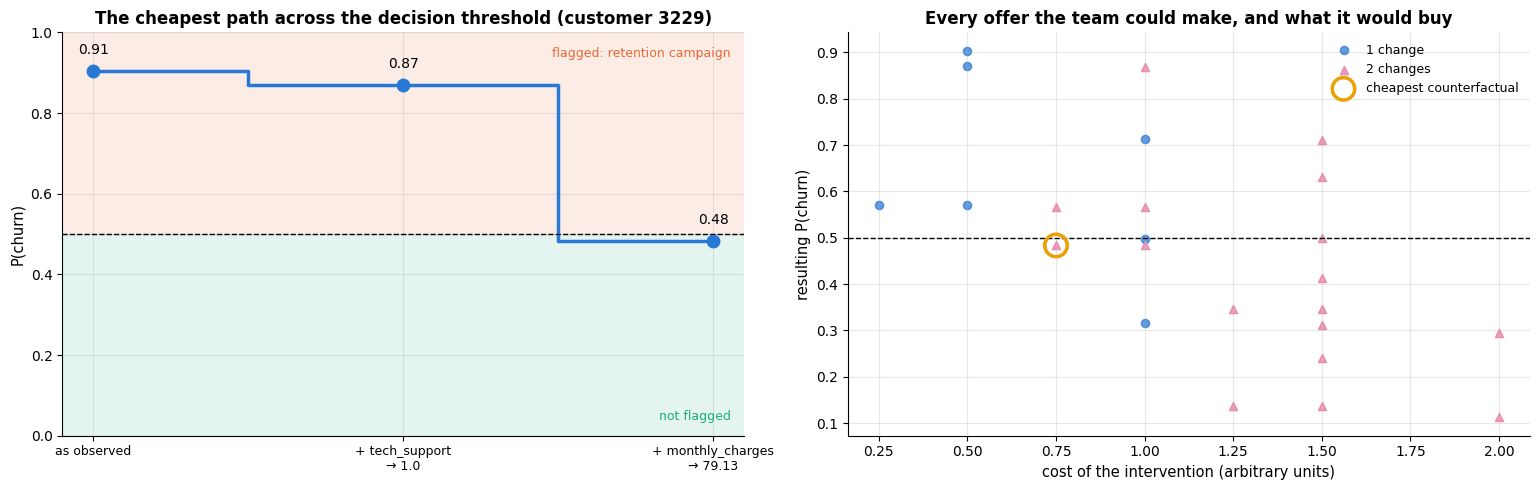

In [24]:
# pick a customer for whom no single offer is enough, so that the path has two steps
def needs_two_changes(i):
    """True when customer i has a counterfactual and the cheapest one changes two features.

    `len(cf) and ...` returns 0 (falsy) when there is no counterfactual at all, otherwise the comparison.
    """
    cf = cheapest_counterfactuals(counterfactual_search(f, X_test.loc[i]))
    return len(cf) and cf.iloc[0]["n_changes"] == 2


# next(generator, default) returns the first customer above 0.6 that needs two changes, or risky[1] if none does
idx = next((i for i in p_churn[p_churn > 0.6].index if needs_two_changes(i)), risky[1])
x_cf = X_test.loc[idx]
candidates = counterfactual_search(f, x_cf)
best = cheapest_counterfactuals(candidates, target=0.5, k=1).iloc[0]     # the single cheapest successful offer
steps = best["changes"].split(", ")                       # one string per change, e.g. "contract → Two year"
# path collects P(churn) after each step, starting with the customer as observed
current, path, path_labels = x_cf.copy(), [f(X_test.loc[[idx]])[0]], ["as observed"]
for step in steps:                                        # apply the chosen changes one at a time
    feat, val = step.split(" → ")                         # back to feature name and value (as text)
    current[feat] = float(val) if feat in NUMERIC else val    # numeric values must become numbers again
    path.append(f(pd.DataFrame([current]).astype(DTYPES))[0])    # predict the modified customer as a one-row frame
    path_labels.append("+ " + step)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5))
axes[0].axhspan(0.5, 1.0, color=PALETTE[1], alpha=0.12)    # axhspan shades a horizontal band: here 0.5 .. 1
axes[0].axhspan(0.0, 0.5, color=PALETTE[2], alpha=0.12)
# a staircase through the path; where="mid" places each step halfway between two points
axes[0].step(range(len(path)), path, where="mid", color=PALETTE[0], lw=2.5, marker="o", markersize=9)
for i, p in enumerate(path):
    axes[0].annotate(f"{p:.2f}", (i, p), xytext=(0, 12), textcoords="offset points", ha="center", fontsize=10)
axes[0].axhline(0.5, color="black", lw=1, ls="--")
axes[0].set_xticks(range(len(path)))
axes[0].set_xticklabels([lab.replace(" → ", "\n→ ") for lab in path_labels], fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("P(churn)")
# transform=axes[0].transAxes: the text position is in fractions of the axes (0..1), not in data units
axes[0].text(0.98, 0.94, "flagged: retention campaign", transform=axes[0].transAxes, fontsize=9,
             color=PALETTE[1], ha="right")
axes[0].text(0.98, 0.04, "not flagged", transform=axes[0].transAxes, fontsize=9, color=PALETTE[2], ha="right")
axes[0].set_title(f"The cheapest path across the decision threshold (customer {idx})")
for n_changes, colour, marker in [(1, PALETTE[0], "o"), (2, PALETTE[4], "^")]:
    sub = candidates[candidates["n_changes"] == n_changes]
    axes[1].scatter(sub["cost"], sub["new P(churn)"], color=colour, marker=marker, s=35, alpha=0.75,
                    label=f"{n_changes} change" + ("s" if n_changes > 1 else ""))    # "1 change" / "2 changes"
axes[1].axhline(0.5, color="black", lw=1, ls="--")
# a large hollow ring (facecolor="none") around the chosen offer
axes[1].scatter([best["cost"]], [best["new P(churn)"]], s=260, facecolor="none", edgecolor=PALETTE[3], lw=2.5,
                label="cheapest counterfactual", zorder=5)
axes[1].set_xlabel("cost of the intervention (arbitrary units)")
axes[1].set_ylabel("resulting P(churn)")
axes[1].set_title("Every offer the team could make, and what it would buy")
axes[1].legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

Two lessons hide in the right-hand panel. First, cost and effect are only loosely related:
several expensive combinations do *worse* than cheaper ones, because the model's response
is not additive — reading the scatter is how you find the offer with the best return, and
the cheapest successful plan is rarely the most effective one. Second, some customers have
**no** counterfactual at all: the printed line above shows that for the highest-risk
customer in the test set (P = 0.98) not one of the 31 possible offers brings the
probability below 0.5 — the best of them reaches 0.51. "Nothing we are willing to offer
would change this prediction" is a genuinely useful answer, not a failure of the method.

**Anchors** (Ribeiro, Singh & Guestrin, 2018) are the complementary idea: instead of the
smallest change that *flips* the prediction, find the smallest set of conditions that
*fixes* it ("as long as the contract is month-to-month and there are ≥ 2 tickets, the model
predicts churn 95 % of the time, whatever the other features").

### 4.7 Putting an explanation in front of a human

A useful report for a non-technical audience contains (1) the model's overall drivers with
their direction ("customers on month-to-month contracts with high charges and several
support tickets are at risk; risk falls sharply after the first year"), (2) for an
individual, the two or three largest contributions in plain language and in the units of
the decision (percentage points of churn probability), (3) what would change the outcome
(the counterfactual), and (4) the caveats: the model describes *associations in historical
data*, the explanation describes *the model*, and both can be wrong.

Some features need a policy discussion rather than a plot. `senior_citizen` and `region`
are in the feature set; the model is *allowed* to use them, but should it? Forcing each
value on everyone shows what the model does with them.

In [25]:
for col, values in [("senior_citizen", [0.0, 1.0]), ("region", ["North", "South", "East", "West"])]:
    # dict comprehension: for each value v, give every test customer that value and average the predictions
    effects = {v: f(X_test.assign(**{col: v})).mean() for v in values}
    # {col:15s} pads the name to 15 characters so that the two lines line up
    print(f"{col:15s} average P(churn) when set for everyone: " + ", ".join(f"{v}: {p:.3f}" for v, p in effects.items())
          + f"   (permutation importance {pi_test.loc[col, 'importance']:.4f})")

senior_citizen  average P(churn) when set for everyone: 0.0: 0.321, 1.0: 0.371   (permutation importance 0.0019)
region          average P(churn) when set for everyone: North: 0.335, South: 0.329, East: 0.327, West: 0.329   (permutation importance 0.0012)


Setting `senior_citizen = 1` for everyone raises the average predicted churn probability
by about five points, so the model does treat older customers as riskier — because in this
data they *are*; whether a retention offer may depend on age is a legal and ethical
question that notebook 19 (ethics, fairness, privacy) takes up. `region` is essentially
unused, which is reassuring only if region is not a proxy for something the model *does*
use.

### 4.8 A note on models this course does not cover

For differentiable models — neural networks — the local methods have gradient-based
cousins: **saliency maps** (Simonyan, Vedaldi & Zisserman, 2014), **integrated gradients**
(Sundararajan, Taly & Yan, 2017), **Grad-CAM** (Selvaraju et al., 2017) for convolutional
networks, and the debate over whether attention weights explain anything (Jain & Wallace,
2019). They are covered in the companion deep-learning course; this course stops at
classical models. Two of their lessons transfer unchanged and are used in section 5:
integrated gradients satisfies the same efficiency axiom as Shapley values, and the
randomisation **sanity checks** of Adebayo et al. (2018) — does the explanation change when
the model does? — apply to every method in this notebook.

## 5. Strengths, weaknesses and when to use each method

Every method above answers a slightly different question, and each has a regime in which
its answer is wrong. This section makes the two most common failures *happen* on data whose
ground truth we control (5.1, 5.2), shows that even a correct explanation describes only
*one* of several equally good models (5.3), gives the randomisation test that catches a
broken explainer (5.4), measures what each method costs (5.5), and ends with the two tables
to keep on your desk (5.6, 5.7).

### 5.1 Correlated features break permutation importance — and what fixes it

The churn experiment of section 3.2 suggested the problem; here is a controlled version.
A latent quantity $z$ drives the target, and we observe it **three times**, through noisy
measurements $x_1, x_2, x_3$; a fourth feature $x_4$ acts on its own:

$$
x_j = z + \varepsilon_j \ \ (j = 1, 2, 3), \quad
\varepsilon_j \sim \mathcal{N}(0, 0.15^2), \qquad
y = 2z + x_4 + \mathcal{N}(0, 0.5^2), \qquad z, x_4 \sim \mathcal{N}(0, 1).
$$

Three columns, one quantity: exactly the situation of the breast-cancer data in section 6,
where every nuclear measurement is reported as a mean, a standard error and a worst value.

The truth is not in dispute: the block $\{x_1, x_2, x_3\}$ carries a signal with four times
the variance of $x_4$'s. What does permutation importance say?

corr(x1, x2) = 0.979;  test R² of the model = 0.941
permutation importance, one column at a time: {'x4': 0.38, 'x2': 0.214, 'x1': 0.172, 'x3': 0.161}
permuting the three measurements together:   {'{x1,x2,x3}': 1.454, 'x4': 0.38}
drop-column importance: {'drop x1': 0.003, 'drop x1+x2+x3': 0.764, 'drop x4': 0.201}


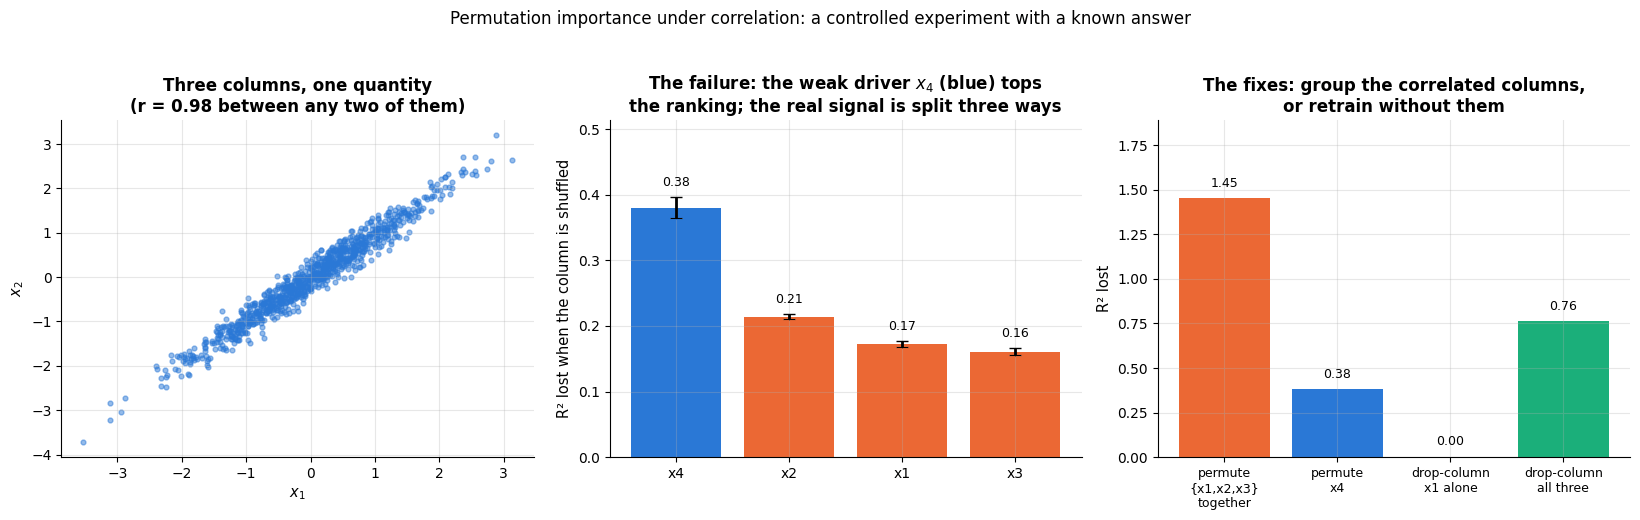

In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor     # the regression version of the boosted trees
from sklearn.metrics import r2_score                           # R²: 1 = perfect, 0 = no better than predicting the mean

syn_rng = np.random.default_rng(RANDOM_STATE)       # a dedicated generator: this experiment stands on its own
n_syn = 3000
# e.g. a field trial: z = true soil moisture, x1-x3 = three moisture probes, x4 = fertiliser dose, y = wheat yield
z_lat = syn_rng.normal(0, 1, n_syn)                 # the quantity that really drives y
x4 = syn_rng.normal(0, 1, n_syn)                    # an independent, weaker driver
# x1, x2, x3 = z + small noise (sd 0.15); `dict1 | dict2` merges two dicts (Python 3.9+), adding the x4 column
S = pd.DataFrame({f"x{i}": z_lat + syn_rng.normal(0, 0.15, n_syn) for i in (1, 2, 3)} | {"x4": x4})
y_syn = 2 * z_lat + x4 + syn_rng.normal(0, 0.5, n_syn)       # y = 2z + x4 + noise
S_train, S_test, ys_train, ys_test = train_test_split(S, y_syn, test_size=0.3, random_state=RANDOM_STATE)

syn_model = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08, max_depth=3,
                                          random_state=RANDOM_STATE).fit(S_train, ys_train)


def f_syn(frame):
    """Predictions of the synthetic regression model (model A), one per row of `frame`."""
    return syn_model.predict(frame)


def r2_of_syn(frame, target):
    """Score function for perm_importance: R² of the synthetic model on `frame`."""
    return r2_score(target, f_syn(frame))


MEASURED = ["x1", "x2", "x3"]                       # the three measurements of z
pi_single = perm_importance(r2_of_syn, S_test, ys_test, rng=np.random.default_rng(RANDOM_STATE))   # one column at a time
# the three measurements permuted together as one group, x4 on its own
pi_group = perm_importance(r2_of_syn, S_test, ys_test, groups={"{x1,x2,x3}": MEASURED, "x4": ["x4"]},
                           rng=np.random.default_rng(RANDOM_STATE))
drop_col = {}
# drop-column importance: refit without x1, without all three measurements, and without x4
for drop in (["x1"], MEASURED, ["x4"]):
    keep = [c for c in S.columns if c not in drop]
    refit = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08, max_depth=3,
                                          random_state=RANDOM_STATE).fit(S_train[keep], ys_train)
    # key such as "drop x1+x2+x3"; value = test R² of the full model minus test R² of the refitted one
    drop_col["drop " + "+".join(drop)] = r2_score(ys_test, f_syn(S_test)) - r2_score(ys_test, refit.predict(S_test[keep]))

# S.x1 is attribute access to the column "x1"; Series.corr(other) is the Pearson correlation
print(f"corr(x1, x2) = {S.x1.corr(S.x2):.3f};  test R² of the model = {r2_score(ys_test, f_syn(S_test)):.3f}")
print("permutation importance, one column at a time:", {k: round(v, 3) for k, v in pi_single["importance"].items()})
print("permuting the three measurements together:  ", {k: round(v, 3) for k, v in pi_group["importance"].items()})
print("drop-column importance:", {k: round(v, 3) for k, v in drop_col.items()})

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
axes[0].scatter(S_test.x1, S_test.x2, s=12, alpha=0.5, color=PALETTE[0])
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_title(f"Three columns, one quantity\n(r = {S.x1.corr(S.x2):.2f} between any two of them)")
# yerr adds ± 1 sd error bars; x4 in blue, the three measurements in orange
bars = axes[1].bar(pi_single.index, pi_single["importance"], yerr=pi_single["std"], capsize=4,
                   color=[PALETTE[0] if c == "x4" else PALETTE[1] for c in pi_single.index])
axes[1].bar_label(bars, fmt="%.2f", fontsize=9, padding=6)     # padding: gap between bar and label, in points
axes[1].set_ylabel("R² lost when the column is shuffled")
axes[1].set_ylim(0, max(pi_single["importance"]) * 1.35)
axes[1].set_title("The failure: the weak driver $x_4$ (blue) tops\nthe ranking; the real signal is split three ways")
fixes = pd.concat([pi_group["importance"], pd.Series(drop_col)])    # both kinds of result in one Series
keep_fixes = ["{x1,x2,x3}", "x4", "drop x1", "drop x1+x2+x3"]       # the four bars to show, in this order
bars = axes[2].bar(range(len(keep_fixes)), fixes[keep_fixes],
                   color=[PALETTE[1], PALETTE[0], PALETTE[2], PALETTE[2]])
axes[2].bar_label(bars, fmt="%.2f", fontsize=9, padding=6)
axes[2].set_xticks(range(len(keep_fixes)))
axes[2].set_xticklabels(["permute\n{x1,x2,x3}\ntogether", "permute\nx4", "drop-column\nx1 alone", "drop-column\nall three"],
                        fontsize=9)
axes[2].set_ylabel("R² lost")
axes[2].set_ylim(0, max(fixes[keep_fixes]) * 1.3)
axes[2].set_title("The fixes: group the correlated columns,\nor retrain without them")
fig.suptitle("Permutation importance under correlation: a controlled experiment with a known answer", y=1.03)
plt.tight_layout()
plt.show()

The middle panel is the failure, and it is worse than "the importance is split": ranked one
column at a time, the weak driver $x_4$ comes out **first**, ahead of all three
measurements of a signal that carries four times its variance. The mechanism is the one
from section 3.2 — when $x_1$ is shuffled the model simply reads $z$ off $x_2$ and $x_3$,
so little is lost. A reader of that plot would conclude that $x_4$ is the model's main
input. It is not.

The right-hand panel shows the two repairs. **Grouped permutation** — one shared
permutation applied to the whole correlated block — puts the block at 1.45 against 0.38
for $x_4$, restoring the 4 : 1 ratio of the data-generating process. **Drop-column
importance** gives the complementary answer: removing $x_1$ alone costs essentially
nothing (its two twins stand in), removing all three is catastrophic (0.76 of $R^2$).
Neither is "the" importance; together they say exactly what is true — *the measurement
matters, the column does not*.

> **Key idea.** Permutation importance is a statement about **columns**, not about
> quantities. When several columns measure the same thing, group them before you permute
> them — and when a stakeholder asks "can we stop collecting $x_1$?", answer with a
> drop-column experiment, not with an importance plot.

### 5.2 Correlated features break the partial dependence plot — and what fixes it

The PDP has the same weakness in a sharper form, because a PDP evaluates the model at
points that do not merely have the wrong *correlation* — they do not exist at all. To make
the failure undeniable we build two models that are **indistinguishable on every real
row** and differ only where there are no data:

$$
f_B(\mathbf{x}) \;=\; f_A(\mathbf{x}) \;+\; 3\,\max\big(0,\; |x_1 - x_2| - \delta\big)^2 ,
\qquad \delta = 0.75 ,
$$

with $\delta$ more than three standard deviations of the observed gap $|x_1 - x_2|$. No test
row is affected; the PDP, which sets $x_1$ to values far from $x_2$, walks straight into the
added term.

test R²:  model A 0.9410   model B 0.9410
largest prediction difference on the 900 real test rows: 0.00e+00


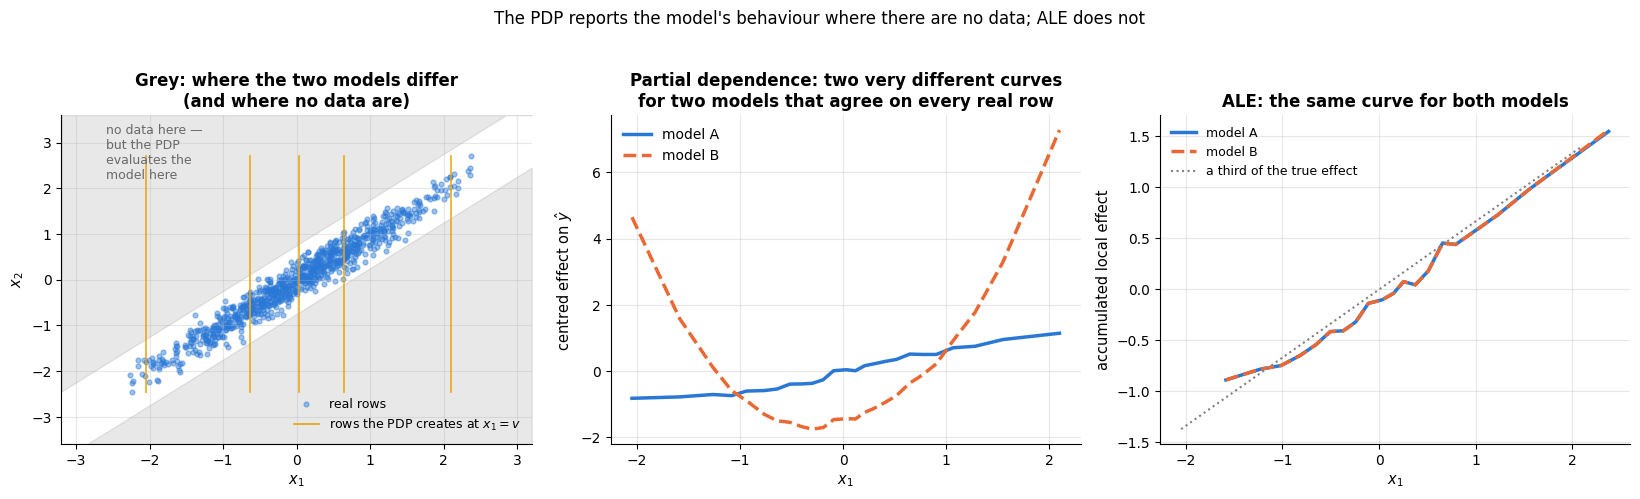

PDP range: model A 1.96, model B 9.02   (the two models are the same model on the data)
ALE range: model A 2.43, model B 2.44; largest difference between the two ALE curves: 0.013
ALE spans of x1, x2, x3 added together = 7.83, true effect of z over this range = 8.30


In [27]:
DELTA = 0.75                                        # delta: the gap |x1 - x2| beyond which model B differs from model A


def f_twin(frame):
    """A model that agrees with f_syn on every plausible row and misbehaves off the data manifold.

    Returns f_syn(frame) + 3 * max(0, |x1 - x2| - DELTA)^2, which equals f_syn wherever |x1 - x2| <= DELTA.
    """
    gap = np.abs(frame["x1"].to_numpy() - frame["x2"].to_numpy())
    return f_syn(frame) + 3.0 * np.maximum(0.0, gap - DELTA) ** 2      # np.maximum: element-wise max, 0 inside the band


print(f"test R²:  model A {r2_score(ys_test, f_syn(S_test)):.4f}   model B {r2_score(ys_test, f_twin(S_test)):.4f}")
# {...:.2e} prints in scientific notation with 2 decimals
print(f"largest prediction difference on the {len(S_test)} real test rows: {np.abs(f_syn(S_test) - f_twin(S_test)).max():.2e}")

# drop the most extreme 1 % at each end of x1, so that the grid stays inside the data
inner = S_test[S_test.x1.between(S_test.x1.quantile(0.01), S_test.x1.quantile(0.99))]
grid_syn = np.quantile(inner.x1, np.linspace(0.01, 0.99, 25))     # 25 grid points at quantiles of x1
pdp_A, _ = partial_dependence_1d(f_syn, inner, "x1", grid_syn)
pdp_B, _ = partial_dependence_1d(f_twin, inner, "x1", grid_syn)
ale_gA, ale_A = ale_1d(f_syn, inner, "x1")
ale_gB, ale_B = ale_1d(f_twin, inner, "x1")
# np.ptp (max - min) is the range each ALE curve covers; summed over x1, x2 and x3
ale_span_all = sum(np.ptp(ale_1d(f_syn, inner, c)[1]) for c in MEASURED)    # the three shares of the same effect

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
axes[0].scatter(inner.x1, inner.x2, s=12, alpha=0.45, color=PALETTE[0], label="real rows")
for v in grid_syn[::6]:                             # every sixth grid value
    # a vertical line: the rows the PDP creates when it sets x1 = v for every row
    axes[0].plot([v] * 2, [inner.x2.min(), inner.x2.max()], color=PALETTE[3], lw=1.2, alpha=0.9)
axes[0].plot([], [], color=PALETTE[3], lw=1.2, label="rows the PDP creates at $x_1 = v$")
# fill_between(x, y1, y2) shades the area between two curves; the two grey bands are where |x1 - x2| > DELTA
axes[0].fill_between([-3.2, 3.2], [-3.2 - DELTA, 3.2 - DELTA], [-3.6, -3.6], color="gray", alpha=0.18)
axes[0].fill_between([-3.2, 3.2], [3.6, 3.6], [-3.2 + DELTA, 3.2 + DELTA], color="gray", alpha=0.18)
axes[0].annotate("no data here —\nbut the PDP\nevaluates the\nmodel here", (-2.6, 2.2), fontsize=9, color="dimgray")
axes[0].set_xlim(-3.2, 3.2)
axes[0].set_ylim(-3.6, 3.6)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_title("Grey: where the two models differ\n(and where no data are)")
axes[0].legend(fontsize=9, loc="lower right")
axes[1].plot(grid_syn, pdp_A - pdp_A.mean(), lw=2.5, color=PALETTE[0], label="model A")
axes[1].plot(grid_syn, pdp_B - pdp_B.mean(), lw=2.5, color=PALETTE[1], ls="--", label="model B")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("centred effect on $\\hat{y}$")
axes[1].set_title("Partial dependence: two very different curves\nfor two models that agree on every real row")
axes[1].legend()
axes[2].plot(ale_gA, ale_A, lw=2.5, color=PALETTE[0], label="model A")
axes[2].plot(ale_gB, ale_B, lw=2.5, color=PALETTE[1], ls="--", label="model B")
# reference line with slope 2/3: a third of the true slope 2 of z, since three columns share the effect
axes[2].plot(grid_syn, (2 / 3) * (grid_syn - grid_syn.mean()), color="gray", lw=1.5, ls=":",
             label="a third of the true effect")
axes[2].set_xlabel("$x_1$")
axes[2].set_ylabel("accumulated local effect")
axes[2].set_title("ALE: the same curve for both models")
axes[2].legend(fontsize=9)
fig.suptitle("The PDP reports the model's behaviour where there are no data; ALE does not", y=1.03)
plt.tight_layout()
plt.show()

print(f"PDP range: model A {np.ptp(pdp_A):.2f}, model B {np.ptp(pdp_B):.2f}   "
      f"(the two models are the same model on the data)")
print(f"ALE range: model A {np.ptp(ale_A):.2f}, model B {np.ptp(ale_B):.2f}; "
      f"largest difference between the two ALE curves: {np.abs(ale_A - ale_B).max():.3f}")
# the true effect of z over the grid: slope 2 times the width of the grid
print(f"ALE spans of x1, x2, x3 added together = {ale_span_all:.2f}, "
      f"true effect of z over this range = {2 * np.ptp(grid_syn):.2f}")

Three numbers tell the story. The two models are *the same model* on the data — not one of
the 900 test rows comes within $\delta$ of the region where they differ, so their largest
disagreement is exactly zero and their test $R^2$ are identical to four decimals — yet the
partial dependence of $x_1$ spans 1.96 for one of them and 9.02 for the other, a factor of
four and a half, and the shape changes from a monotone rise to a U.
A PDP is therefore **not** a property of the fitted function on the data; it is a
property of the fitted function *everywhere*, and off the data the function is whatever the
training algorithm happened to leave behind.

The ALE curves, which never move a row further than its own bin, are the same for the two
models (largest difference ≈ 0.01) and add up correctly: the effects of the correlated
measurements sum to the true slope of 2 along the manifold, each of them receiving a share.
That is the right answer to the question "what does the model do when this feature changes,
given the others".

> **Warning.** Do not read this as "always use ALE". ALE gives up the PDP's clean
> interpretation as an average prediction, it needs numeric features and a bin width, and
> in the extreme case where two features are perfectly collinear the conditional effect it
> estimates is not identifiable either. The practical rule: compute the correlation matrix
> *first*; if the feature you are drawing has $|r| > 0.5$ with another one, show the ALE (or
> a 2-D PDP), not the 1-D PDP alone.

### 5.3 The Rashomon effect: same accuracy, different story

If several models fit the data equally well, "the explanation" is not well defined. Let us
quantify that on the churn data: three model families, their test AUC with bootstrap
confidence intervals, and their permutation importances side by side.

test AUC [95 % bootstrap interval]: gradient boosting 0.826 [0.799, 0.850],  logistic regression 0.824 [0.798, 0.852],  random forest 0.818 [0.792, 0.842]
Spearman rank correlation of the importance rankings: boosting vs. logistic 0.76, boosting vs. forest 0.81


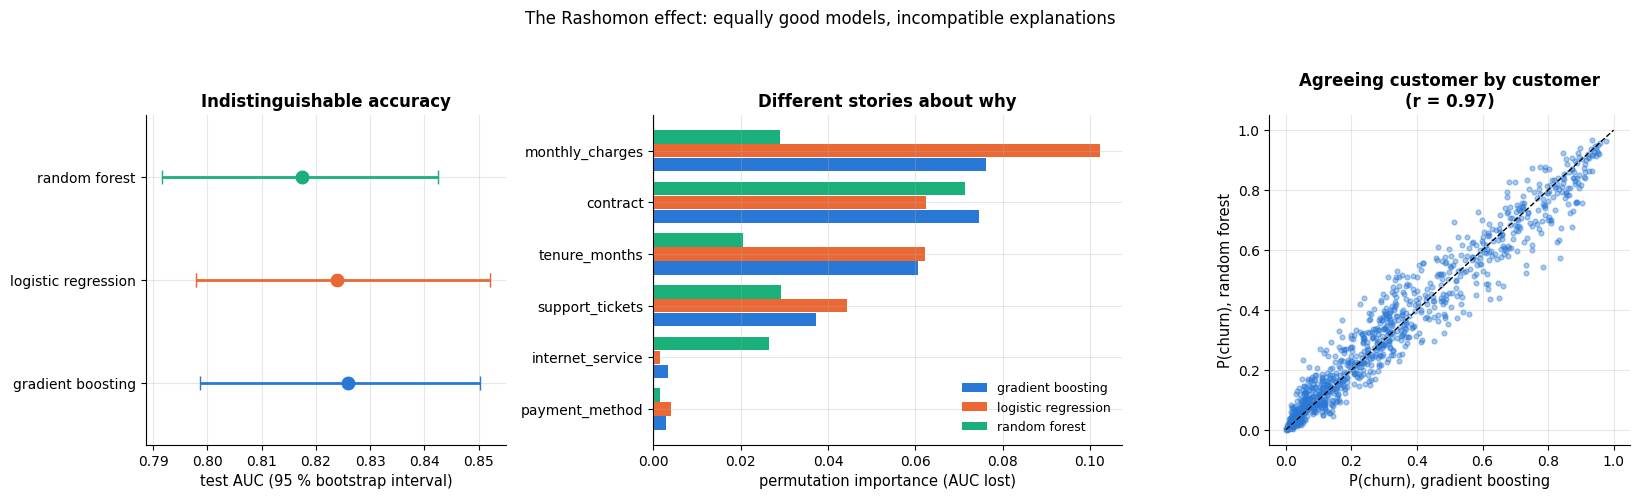

In [28]:
from scipy.stats import spearmanr          # rank correlation: do two lists put the items in the same order?
from sklearn.ensemble import RandomForestClassifier

# 100 trees, each leaf with at least 5 training rows
forest = Pipeline([("prep", make_preprocessing()),
                   ("model", RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                                    random_state=RANDOM_STATE))]).fit(X_train, y_train)
# three models, each wrapped as a function frame -> P(churn)
models = {"gradient boosting": f,
          "logistic regression": lambda fr: logreg.predict_proba(fr)[:, 1],
          "random forest": lambda fr: forest.predict_proba(fr)[:, 1]}
preds = {name: g(X_test) for name, g in models.items()}          # test predictions of each model
# 200 bootstrap resamples of the test set: each is an array of len(X_test) row positions drawn with replacement
boot_idx = [rng.integers(0, len(X_test), len(X_test)) for _ in range(200)]
y_arr = y_test.to_numpy()
# per model: the 2.5 %, 50 % and 97.5 % percentiles of the 200 bootstrap AUCs (median and 95 % interval)
auc_ci = {name: np.percentile([roc_auc_score(y_arr[i], p[i]) for i in boot_idx], [2.5, 50, 97.5])
          for name, p in preds.items()}
# permutation importances, one column per model. `g=g` stores the current g as a default argument (a lambda
# otherwise looks g up when it runs, which goes wrong if it runs after the loop has moved on)
importances = pd.DataFrame({name: perm_importance(lambda fr, t, g=g: roc_auc_score(t, g(fr)), X_test, y_test)["importance"]
                            for name, g in models.items()})
print("test AUC [95 % bootstrap interval]: " + ",  ".join(f"{k} {v[1]:.3f} [{v[0]:.3f}, {v[2]:.3f}]" for k, v in auc_ci.items()))
# spearmanr(a, b) returns (correlation, p-value); [0] keeps the correlation
print(f"Spearman rank correlation of the importance rankings: boosting vs. logistic "
      f"{spearmanr(importances['gradient boosting'], importances['logistic regression'])[0]:.2f}, "
      f"boosting vs. forest {spearmanr(importances['gradient boosting'], importances['random forest'])[0]:.2f}")

top6 = importances["gradient boosting"].sort_values().tail(6).index     # the boosted model's six most important features
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), gridspec_kw={"width_ratios": [1, 1.3, 1]})
# auc_ci.items() yields (name, array of 3 percentiles); the nested tuple unpacks them into lo, mid, hi
for i, (name, (lo, mid, hi)) in enumerate(auc_ci.items()):
    axes[0].errorbar(mid, i, xerr=[[mid - lo], [hi - mid]], fmt="o", color=PALETTE[i], capsize=5, markersize=9)
axes[0].set_yticks(range(len(auc_ci)))
axes[0].set_yticklabels(list(auc_ci))
axes[0].set_xlabel("test AUC (95 % bootstrap interval)")
axes[0].set_title("Indistinguishable accuracy")
axes[0].set_ylim(-0.6, len(auc_ci) - 0.4)
pos = np.arange(len(top6))
for i, name in enumerate(importances.columns):
    # three thin bars per feature, shifted by -0.27, 0 and +0.27
    axes[1].barh(pos + (i - 1) * 0.27, importances.loc[top6, name], height=0.26, color=PALETTE[i], label=name)
axes[1].set_yticks(pos)
axes[1].set_yticklabels(top6)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("permutation importance (AUC lost)")
axes[1].set_title("Different stories about why")
axes[1].legend(fontsize=9, loc="lower right")
axes[2].scatter(preds["gradient boosting"], preds["random forest"], s=12, alpha=0.4, color=PALETTE[0])
axes[2].plot([0, 1], [0, 1], color="black", lw=1, ls="--")
axes[2].set_xlabel("P(churn), gradient boosting")
axes[2].set_ylabel("P(churn), random forest")
# np.corrcoef returns a 2 x 2 correlation matrix; [0, 1] is the correlation between the two inputs
axes[2].set_title(f"Agreeing customer by customer\n(r = {np.corrcoef(preds['gradient boosting'], preds['random forest'])[0, 1]:.2f})")
fig.suptitle("The Rashomon effect: equally good models, incompatible explanations", y=1.03)
plt.tight_layout()
plt.show()

The three confidence intervals overlap almost completely — by any honest test these models
are equally accurate, and they agree customer by customer. Yet the importance panel shows
the boosted model leaning on `contract` where the logistic model leans on
`monthly_charges`, and the forest spreading its reliance over `internet_service` in a way
neither of the others does. *The explanation you report depends on the model you happened
to pick.* When a decision rests on the importance of one specific feature, check it across
several good models — or, following Rudin, deploy the interpretable one and explain that.

### 5.4 A sanity check every explanation should pass

Adebayo et al. (2018) proposed a test that any attribution method should survive: if you
**randomise the model**, the explanation must change. Their targets were saliency maps,
but the test is model-agnostic — fit the same pipeline to *shuffled labels*, so that it
cannot have learned anything, and compare the explanations.

test AUC: real model 0.826, label-shuffled model 0.511
predicted probabilities: real model span 0.00–0.98, shuffled model 0.16–0.58 (base rate 0.33)
mean |Shapley value| summed over features: real 0.461, shuffled 0.108; largest single feature: real 0.115 (contract), shuffled 0.032 (monthly_charges)


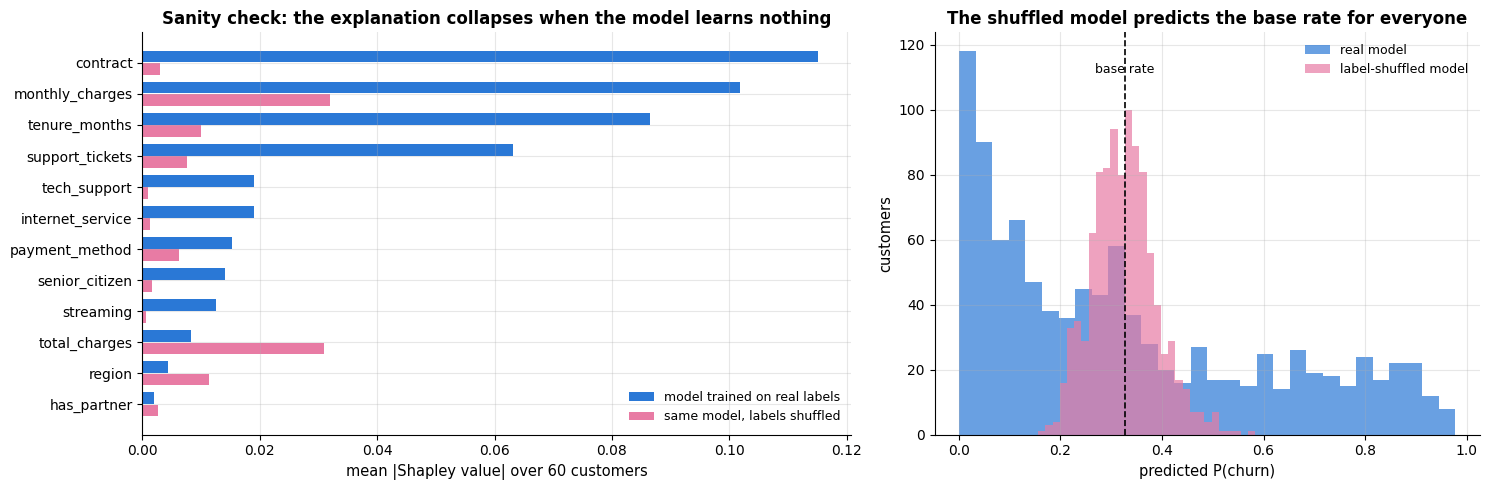

In [29]:
# the training labels in random order: any link between the features and the label is destroyed
y_shuffled = pd.Series(rng.permutation(y_train.to_numpy()), index=y_train.index)
hgb_random = Pipeline([("prep", make_preprocessing()),
                       ("model", HistGradientBoostingClassifier(**HGB_PARAMS))]).fit(X_train, y_shuffled)


def f_random(frame):
    """P(churn) of the model trained on shuffled labels (the randomised model of the sanity check)."""
    return hgb_random.predict_proba(frame)[:, 1]


check_rows = X_test.sample(60, random_state=RANDOM_STATE)
# mean |Shapley value| per feature over 60 customers, for the real model and for the randomised one
phi_real = pd.DataFrame([sampling_shapley(f, r, bg_full, FEATURES, n_samples=50)[0] for _, r in check_rows.iterrows()],
                        columns=FEATURES).abs().mean()
phi_rand = pd.DataFrame([sampling_shapley(f_random, r, bg_full, FEATURES, n_samples=50)[0] for _, r in check_rows.iterrows()],
                        columns=FEATURES).abs().mean()
print(f"test AUC: real model {roc_auc_score(y_test, f(X_test)):.3f}, label-shuffled model {roc_auc_score(y_test, f_random(X_test)):.3f}")
print(f"predicted probabilities: real model span {f(X_test).min():.2f}–{f(X_test).max():.2f}, "
      f"shuffled model {f_random(X_test).min():.2f}–{f_random(X_test).max():.2f} (base rate {y_train.mean():.2f})")
# .idxmax() gives the name of the feature with the largest mean |phi|
print(f"mean |Shapley value| summed over features: real {phi_real.sum():.3f}, shuffled {phi_rand.sum():.3f}; "
      f"largest single feature: real {phi_real.max():.3f} ({phi_real.idxmax()}), shuffled {phi_rand.max():.3f} ({phi_rand.idxmax()})")

order_check = phi_real.sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.3, 1]})
pos = np.arange(len(order_check))
axes[0].barh(pos + 0.2, phi_real[order_check], height=0.38, color=PALETTE[0], label="model trained on real labels")
axes[0].barh(pos - 0.2, phi_rand[order_check], height=0.38, color=PALETTE[4], label="same model, labels shuffled")
axes[0].set_yticks(pos)
axes[0].set_yticklabels(order_check)
axes[0].set_xlabel("mean |Shapley value| over 60 customers")
axes[0].set_title("Sanity check: the explanation collapses when the model learns nothing")
axes[0].legend(fontsize=9, loc="lower right")
axes[1].hist(f(X_test), bins=30, alpha=0.7, color=PALETTE[0], label="real model")    # histogram of the predictions
axes[1].hist(f_random(X_test), bins=30, alpha=0.7, color=PALETTE[4], label="label-shuffled model")
axes[1].axvline(y_train.mean(), color="black", lw=1.2, ls="--")
# place the label at 90 % of the panel's height (get_ylim() returns (bottom, top))
axes[1].annotate("base rate", (y_train.mean(), axes[1].get_ylim()[1] * 0.9), fontsize=9, ha="center")
axes[1].set_xlabel("predicted P(churn)")
axes[1].set_ylabel("customers")
axes[1].set_title("The shuffled model predicts the base rate for everyone")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

The shuffled model is at chance on the test set and squeezes every customer into a narrow
band around the base rate; the attributions shrink accordingly — about four times smaller
in total, with no feature standing out and a completely different ranking (`contract`, the
real model's strongest driver, all but disappears). Our implementation passes the test.
An implementation that did *not* — one that produced the same ranking for both models —
would be reporting properties of the *data*, or of the plotting code, not of the model.

Two details are worth noticing. The shuffled model's attributions are not exactly zero,
because with 4 000 rows and 150 trees it still memorises noise — and it does so through the
high-cardinality numeric columns (`monthly_charges`, `tenure_months`, `total_charges`),
which offer the most split points; the same bias Strobl et al. (2007) documented for
impurity importance. And an explanation method can only be as
honest as its model: run this check whenever you adopt a new explanation library, and run
the complementary one too — add a column of pure noise to the training data and verify that
every method gives it an importance indistinguishable from zero.

### 5.5 What each explanation costs

Cost decides which method you can afford in a batch job that must explain a million
predictions a night. The portable unit is not seconds but **model evaluations** — rows
pushed through `predict` — because that is what scales with the model, the background set
and the grid. The `CountingModel` from section 4.3 measures both.

exact Shapley for all 12 features would need 2^12 × 100 = 409,600 rows ≈ 11 s per customer at the rate measured here


,scope,seconds,rows scored
method,,,
permutation importance,whole model,0.545,18300
PDP + ICE,whole model,0.174,7500
ALE,whole model,0.234,600
global surrogate tree,whole model,0.024,4000
LIME,one prediction,0.021,2000
Shapley sampling,one prediction,0.014,1300
KernelSHAP,one prediction,1.372,20200
counterfactual search,one prediction,0.008,23


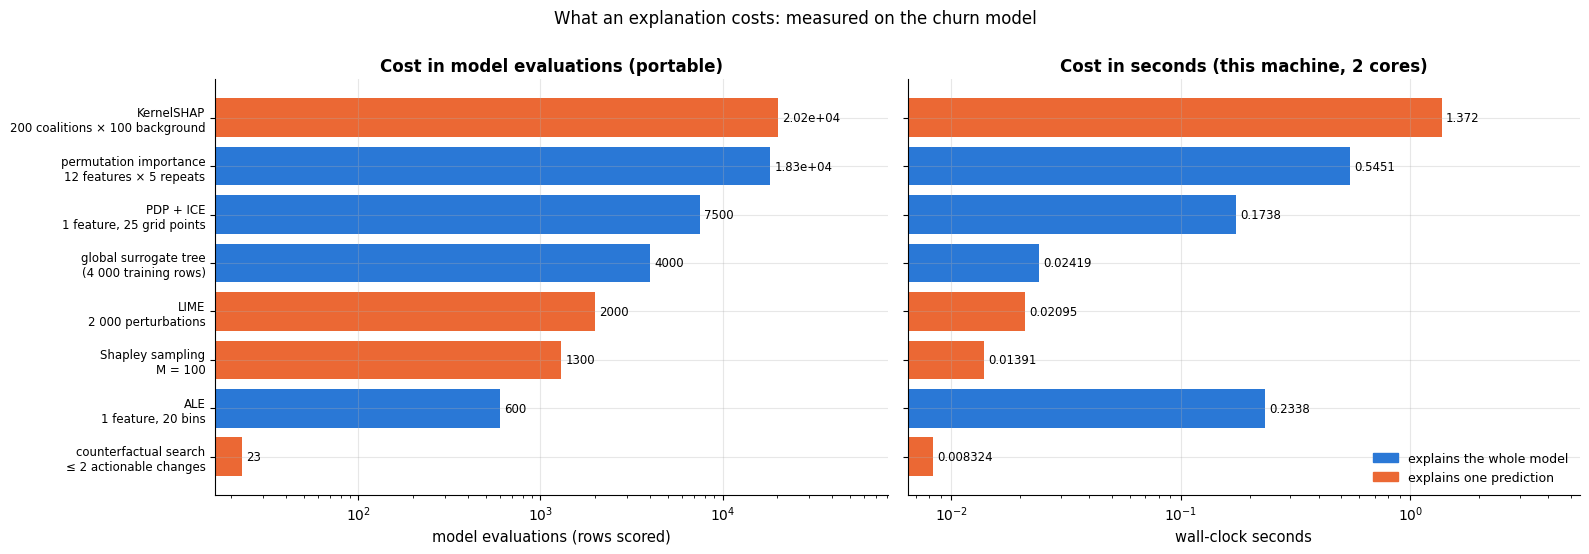

In [30]:
bench_rows = filled.sample(300, random_state=RANDOM_STATE)    # 300 test rows with the gaps filled (ALE needs that)
bench_y = y_test.loc[bench_rows.index]                        # their labels
x_bench = X_test.iloc[5]                                      # the customer explained in section 4.1


def measure(label, scope, run):
    """Run one explanation method and record what it costs.

    run(model) must run the method with `model` as its prediction function; it receives a
    CountingModel wrapped around f. Returns a dict with the label, the scope, the wall-clock
    seconds and the number of rows scored.
    """
    counted = CountingModel(f)
    t0 = time.perf_counter()                 # high-resolution clock, in seconds
    run(counted)
    return {"method": label, "scope": scope, "seconds": time.perf_counter() - t0, "rows scored": counted.rows}


# one measure(...) per method; each lambda receives the counting model g and runs the method with it.
# The list of dicts becomes a DataFrame with one row per method
costs = pd.DataFrame([
    measure("permutation importance\n12 features × 5 repeats", "whole model",
            lambda g: perm_importance(lambda fr, t: roc_auc_score(t, g(fr)), bench_rows, bench_y)),
    measure("PDP + ICE\n1 feature, 25 grid points", "whole model",
            lambda g: partial_dependence_1d(g, bench_rows, "tenure_months", grid_tenure)),
    measure("ALE\n1 feature, 20 bins", "whole model",
            lambda g: ale_1d(g, bench_rows, "tenure_months")),
    measure("global surrogate tree\n(4 000 training rows)", "whole model",
            lambda g: DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train_t, g(X_train))),
    measure("LIME\n2 000 perturbations", "one prediction",
            lambda g: lime_explain(g, x_bench, X_train, NUMERIC)),
    measure("Shapley sampling\nM = 100", "one prediction",
            lambda g: sampling_shapley(g, x_bench, bg_full, FEATURES, n_samples=100)),
    measure("KernelSHAP\n200 coalitions × 100 background", "one prediction",
            lambda g: kernel_shap(g, x_bench, bg_full, FEATURES, n_coalitions=200)),
    measure("counterfactual search\n≤ 2 actionable changes", "one prediction",
            lambda g: counterfactual_search(g, x_bench)),
])
costs["rows per second"] = costs["rows scored"] / costs["seconds"]
exact_rows = 2 ** len(FEATURES) * len(bg_full)           # 2^12 coalitions × 100 background rows
# {exact_rows:,} prints the number with thousands separators; the speed is the median over the eight methods
print(f"exact Shapley for all {len(FEATURES)} features would need 2^12 × 100 = {exact_rows:,} rows "
      f"≈ {exact_rows / costs['rows per second'].median():.0f} s per customer at the rate measured here")
# for the table, keep only the first line of each label (.str.split("\n").str[0]) and use it as the row index
display(costs.assign(method=lambda d: d["method"].str.split("\n").str[0])
        .set_index("method")[["scope", "seconds", "rows scored"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
order_cost = costs.sort_values("rows scored").index
# blue for the global methods, orange for the local ones
colours = [PALETTE[0] if costs.loc[i, "scope"] == "whole model" else PALETTE[1] for i in order_cost]
for ax, col, label in [(axes[0], "rows scored", "model evaluations (rows scored)"),
                       (axes[1], "seconds", "wall-clock seconds")]:
    bars = ax.barh(range(len(order_cost)), costs.loc[order_cost, col], color=colours)
    ax.bar_label(bars, fmt="%.4g", fontsize=8.5, padding=3)      # "%.4g": at most 4 significant digits
    ax.set_xscale("log")
    ax.set_xlabel(label)
    ax.set_xlim(right=costs[col].max() * 4)                       # room on the right for the labels
axes[0].set_yticks(range(len(order_cost)))
axes[0].set_yticklabels(costs.loc[order_cost, "method"], fontsize=8.5)
axes[0].set_title("Cost in model evaluations (portable)")
axes[1].set_title("Cost in seconds (this machine, 2 cores)")
# two rectangles that are never drawn, used only as the legend's colour symbols
handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[0]), plt.Rectangle((0, 0), 1, 1, color=PALETTE[1])]
axes[1].legend(handles, ["explains the whole model", "explains one prediction"], fontsize=9, loc="lower right")
fig.suptitle("What an explanation costs: measured on the churn model", y=1.0)
plt.tight_layout()
plt.show()

Read the two panels together — and note where they disagree. The global methods are cheap
*once*: a full permutation importance costs $d \times R \times n$ rows and a PDP
$|{\rm grid}| \times n$, both a matter of seconds for a 12-feature model. ALE is the
cheapest of all in rows (600, two per row of the sample) and yet one of the slowest in
seconds, because our implementation spreads those rows over forty tiny `predict` calls and
per-call overhead dominates: a portable cost model tells you how an algorithm *scales*,
profiling tells you what it *costs today*. The local methods are cheap *per prediction* but
you pay again for every prediction: at roughly 1 300 rows per customer, Shapley sampling
for a million customers is 1.3 billion model evaluations — the reason TreeSHAP (which
exploits the tree structure instead of probing) exists. And exact Shapley for all twelve
features would need $2^{12} \times 100 \approx 4 \cdot 10^5$ rows *per customer*: fine for
the three customers in a report, impossible for a batch job.

### 5.6 The comparison table

| Method | The question it answers | What it assumes | Where it misleads | Cost (model evaluations) |
|---|---|---|---|---|
| **Coefficients + bootstrap CI** (intrinsic, global) | how much does the log-odds move per unit of $x_j$, all else equal? | the model *is* linear (in the chosen basis); features can vary independently | collinearity inflates and flips coefficients; "all else equal" may be impossible | free (refits for the CI: $B$ fits) |
| **GAM shape functions** (intrinsic, global) | what is the *shape* of each feature's effect? | additivity: no interactions | hides interactions entirely; wiggly at the edges where data are sparse | free |
| **Tree rules / monotonic constraints** (intrinsic) | which conditions lead to which prediction? | axis-aligned structure; the constraint is true | a deep tree is not simulatable; constraints that are false cost accuracy | free |
| **Permutation importance** (post-hoc, global) | how much does the *score* depend on column $j$? | the permuted rows are plausible; features are independent | correlated columns share and dilute importance (5.1); off-manifold extrapolation; says nothing about direction | $d \times R \times n$ |
| **Drop-column importance** (post-hoc, global) | how much worse would a model trained *without* $x_j$ be? | retraining is affordable and stable | answers a different question from permutation; near-zero for any duplicated feature | $d$ refits |
| **Partial dependence (PDP)** (post-hoc, global) | what is the average prediction as $x_j$ varies? | the feature can be moved independently of the others | correlated features ⇒ the curve is read off regions with no data (5.2); averages away interactions | $\lvert\text{grid}\rvert \times n$ |
| **ICE curves** (post-hoc, local + global) | does the effect differ between individuals? | as PDP | as PDP, plus visual overload beyond ~100 curves | $\lvert\text{grid}\rvert \times n$ |
| **ALE** (post-hoc, global) | what is the *conditional* effect of $x_j$, given the others? | a meaningful local neighbourhood (numeric feature, enough rows per bin) | noisy with few rows per bin; not defined for categoricals without an order; no "average prediction" reading | $2n$ |
| **Global surrogate** (post-hoc, global) | can the model be summarised by simple rules? | the black box is mostly simple | high fidelity ≠ correct in the interesting cases; rules invite a causal reading | $n$ + one fit |
| **LIME** (post-hoc, local) | which features move *this* prediction locally? | local linearity; a sensible perturbation distribution and kernel width | unstable across seeds; kernel width changes the answer; perturbations leave the manifold | $\approx$ 2 000 per prediction |
| **Shapley values** (post-hoc, local) | how do I split this prediction fairly among the features? | a background distribution; features can be swapped in independently | exact cost $2^d$; sampling error; off-manifold coalitions; *not* causal, and not "what if we changed it" | $M(d{+}1)$ sampled, $2^d \lvert B \rvert$ exact, near-free with TreeSHAP |
| **Counterfactuals** (post-hoc, local) | what would have to change for the decision to flip? | the levers are actionable and the model is valid at the new point | ignores what is *feasible* in the world; many equally good counterfactuals; may leave the data manifold | one per candidate |

Three judgements to go with the table.

**Global importance is a ranking of columns, not of causes.** Every method in the top half
answers "what does *this model* use", and section 5.1 showed that even that question has
several defensible answers when columns are correlated. If the question is really "what
would happen if we intervened", no attribution method can answer it — you need an
experiment or a causal model.

**Local attributions and counterfactuals answer different questions, and users confuse
them.** A Shapley value of $-0.11$ for `contract = Two year` means "relative to a typical
customer, this contract accounts for eleven points of the gap"; it does *not* mean "switching
this customer to month-to-month would add eleven points". The counterfactual search is the
tool for the second question, and its answer is usually a different feature.

**Fidelity is the only defence against a plausible-looking lie.** Always report the number
that says how good the approximation is: the surrogate's $R^2$, LIME's weighted $R^2$, the
Monte-Carlo standard error of a sampled Shapley value, the efficiency check
$\sum_j \phi_j = f(\mathbf{x}) - \mathbb{E}[f]$. An explanation without a fidelity measure
is a picture, not a measurement.

### 5.7 Which method when

| If you need to … | use | and watch out for |
|---|---|---|
| a one-page summary of a model for a review | permutation importance (grouped) + PDP/ALE of the top 3 features | correlated columns; report the error bars |
| to debug a suspiciously good model | permutation importance on **training** data, then drop-column for the suspect | leakage hides in near-duplicate columns |
| to explain one decision to the person affected | Shapley values (waterfall) **and** a counterfactual | say which is "why" and which is "what would change it" |
| to explain a million decisions nightly | TreeSHAP if the model is a tree ensemble; otherwise sampled Shapley with a small background | cost is linear in the number of predictions |
| to satisfy a regulator | an intrinsically interpretable model, or a documented post-hoc pipeline with fidelity measures | post-hoc explanations of a black box can be attacked (Slack et al., 2020) |
| to decide whether to keep collecting a feature | drop-column importance | permutation importance answers a different question |
| to understand an interaction | 2-D PDP, ICE fan-out, or grouped curves per category | a flat 1-D PDP can hide two opposite effects |

> **Warning — three pitfalls to repeat to every audience.** *Explaining the model is not
> explaining the world*: monthly charges may matter to the model because they proxy for
> fibre-optic service, not because a discount would retain anyone — only an experiment can
> tell. *The Rashomon effect* (5.3): another equally accurate model may explain the same
> predictions differently. *Explanations have hyper-parameters and can be gamed*: the
> background set, the kernel width and the perturbation distribution all change the numbers,
> and Slack et al. (2020) built models that look innocuous to LIME and SHAP while
> discriminating on the real data. Treat explanations as evidence, not proof.

## 6. Case study: explaining a breast-cancer risk model

Everything so far ran on simulated churn data, where we knew the generating process. Now
the real thing: the **Wisconsin breast-cancer** data (Street, Wolberg & Mangasarian, 1993),
569 fine-needle aspirates of breast masses, each summarised by 30 features — ten nuclear
measurements (radius, texture, perimeter, area, smoothness, compactness, concavity,
concave points, symmetry, fractal dimension), each reported as a *mean*, a *standard error*
and a *worst* (largest) value over the nuclei in the image. The same data are used in
notebooks 5, 7 and 8. The task: predict whether the mass is **malignant**. The audience:
a clinician who will not accept "the model said so".

### 6.1 The data and two models

In [31]:
from sklearn.datasets import load_breast_cancer       # the Wisconsin breast-cancer data, shipped with scikit-learn

bc = load_breast_cancer(as_frame=True)                # as_frame=True: bc.data is a DataFrame, bc.target a Series
X_bc = bc.data                                        # 30 numeric features, no missing values
y_bc = (bc.target == 0).astype(int)                   # 1 = malignant (scikit-learn codes malignant as 0)
# 70 % / 30 % split with the same share of malignant cases in both parts
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.3, stratify=y_bc, random_state=RANDOM_STATE)

bc_box = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.08, max_depth=3,
                                        random_state=RANDOM_STATE).fit(X_bc_train, y_bc_train)
bc_linear = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000)).fit(X_bc_train, y_bc_train)


def f_bc(frame):
    """The black box: P(malignant | x), one probability per row of a DataFrame with the 30 features."""
    return bc_box.predict_proba(frame)[:, 1]


bg_bc = X_bc_train.sample(60, random_state=RANDOM_STATE)        # background for the Shapley values
BC_FEATURES = list(X_bc.columns)
# the 30 x 30 matrix of absolute correlations; np.triu_indices(30, 1) picks the entries above the diagonal,
# i.e. every pair of features once: 30 * 29 / 2 = 435 values
corr_bc = X_bc_train.corr().abs().to_numpy()[np.triu_indices(len(BC_FEATURES), 1)]
print(f"{len(X_bc_train)} training / {len(X_bc_test)} test biopsies, {y_bc.mean():.1%} malignant")
print(f"test AUC: gradient boosting {roc_auc_score(y_bc_test, f_bc(X_bc_test)):.4f}   "
      f"logistic regression {roc_auc_score(y_bc_test, bc_linear.predict_proba(X_bc_test)[:, 1]):.4f}")
# (corr_bc > 0.9).sum() counts the pairs above 0.9 (each True counts as 1)
print(f"feature correlations: mean |r| = {corr_bc.mean():.2f}, "
      f"{(corr_bc > 0.9).sum()} of {len(corr_bc)} pairs above 0.9 — expect the trouble of section 5.1")

398 training / 171 test biopsies, 37.3% malignant
test AUC: gradient boosting 0.9961   logistic regression 0.9975
feature correlations: mean |r| = 0.39, 21 of 435 pairs above 0.9 — expect the trouble of section 5.1


The logistic regression is at least as accurate as the boosted trees — on 30 well-behaved
numeric features, Rudin's argument applies with full force, and a clinical deployment
should probably use the linear model and read its coefficients. We continue with the black
box because the point of this section is the workflow; a real project would report both.

### 6.2 What does the model use? (and why the obvious answer is wrong)

Twenty-one of the 435 feature pairs are correlated above 0.9 — the same measurement appears
three times (mean, error, worst), and radius, perimeter and area are three names for size.
Section 5.1 predicts what per-column permutation importance will do here, so we compute it
three ways: column by column, grouped by *measurement*, and grouped by *concept*.

largest single-column importance: 0.0047 AUC (worst concave points)
top measurement groups: {'concave points': 0.027, 'texture': 0.011, 'area': 0.009}
concept groups:         {'size': 0.104, 'shape': 0.066, 'texture and smoothness': 0.018}


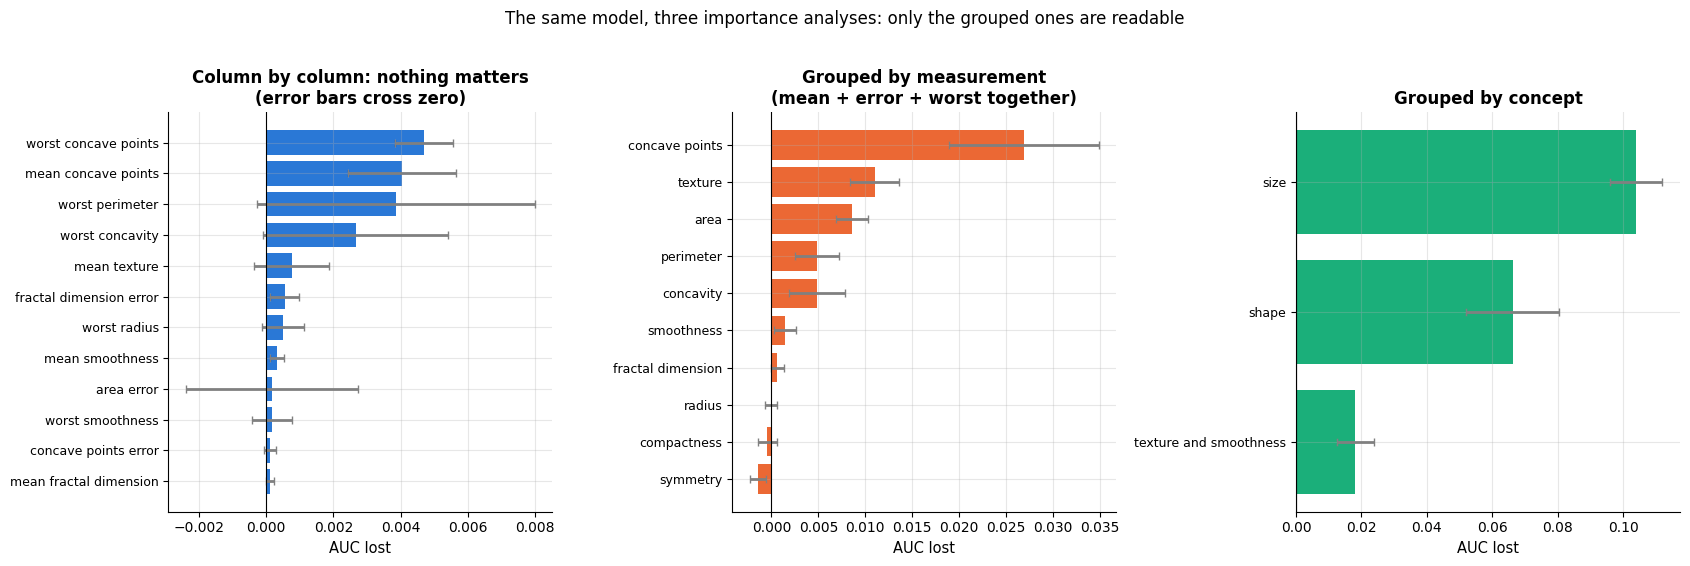

In [32]:
MEASUREMENT_GROUPS = {}
for col in BC_FEATURES:                                     # "worst radius" / "radius error" / "mean radius" -> "radius"
    # setdefault(key, []) returns the list stored under key, creating an empty one first if the key is new
    MEASUREMENT_GROUPS.setdefault(col.replace("mean ", "").replace("worst ", "").replace(" error", ""), []).append(col)
# any(k in c for k in [...]) is True when the column name contains at least one of the substrings
CONCEPT_GROUPS = {
    "size (radius, perimeter, area)": [c for c in BC_FEATURES if any(k in c for k in ["radius", "perimeter", "area"])],
    "shape (concavity, compactness, symmetry, fractal dim.)":
        [c for c in BC_FEATURES if any(k in c for k in ["concav", "compactness", "symmetry", "fractal"])],
    "texture and smoothness": [c for c in BC_FEATURES if any(k in c for k in ["texture", "smoothness"])]}


def auc_of_bc(frame, target):
    """Score function for perm_importance: the AUC of the breast-cancer model on `frame`."""
    return roc_auc_score(target, f_bc(frame))


pi_bc = perm_importance(auc_of_bc, X_bc_test, y_bc_test, n_repeats=5)                                # column by column
pi_bc_measure = perm_importance(auc_of_bc, X_bc_test, y_bc_test, groups=MEASUREMENT_GROUPS, n_repeats=5)   # 10 groups
pi_bc_concept = perm_importance(auc_of_bc, X_bc_test, y_bc_test, groups=CONCEPT_GROUPS, n_repeats=5)       # 3 groups
print(f"largest single-column importance: {pi_bc['importance'].max():.4f} AUC ({pi_bc['importance'].idxmax()})")
# the results are sorted, so head(3) gives the three most important groups
print("top measurement groups:", {k: round(v, 3) for k, v in pi_bc_measure["importance"].head(3).items()})
# k.split(" (")[0] drops the part of the name in parentheses
print("concept groups:        ", {k.split(" (")[0]: round(v, 3) for k, v in pi_bc_concept["importance"].items()})

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
top12 = pi_bc["importance"].sort_values().tail(12)         # the 12 most important single columns, smallest first
axes[0].barh(top12.index, top12, xerr=pi_bc.loc[top12.index, "std"], color=PALETTE[0],
             error_kw=dict(ecolor="gray", capsize=3))
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("AUC lost")
axes[0].set_title("Column by column: nothing matters\n(error bars cross zero)")
grp = pi_bc_measure["importance"].sort_values()
axes[1].barh(grp.index, grp, xerr=pi_bc_measure.loc[grp.index, "std"], color=PALETTE[1],
             error_kw=dict(ecolor="gray", capsize=3))
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("AUC lost")
axes[1].set_title("Grouped by measurement\n(mean + error + worst together)")
con = pi_bc_concept["importance"].sort_values()
axes[2].barh([c.split(" (")[0] for c in con.index], con, xerr=pi_bc_concept.loc[con.index, "std"],
             color=PALETTE[2], error_kw=dict(ecolor="gray", capsize=3))
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set_xlabel("AUC lost")
axes[2].set_title("Grouped by concept")
for ax in axes:
    ax.tick_params(axis="y", labelsize=9)                  # smaller labels for the long feature names
fig.suptitle("The same model, three importance analyses: only the grouped ones are readable", y=1.02)
plt.tight_layout()
plt.show()

This is section 5.1 happening on real data. No single column costs the model more than
0.005 AUC, and every error bar nearly touches zero: read literally, the left panel says the
model needs none of its thirty features. Group the three statistics of each measurement and
the picture resolves — concave points, texture and area lead, an order a pathologist can
argue with. Group by concept and it becomes a sentence: **the size of the nuclei is worth
about 0.10 AUC to this model, their shape about 0.07, their texture and smoothness about
0.02** (the printed values above). Nothing changed about the model; only the question we
asked it.

Grouping is a judgement call, not a computation — radius, perimeter and area are three
names for size, so even the ten "measurement" groups are correlated with each other, and
the three concept groups sum to more than the whole model's AUC lead over chance. The rule
is the one from section 5.1: group by the quantity being measured, not by the column
name, and say out loud which grouping you chose.

### 6.3 How does it use them?

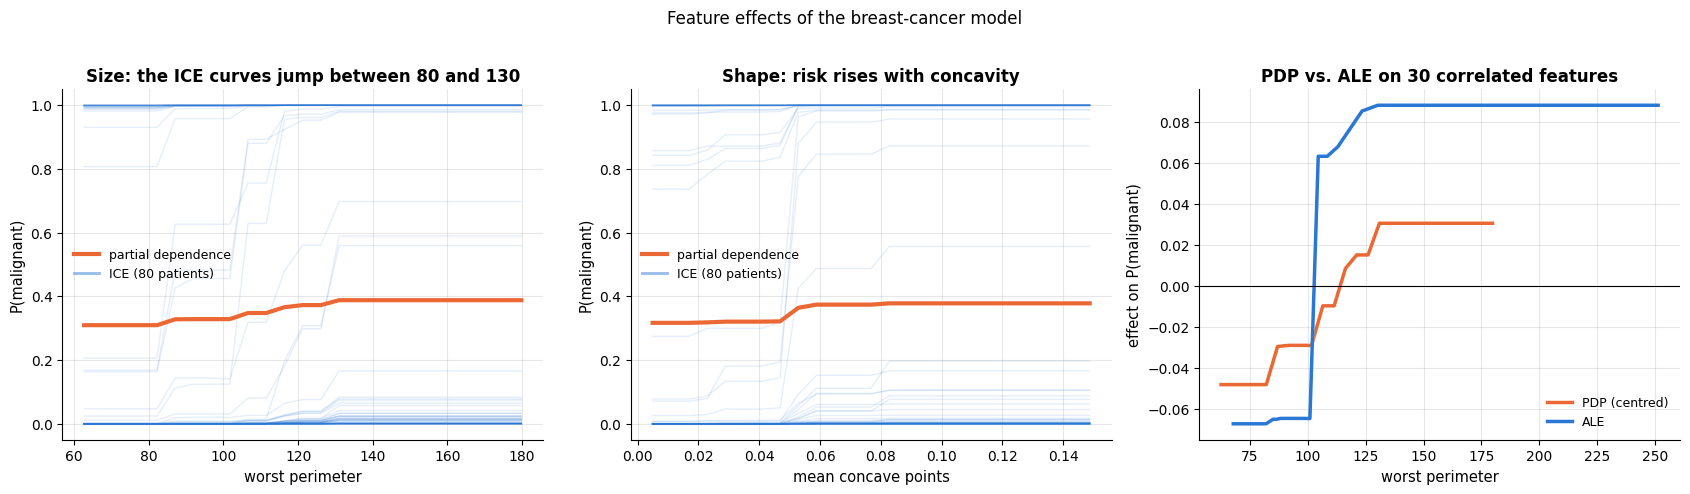

In [33]:
# grids of 25 points from the 2nd to the 98th percentile of each feature
bc_grid_a = np.linspace(X_bc_test["worst perimeter"].quantile(0.02), X_bc_test["worst perimeter"].quantile(0.98), 25)
bc_grid_b = np.linspace(X_bc_test["mean concave points"].quantile(0.02), X_bc_test["mean concave points"].quantile(0.98), 25)
pdp_a, ice_a = partial_dependence_1d(f_bc, X_bc_test, "worst perimeter", bc_grid_a)
pdp_b, ice_b = partial_dependence_1d(f_bc, X_bc_test, "mean concave points", bc_grid_b)
ale_ga, ale_a_bc = ale_1d(f_bc, X_bc_test, "worst perimeter")     # no missing values here, so no filling needed

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].plot(bc_grid_a, ice_a[:80].T, color=PALETTE[0], alpha=0.12, lw=1)     # ICE curves of the first 80 test patients
axes[0].plot(bc_grid_a, pdp_a, color=PALETTE[1], lw=3, label="partial dependence")
axes[0].plot([], [], color=PALETTE[0], alpha=0.5, label="ICE (80 patients)")
axes[0].set_xlabel("worst perimeter")
axes[0].set_ylabel("P(malignant)")
axes[0].set_title("Size: the ICE curves jump between 80 and 130")
axes[0].legend(fontsize=9, loc="center left")
axes[1].plot(bc_grid_b, ice_b[:80].T, color=PALETTE[0], alpha=0.12, lw=1)
axes[1].plot(bc_grid_b, pdp_b, color=PALETTE[1], lw=3, label="partial dependence")
axes[1].plot([], [], color=PALETTE[0], alpha=0.5, label="ICE (80 patients)")
axes[1].set_xlabel("mean concave points")
axes[1].set_ylabel("P(malignant)")
axes[1].set_title("Shape: risk rises with concavity")
axes[1].legend(fontsize=9, loc="center left")
axes[2].plot(bc_grid_a, pdp_a - pdp_a.mean(), color=PALETTE[1], lw=2.5, label="PDP (centred)")
axes[2].plot(ale_ga, ale_a_bc, color=PALETTE[0], lw=2.5, label="ALE")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_xlabel("worst perimeter")
axes[2].set_ylabel("effect on P(malignant)")
axes[2].set_title("PDP vs. ALE on 30 correlated features")
axes[2].legend(fontsize=9, loc="lower right")
fig.suptitle("Feature effects of the breast-cancer model", y=1.02)
plt.tight_layout()
plt.show()

Both curves are monotone and steep in the middle of the range, which is what a pathologist
would expect: big, irregular nuclei are the malignant ones. The ICE curves show something
the averages hide — most patients are *saturated*, pinned at 0 or at 1, and the interesting
action is the minority who flip, each at their own threshold somewhere between 80 and 130.
The average curve, rising gently from 0.31 to 0.39, describes none of them.

The third panel is the check of section 5.2 on real, heavily correlated data, and it comes
out the other way round from the churn example: here the PDP *understates* the effect. ALE
finds a sharp step of 0.13 at a perimeter of about 103 — the threshold the trees actually
use — while the PDP smears the same effect into a gentle ramp of 0.08 spread over the whole
range, because it averages over patients who cannot move and over combinations (a 250-unit
perimeter with a benign shape) that do not occur. When the features are correlated, the PDP
can be wrong in either direction; that is the whole point of section 5.2.

### 6.4 Three patients

A local explanation is what actually reaches a clinic. We take three patients from the
held-out set — the most confidently malignant prediction, the most confidently benign, and
the one closest to the decision threshold — and give each a waterfall plot. With 30
features we show the seven largest contributions and collapse the rest into one bar, which
keeps the efficiency property intact.

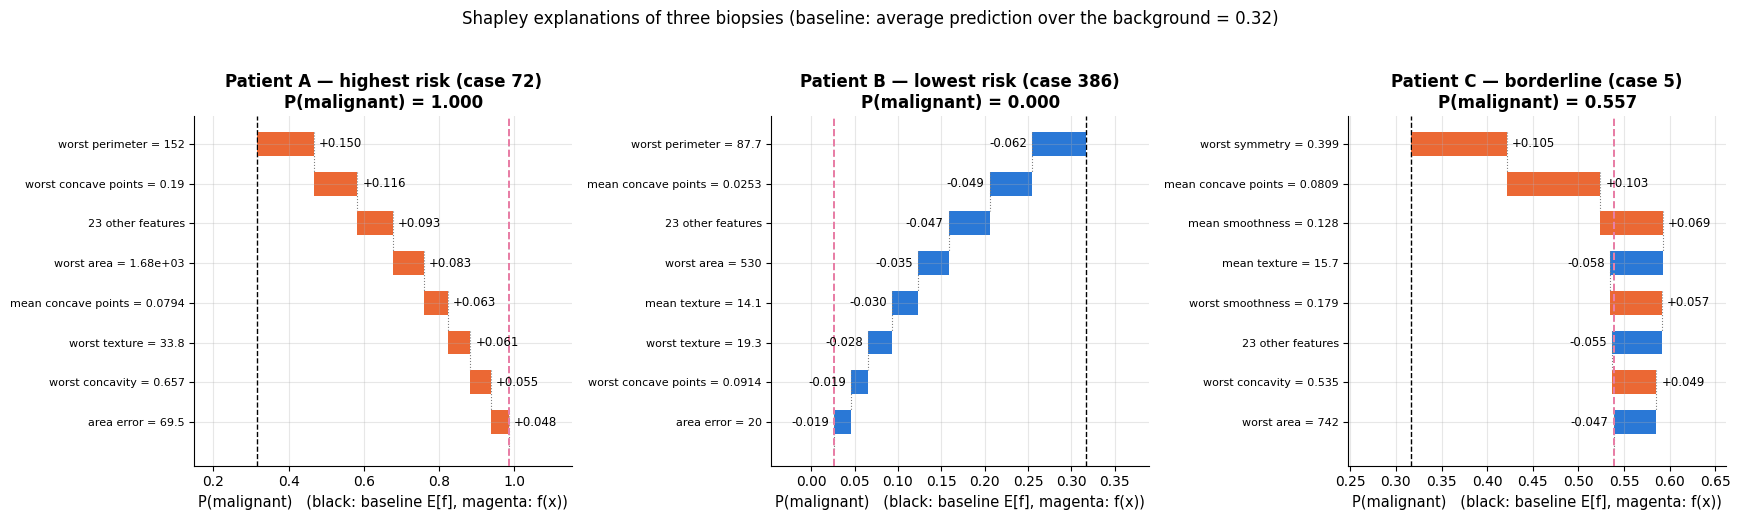

Patient A — highest risk     case   72: P(malignant) = 1.000, worst perimeter =  151.6, true label = malignant
Patient B — lowest risk      case  386: P(malignant) = 0.000, worst perimeter =   87.7, true label = benign
Patient C — borderline       case    5: P(malignant) = 0.557, worst perimeter =  103.4, true label = malignant
for reference, the median 'worst perimeter' in the training data is 98 and the baseline prediction is 0.32


In [34]:
p_bc = pd.Series(f_bc(X_bc_test), index=X_bc_test.index)     # P(malignant) per test patient, labelled by case
# idxmax / idxmin return the index label of the largest / smallest value; the borderline case is the one closest to 0.5
patients = {"Patient A — highest risk": p_bc.idxmax(),
            "Patient B — lowest risk": p_bc.idxmin(),
            "Patient C — borderline": (p_bc - 0.5).abs().idxmin()}
baseline_bc = f_bc(bg_bc).mean()                   # E[f] over the background: where each waterfall starts

fig, axes = plt.subplots(1, 3, figsize=(17.5, 5))
for ax, (label, idx) in zip(axes, patients.items()):
    x_pat = X_bc_test.loc[idx]
    phi_pat, se_pat = sampling_shapley(f_bc, x_pat, bg_bc, BC_FEATURES, n_samples=200)
    s = pd.Series(phi_pat, index=BC_FEATURES)
    top = s[s.abs().sort_values(ascending=False).index[:7]]        # the seven largest contributions by |phi|
    values = np.append(top.to_numpy(), s.sum() - top.sum())         # plus one bar for the sum of all the others
    # {x:.3g} prints 3 significant digits
    labels = [f"{c} = {x_pat[c]:.3g}" for c in top.index] + [f"{len(s) - 7} other features"]
    waterfall(ax, baseline_bc, values, labels, f"{label} (case {idx})\nP(malignant) = {p_bc[idx]:.3f}",
              unit="P(malignant)")
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle(f"Shapley explanations of three biopsies (baseline: average prediction over the background = {baseline_bc:.2f})", y=1.03)
plt.tight_layout()
plt.show()
for label, idx in patients.items():
    # {label:28s} pads to 28 characters, {idx:4d} right-aligns the integer in 4; y_bc_test[idx] is 1 for malignant
    print(f"{label:28s} case {idx:4d}: P(malignant) = {p_bc[idx]:.3f}, worst perimeter = "
          f"{X_bc_test.loc[idx, 'worst perimeter']:6.1f}, true label = {'malignant' if y_bc_test[idx] else 'benign'}")
print(f"for reference, the median 'worst perimeter' in the training data is "
      f"{X_bc_train['worst perimeter'].median():.0f} and the baseline prediction is {baseline_bc:.2f}")

Patient A's explanation is a list of large, irregular nuclei, every contribution pushing
the probability up; Patient B's is the mirror image, every measurement small and every
contribution negative. Patient C is the interesting one: the contributions point in *both*
directions — an irregular shape (`worst symmetry`, `mean concave points`) pushes the
probability up by about 0.2 in total, while a low `mean texture` and a moderate `worst
area` pull it back down — and the 0.56 that comes out is a near-tie, not a verdict. That is
the practical value of a local explanation: it does not only give a number, it tells you
whether the number is the result of agreement or of a conflict, and the conflicting cases
are the ones a human should look at.

Notice also the "23 other features" bar: for Patient A the long tail of small
contributions is itself the third-largest block. With thirty correlated columns the
prediction is genuinely spread over all of them, and any top-$k$ explanation is a summary,
not the whole account — one more reason to report the efficiency check below.

### 6.5 Does the explanation match what the model actually does?

An explanation is a claim about the model, and claims can be tested. Two checks, both
cheap. **Efficiency**: the Shapley values of a patient must sum to
$f(\mathbf{x}) - \mathbb{E}[f]$; with Monte-Carlo sampling this holds up to the standard
error, and a systematic gap would mean a broken implementation. **Faithfulness by
ablation**: if the mean $|\phi|$ ranking is right, replacing the top-ranked features by
neutral (median) values should destroy the model's discrimination much faster than
replacing randomly chosen ones.

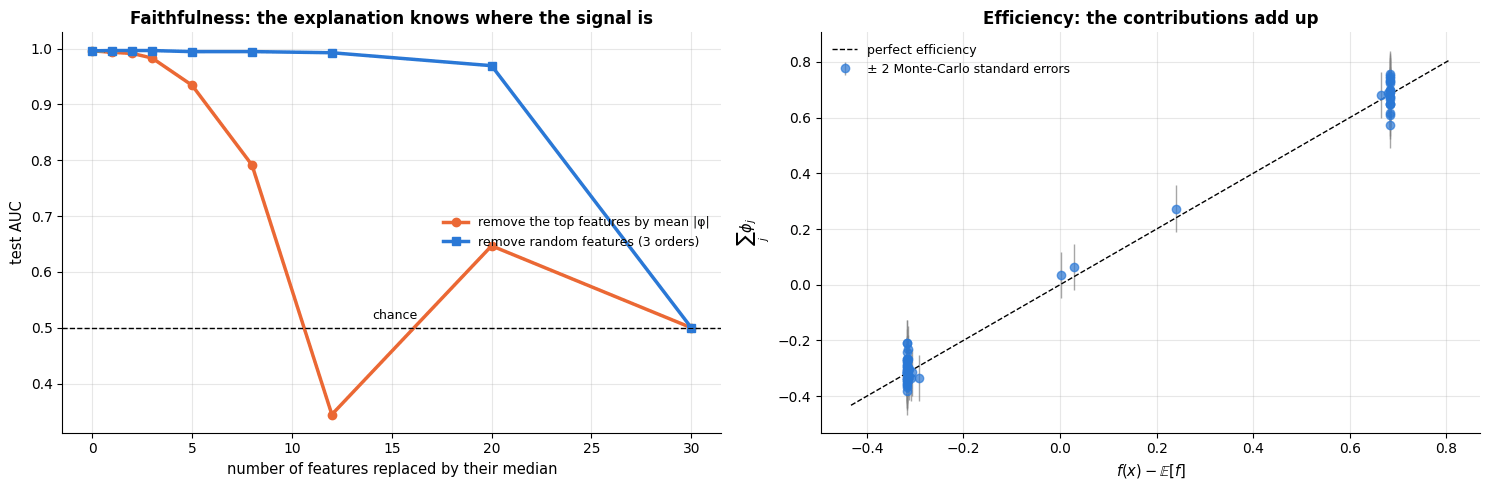

test AUC after neutralising the top k features: {0: 0.996, 5: 0.934, 8: 0.791, 12: 0.344, 30: 0.5}
                        ... random features:   {0: 0.996, 5: 0.995, 8: 0.995, 12: 0.993, 30: 0.5}
efficiency: largest deviation 0.108, Monte-Carlo tolerance (2 se) 0.083, 93 % of patients inside it
top feature by mean |φ|: worst perimeter; correlation between φ(worst perimeter) and the actual change when only that column is neutralised: 0.19


In [35]:
check_bc = X_bc_test.sample(60, random_state=RANDOM_STATE)
# sampled Shapley values (M = 120) for 60 patients: Phi_bc has shape (60, 30)
Phi_bc = pd.DataFrame([sampling_shapley(f_bc, r, bg_bc, BC_FEATURES, n_samples=120)[0] for _, r in check_bc.iterrows()],
                      index=check_bc.index, columns=BC_FEATURES)
rank_bc = Phi_bc.abs().mean().sort_values(ascending=False)     # features by mean |phi|, largest first
median_bc = X_bc_train.median()                                 # training median of every feature


def ablate(frame, cols):
    """Replace the given columns by their training median — the model's 'no information' value.

    Returns a modified copy of `frame`; the original is left untouched.
    """
    # the dict comprehension, unpacked with **, gives assign() one keyword argument per column to replace
    return frame.assign(**{c: median_bc[c] for c in cols})


ks = [0, 1, 2, 3, 5, 8, 12, 20, 30]                             # numbers of features to neutralise
# test AUC after replacing the top-k features (by mean |phi|) by their medians, for each k
curve_phi = [roc_auc_score(y_bc_test, f_bc(ablate(X_bc_test, list(rank_bc.index[:k])))) for k in ks]
# the same with random features: seed s fixes one random order of the features and its first k are replaced;
# the nested list has shape (3 seeds, len(ks)) and the mean is taken over the seeds (axis=0)
curve_rand = np.mean([[roc_auc_score(y_bc_test, f_bc(ablate(X_bc_test, list(np.random.default_rng(s).permutation(BC_FEATURES)[:k]))))
                       for k in ks] for s in range(3)], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(ks, curve_phi, marker="o", color=PALETTE[1], lw=2.5, label="remove the top features by mean |φ|")
axes[0].plot(ks, curve_rand, marker="s", color=PALETTE[0], lw=2.5, label="remove random features (3 orders)")
axes[0].axhline(0.5, color="black", lw=1, ls="--")
axes[0].annotate("chance", (14, 0.515), fontsize=9)
axes[0].set_xlabel("number of features replaced by their median")
axes[0].set_ylabel("test AUC")
axes[0].set_title("Faithfulness: the explanation knows where the signal is")
axes[0].legend(fontsize=9, loc="center right")
sum_phi = Phi_bc.sum(axis=1)                                   # sum of the 30 contributions, per patient
gap = f_bc(check_bc) - baseline_bc                             # f(x) - E[f], per patient
# 1.96 × the standard error of an average of 120 background predictions: the 95 % tolerance of the efficiency check
mc_error = 1.96 * f_bc(bg_bc).std() / np.sqrt(120)          # the background draw is the only source of the gap
axes[1].errorbar(gap, sum_phi, yerr=mc_error, fmt="o", ms=6, alpha=0.7, color=PALETTE[0],
                 ecolor="gray", elinewidth=1, label="± 2 Monte-Carlo standard errors")
lims = [min(gap.min(), sum_phi.min()) - 0.05, max(gap.max(), sum_phi.max()) + 0.05]    # one range for both axes
axes[1].plot(lims, lims, color="black", lw=1, ls="--", label="perfect efficiency")
axes[1].set_xlabel("$f(x) - \\mathbb{E}[f]$")
axes[1].set_ylabel("$\\sum_j \\phi_j$")
axes[1].legend(fontsize=9, loc="upper left")
axes[1].set_title("Efficiency: the contributions add up")
plt.tight_layout()
plt.show()

# keep only some values of k in the printed dicts; float(v) turns NumPy floats into plain Python floats for printing
print("test AUC after neutralising the top k features:",
      {k: round(float(v), 3) for k, v in zip(ks, curve_phi) if k in (0, 5, 8, 12, 30)})
print("                        ... random features:  ",
      {k: round(float(v), 3) for k, v in zip(ks, curve_rand) if k in (0, 5, 8, 12, 30)})
# the mean of a boolean array is the share of patients whose deviation lies inside the tolerance
print(f"efficiency: largest deviation {np.abs(sum_phi - gap).max():.3f}, "
      f"Monte-Carlo tolerance (2 se) {mc_error:.3f}, "
      f"{100 * (np.abs(sum_phi - gap) < mc_error).mean():.0f} % of patients inside it")
top_feature = rank_bc.index[0]
single = f_bc(ablate(check_bc, [top_feature])) - f_bc(check_bc)    # change when only that column is neutralised
# a positive phi should mean that neutralising the feature lowers the prediction, hence the minus sign in -single
print(f"top feature by mean |φ|: {top_feature}; correlation between φ({top_feature}) and the actual change "
      f"when only that column is neutralised: {np.corrcoef(Phi_bc[top_feature], -single)[0, 1]:.2f}")

The ablation curve is decisive: neutralising the eight features with the largest mean
$|\phi|$ takes the AUC from 0.996 to 0.79, and twelve of them push it *below* chance — the
model, deprived of its evidence, inverts — while removing twelve *random* features leaves
it above 0.99. The ranking is not decoration: it locates the signal.

The efficiency scatter sits on the diagonal: 93 % of the sixty patients fall within two
Monte-Carlo standard errors of it, which is what a 95 % interval should do. That error is
worth understanding rather than hiding: in the sampling estimator the
contributions of one draw always sum to $f(\mathbf{x}) - f(\mathbf{z})$ for the background
row $\mathbf{z}$ that was drawn, so the deviation from $f(\mathbf{x}) - \mathbb{E}[f]$ is
exactly the sampling error of $\overline{f(\mathbf{z})}$ — which shrinks as $1/\sqrt{M}$
and disappears entirely if you average over the whole background deterministically.

The last printed number is the honest caveat, and it is the lesson of section 5.1 once
more: the correlation between a feature's Shapley value and what actually happens when
*that single column* is neutralised is weak (0.19), because the model immediately falls
back on the other columns measuring the same nucleus. A Shapley value is a share of the
prediction under a specific background distribution, **not** a prediction of what happens
if you delete one column.

### 6.6 What to tell the clinician

> **The model in six sentences.** "This model looks at the size, the shape and the texture
> of the cell nuclei in the aspirate. Size and shape matter most: the bigger and the more
> irregular the nuclei, the higher the predicted risk — the same features you would weigh
> yourself. For Patient A the prediction is 1.00 malignant, and most of it comes from a
> handful of measurements: the largest nucleus perimeter is 152, against a typical 98, and
> the concavity measures are similarly extreme. A patient whose nuclei were of average size
> and shape would have received a prediction near 0.3, the average for this group of
> biopsies. For Patient C the prediction is 0.56 — the measurements disagree with each
> other, so the model is genuinely undecided and the case needs you, not the model. The
> model was trained on 398 biopsies from one study, it agrees with the pathologist on 97 %
> of held-out cases, and it is a second reader, not a diagnosis."

Four things to keep out of that conversation, and one to put in. Keep out: the word
"cause"; the 30-column importance plot (it says nothing, as section 6.2 showed); a
counterfactual (nothing here is actionable — you cannot ask a patient to have smaller
nuclei); and any claim about a patient unlike the training population. Put in: the
**uncertainty**, both the model's (a borderline probability means the evidence conflicts,
as with Patient C) and the explanation's (our Shapley values carry a Monte-Carlo standard
error, and a different background set would move them).

## Summary

- Interpretability serves **trust, debugging, compliance and discovery**; methods are
  **intrinsic or post-hoc**, **global or local**, **model-specific or model-agnostic**.
  Prefer an interpretable model when it is accurate enough (Rudin) — on both datasets here
  a linear or additive model matched the boosted trees.
- **Intrinsic**: coefficients → odds ratios with bootstrap CIs (beware collinearity); GAMs
  (`SplineTransformer` + logistic regression) show the *shape* of each effect; trees give
  rules; `monotonic_cst` injects domain knowledge into boosting.
- **Global post-hoc**: permutation importance (on held-out data, with error bars), partial
  dependence + ICE, ALE, global surrogates with a fidelity score.
- **Local post-hoc**: LIME (sparse weighted local linear model; unstable), Shapley values
  (the unique fair attribution; exact by enumeration, approximated by sampling or the
  KernelSHAP regression, exact and fast for trees with TreeSHAP; verified on a linear model
  where $\phi_j = w_j(x_j - \bar z_j)$), drawn as waterfall, force and beeswarm plots;
  counterfactuals (the cheapest actionable change).
- **Correlation is the enemy of every global method.** Demonstrated, not asserted: with two
  noisy measurements of the same latent quantity, per-column permutation importance ranks an
  irrelevant feature first (5.1), and two models that never disagree by more than $10^{-2}$
  on real rows have partial-dependence curves differing by a factor of three (5.2). Group
  correlated columns before permuting them; prefer ALE to the PDP; check the correlation
  matrix before drawing anything.
- **Cost** is measured in model evaluations: $d R n$ for permutation importance,
  $|\text{grid}| \, n$ for a PDP, $2n$ for ALE, $M(d{+}1)$ per prediction for sampled
  Shapley values, $2^d |B|$ for exact ones.
- **Pitfalls**: the model ≠ the world; the Rashomon effect (5.3); explanations have their
  own hyper-parameters and can be attacked; always run the randomisation sanity check (5.4)
  and report a fidelity measure.

| Question | Tool | Cost |
|---|---|---|
| Which features does the model use? | `perm_importance` on held-out data, grouped for correlated columns; mean $\lvert\phi\rvert$ | $dRn$ rows |
| How does a feature act, on average / per row? | `partial_dependence_1d`, `ale_1d`, ICE curves | $\lvert\text{grid}\rvert n$ / $2n$ rows |
| Do two features interact? | 2-D partial dependence, ICE fan-out, curves per category | $\lvert\text{grid}\rvert^2 n$ rows |
| Why this prediction? | `sampling_shapley`, `kernel_shap`, `exact_shapley_many`, `lime_explain` | $M(d{+}1)$ rows per prediction |
| What would change the outcome? | `counterfactual_search` (actionable levers only) | one row per candidate |
| Is the explanation trustworthy? | efficiency check, fidelity $R^2$, ablation curve, label-shuffling sanity check | one extra fit |
| Can I make the model interpretable instead? | logistic regression + bootstrap CIs, GAM, shallow tree, `monotonic_cst` | free |

**Next steps:** notebook 18 (ML engineering, pipelines and MLOps) packages a model and its
explanations into a reproducible, monitored system with a model card; notebook 19 (ethics,
fairness, privacy) turns the policy questions of sections 4.7 and 6.6 into a full audit;
notebook 20 (capstone) asks for an interpretability section in the final report.

## Exercises

### Exercise 1 — Importance under correlation (easy)
Repeat the experiment of section 5.1 as a sweep over the measurement noise: for
$\sigma \in \{0.05, 0.15, 0.5, 1.0, 2.0\}$, refit the model and plot the individual
importance of $x_1$ and the grouped importance of $\{x_1, x_2, x_3\}$ against $\sigma$, with
the importance of $x_4$ as a reference line. At what noise level does a single column again
tell you something true?

<details><summary>Solution sketch</summary>

Wrap the data generation and `perm_importance` in a function of $\sigma$ and loop. The
grouped value stays roughly constant (the block always carries the same signal) while the
individual importance rises with $\sigma$: the noisier the measurements, the worse they
substitute for each other, and only when they stop being substitutes does a per-column
importance become informative. Somewhere around $\sigma \approx 1$ the individual
importance of $x_1$ overtakes that of $x_4$ — and by then the columns really are different
measurements, not copies.
</details>

### Exercise 2 — 2-D partial dependence by hand (easy)
Compute the 2-D partial dependence of `support_tickets` and `contract` with
`partial_dependence_2d` (use the three contract values as `grid_b`) and plot it as three
lines. Does the effect of tickets depend on the contract?

<details><summary>Solution sketch</summary>

`partial_dependence_2d(f, sample, "support_tickets", "contract", np.arange(0, 7), ["Month-to-month", "One year", "Two year"])`
gives a (7, 3) array; plot each column. The slope in tickets is steepest for month-to-month
customers — the interaction the surrogate tree found.
</details>

### Exercise 3 — Shapley values of the additive model (medium)
Compute exact Shapley values of the GAM's *log-odds* (`gam.decision_function`) for one
customer, using the five numeric features of `LIN` (fix the categoricals at the customer's
values inside the prediction function). Show that each $\phi_j$ equals
$g_j(x_j) - \overline{g_j(z_j)}$, the centred shape function — additive models are explained
exactly by their own terms.

<details><summary>Solution sketch</summary>

Wrap `gam.decision_function` in a function that rebuilds full rows from the five numeric
columns plus the customer's categorical values; run `exact_shapley` with a background of 100
rows; compare with `shape_function(col, [x_j])[0]` minus the average of the shape function
over the background. Agreement is exact up to floating point because there are no
interactions.
</details>

### Exercise 4 — LIME on a decision tree (medium)
Fit a `DecisionTreeClassifier(max_depth=4)` on the preprocessed training data and explain
one prediction with `lime_explain`. Compare the LIME coefficients with the features on the
customer's path through the tree (`tree_.feature`, `decision_path`). Why does LIME
sometimes give non-zero weight to features that are not on the path?

<details><summary>Solution sketch</summary>

Perturbations cross neighbouring splits, so features that appear in *nearby* leaves
influence the local linear fit even if the customer's own path does not test them. A
piecewise-constant model has zero gradient almost everywhere; LIME's answer depends
entirely on the perturbation scale.
</details>

### Exercise 5 — A faithfulness curve for the churn model (medium)
Reproduce the ablation curve of section 6.5 for the churn model: rank the twelve features by
mean $|\phi|$ (reuse `Phi`), then replace the top $k$ by their training median (numeric) or
mode (categorical) and plot the test AUC against $k$, with a random-order baseline. Then do
the same ranking by permutation importance. Which ranking degrades the model faster, and
why is that not the same as "which ranking is correct"?

<details><summary>Solution sketch</summary>

Write `ablate(frame, cols)` with `frame.assign(**{c: X_train[c].median() if c in NUMERIC else X_train[c].mode()[0] for c in cols})`.
The permutation ranking usually wins on this curve *by construction* — it was chosen to
maximise score loss — which is precisely why a faithfulness curve compares an explanation
with random ordering, not two explanations with each other.
</details>

### Exercise 6 — Better counterfactuals (hard)
Extend `counterfactual_search` with (a) a plausibility constraint — reject candidates whose
`monthly_charges` falls below the 5th percentile of the training data — and (b) a
diversity requirement: return the three cheapest counterfactuals that change *different*
features. Then compute, for the 50 highest-risk test customers, the distribution of the
cheapest intervention. Which lever is most often decisive?

<details><summary>Solution sketch</summary>

Filter the candidate frame before scoring; for diversity, iterate over the sorted
candidates and keep one per set of changed features. A contract change is the decisive lever
for most high-risk customers, followed by a 20 $ discount; the payment method is rarely
enough on its own.
</details>

## References and further reading

### Textbooks

- Molnar, C. (2022). *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable* (2nd ed.). (free at https://christophm.github.io/interpretable-ml-book/) — The book-length version of this notebook: every method here has a chapter there, with worked examples and an honest list of disadvantages.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — Chapter 9 on generalised additive models and §10.13 on partial dependence.
- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press. (free) — For the policy questions raised in sections 4.7 and 6.6; the subject of notebook 19.

### Papers

- Lipton, Z. C. (2018). The mythos of model interpretability. *Communications of the ACM*, 61(10), 36–43. — What "interpretable" can mean; read it before using the word.
- Rudin, C. (2019). Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead. *Nature Machine Intelligence*, 1, 206–215. — The case for intrinsic interpretability.
- Breiman, L. (2001). Statistical modeling: the two cultures. *Statistical Science*, 16(3), 199–231. — The Rashomon effect (and a famous argument about algorithmic vs. data modelling). Cited as Breiman (2001b).
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. — Where permutation importance was introduced.
- Fisher, A., Rudin, C., & Dominici, F. (2019). All models are wrong, but many are useful: learning a variable's importance by studying an entire class of prediction models simultaneously. *Journal of Machine Learning Research*, 20(177), 1–81. — Model reliance: permutation importance made rigorous, and its Rashomon-set extension.
- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). Bias in random forest variable importance measures. *BMC Bioinformatics*, 8, 25. — Why impurity importance is biased.
- Hooker, G., Mentch, L., & Zhou, S. (2021). Unrestricted permutation forces extrapolation: variable importance requires at least one more model, or there is no free variable importance. *Statistics and Computing*, 31, 82. — The correlated-features problem of sections 3.2 and 5.1.
- Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *The Annals of Statistics*, 29(5), 1189–1232. — Partial dependence plots appear in §8.2.
- Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015). Peeking inside the black box: visualizing statistical learning with plots of individual conditional expectation. *Journal of Computational and Graphical Statistics*, 24(1), 44–65. — ICE plots.
- Apley, D. W., & Zhu, J. (2020). Visualizing the effects of predictor variables in black box supervised learning models. *Journal of the Royal Statistical Society: Series B*, 82(4), 1059–1086. — ALE plots; section 5.2 is a reconstruction of their argument.
- Hastie, T., & Tibshirani, R. (1986). Generalized additive models. *Statistical Science*, 1(3), 297–310. — The GAM.
- Nori, H., Jenkins, S., Koch, P., & Caruana, R. (2019). InterpretML: a unified framework for machine learning interpretability. *arXiv:1909.09223*. — Explainable Boosting Machines.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?": explaining the predictions of any classifier. *Proceedings of KDD 2016*, 1135–1144. — LIME.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2018). Anchors: high-precision model-agnostic explanations. *Proceedings of AAAI 2018*. — Rule-based local explanations.
- Shapley, L. S. (1953). A value for n-person games. In *Contributions to the Theory of Games II*, Princeton University Press, 307–317. — The axioms and the formula.
- Štrumbelj, E., & Kononenko, I. (2014). Explaining prediction models and individual predictions with feature contributions. *Knowledge and Information Systems*, 41, 647–665. — Shapley values for predictions, with the sampling algorithm of section 4.3.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in NeurIPS 30*. — SHAP and KernelSHAP; unifies LIME, Shapley values and several other methods.
- Lundberg, S. M., et al. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, 2, 56–67. — TreeSHAP and the summary/dependence plots.
- Wachter, S., Mittelstadt, B., & Russell, C. (2017). Counterfactual explanations without opening the black box. *Harvard Journal of Law & Technology*, 31(2), 841–887. — Counterfactual explanations and the GDPR.
- Adebayo, J., et al. (2018). Sanity checks for saliency maps. *Advances in NeurIPS 31*. — The randomisation tests of section 5.4.
- Slack, D., Hilgard, S., Jia, E., Singh, S., & Lakkaraju, H. (2020). Fooling LIME and SHAP: adversarial attacks on post hoc explanation methods. *Proceedings of AIES 2020*. — Explanations can be gamed.
- Simonyan, K., Vedaldi, A., & Zisserman, A. (2014). Deep inside convolutional networks: visualising image classification models and saliency maps. *ICLR 2014 Workshop*. — Gradient saliency (deep-learning course).
- Sundararajan, M., Taly, A., & Yan, Q. (2017). Axiomatic attribution for deep networks. *Proceedings of ICML 2017*. — Integrated gradients (deep-learning course).
- Selvaraju, R. R., et al. (2017). Grad-CAM: visual explanations from deep networks via gradient-based localization. *Proceedings of ICCV 2017*, 618–626. — (deep-learning course).
- Jain, S., & Wallace, B. C. (2019). Attention is not explanation. *Proceedings of NAACL-HLT 2019*. — Why attention weights are not faithful explanations (deep-learning course).
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Proceedings of SPIE 1905*, 861–870. — The case-study data of section 6.

### Documentation and online resources

- scikit-learn user guide, *Permutation feature importance* — https://scikit-learn.org/stable/modules/permutation_importance.html
- scikit-learn user guide, *Partial dependence and individual conditional expectation plots* — https://scikit-learn.org/stable/modules/partial_dependence.html
- scikit-learn user guide, *Monotonic constraints in histogram-based gradient boosting* — https://scikit-learn.org/stable/modules/ensemble.html#monotonic-constraints
- SHAP documentation — https://shap.readthedocs.io/ — `TreeExplainer`, `KernelExplainer` and the plot gallery.
- InterpretML — https://interpret.ml/ — Explainable Boosting Machines and a unified API for the methods of this notebook.
- Regulation (EU) 2016/679 (GDPR), Articles 13–15 and 22; Regulation (EU) 2024/1689 (AI Act) — the legal background of section 1.1.